In [1]:
import pandas as pd

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/DISEASES_Summary_GDA_CURATED_C1269683.tsv" 
df = pd.read_csv(file_path, sep='\t')
print(df)

if 'score' in df.columns:
    score_col = 'score'
elif 'gdaScore' in df.columns:
    score_col = 'gdaScore'
else:

    score_col = 'DSIg'
    print("Note: Using DSIg as the score since association score column is not found.")
# Extract gene and score
result = df[['gene_symbol', score_col]]

# Sort by score in descending order
result = result.sort_values(by=score_col, ascending=False)

# Display the result
print(result)

# Save to a CSV file
result.to_csv('mdd_genes_with_scores.csv', index=False)

import pandas as pd

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/DISEASES_Summary_GDA_CURATED_C1269683.tsv" 
df = pd.read_csv(file_path, sep='\t')

# Identify the score column
if 'score' in df.columns:
    score_col = 'score'
elif 'gdaScore' in df.columns:
    score_col = 'gdaScore'
else:
    score_col = 'DSIg'
    print("Note: Using DSIg as the score since association score column is not found.")

# Filter for genes with score >= 0.65
high_score_genes = df[df[score_col] >= 0.70].copy()

# Extract gene and score
filtered_result = high_score_genes[['gene_symbol', score_col]]

# Sort by score in descending order
filtered_result = filtered_result.sort_values(by=score_col, ascending=False)

# Display the result
print(f"Found {len(filtered_result)} genes with score >= 0.70")
#print((filtered_result))

pd.set_option('display.max_rows', None)

# Print only the desired columns
print(filtered_result)
# Save to a CSV file
#filtered_result.to_csv('mdd_genes_high_score.csv', index=False)

# Optional: Add a label column
filtered_result['MDD_Label'] = 'High_Confidence_MDD_Gene'

# Save the labeled version
#result.to_csv('mdd_genes_high_score_labeled.csv', index=False)

           ei  numCTs                                       pathway_name  \
0    0.903846       2                                Signal Transduction   
1    0.830645      68  Signal Transduction,Disease,Immune System,Meta...   
2    0.871642      64  Signal Transduction,Disease,Gene expression (T...   
3    0.855556       6                                    Neuronal System   
4    0.764151      44                                      Immune System   
..        ...     ...                                                ...   
224  1.000000       0                                                NaN   
225  1.000000       0                                                NaN   
226  1.000000       0                              Developmental Biology   
227  1.000000       0          Developmental Biology,Signal Transduction   
228  1.000000       0  Metabolism of proteins,Cellular responses to s...   

    gene_symbol  numVariantsAssociatedToGene              gp_class_names  \
0         H

COMPREHENSIVE ANALYSIS OF MDD CANDIDATE GENES

1. BASIC STATISTICS
----------------------------------------
Total number of genes: 229
Average score: 0.624
Median score: 0.600
Score standard deviation: 0.119
Minimum score: 0.500
Maximum score: 0.950

2. SCORE DISTRIBUTION BY QUANTILES
----------------------------------------
25th percentile: 0.500
50th percentile: 0.600
75th percentile: 0.700
90th percentile: 0.800
95th percentile: 0.850

3. GENE COUNT BY SCORE THRESHOLDS
----------------------------------------
Genes with score ≥ 0.3: 229 (100.0%)
Genes with score ≥ 0.5: 229 (100.0%)
Genes with score ≥ 0.7: 62 (27.1%)
Genes with score ≥ 0.8: 33 (14.4%)
Genes with score ≥ 0.9: 6 (2.6%)

4. TOP 10 HIGHEST SCORING GENES
----------------------------------------
HTR1A: 0.950
IL6: 0.950
BDNF: 0.950
SLC6A4: 0.950
CRP: 0.950
GRM5: 0.900
CRH: 0.850
CYP2C19: 0.850
CYP2D6: 0.850
NR3C1: 0.850

5. GENERATING VISUALIZATIONS
----------------------------------------
Visualizations saved as 'mdd_genes

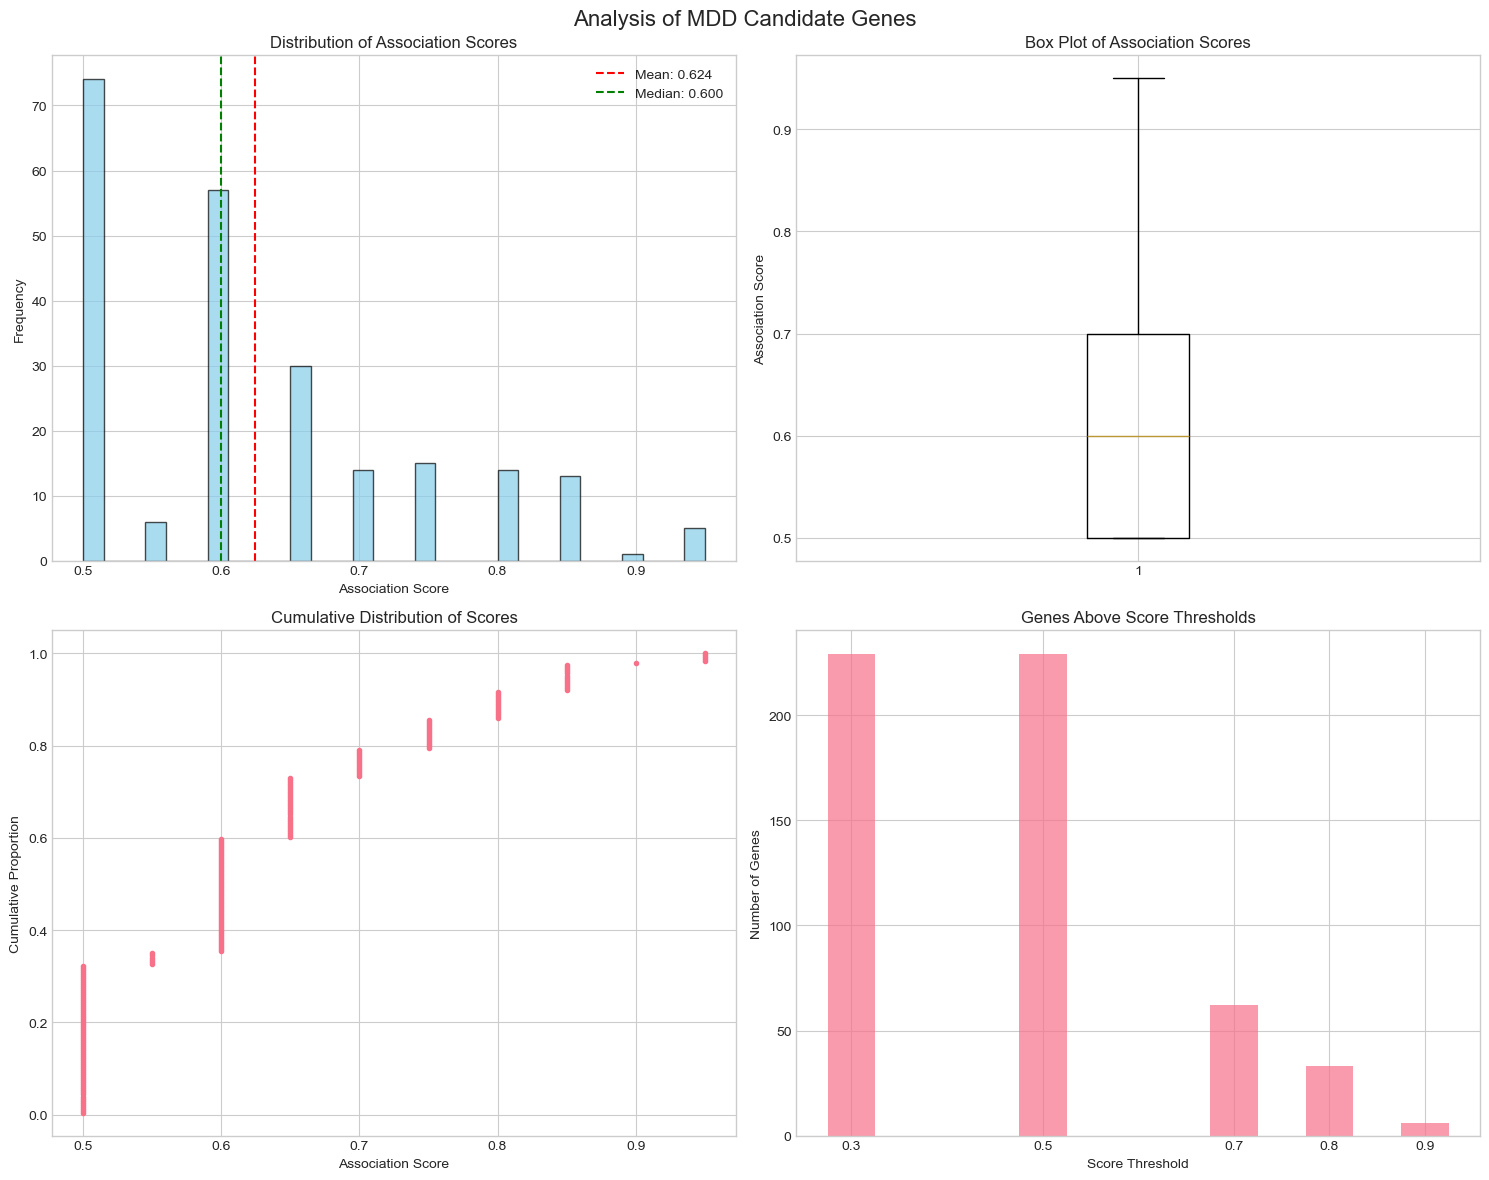

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def analyze_mdd_genes(df, score_column='score'):
    """
    Perform comprehensive analysis on MDD candidate genes
    
    Parameters:
    df (DataFrame): DataFrame containing MDD genes and their scores
    score_column (str): Name of the column containing association scores
    """
    
    print("=" * 60)
    print("COMPREHENSIVE ANALYSIS OF MDD CANDIDATE GENES")
    print("=" * 60)
    
    # 1. Basic statistics
    print("\n1. BASIC STATISTICS")
    print("-" * 40)
    print(f"Total number of genes: {len(df)}")
    print(f"Average score: {df[score_column].mean():.3f}")
    print(f"Median score: {df[score_column].median():.3f}")
    print(f"Score standard deviation: {df[score_column].std():.3f}")
    print(f"Minimum score: {df[score_column].min():.3f}")
    print(f"Maximum score: {df[score_column].max():.3f}")
    
    # 2. Score distribution by quantiles
    print("\n2. SCORE DISTRIBUTION BY QUANTILES")
    print("-" * 40)
    quantiles = df[score_column].quantile([0.25, 0.5, 0.75, 0.9, 0.95])
    for q, value in quantiles.items():
        print(f"{int(q*100)}th percentile: {value:.3f}")
    
    # 3. Count genes by score thresholds
    print("\n3. GENE COUNT BY SCORE THRESHOLDS")
    print("-" * 40)
    thresholds = [0.3, 0.5, 0.7, 0.8, 0.9]
    for threshold in thresholds:
        count = len(df[df[score_column] >= threshold])
        print(f"Genes with score ≥ {threshold}: {count} ({count/len(df)*100:.1f}%)")
    
    # 4. Top 10 highest scoring genes
    print("\n4. TOP 10 HIGHEST SCORING GENES")
    print("-" * 40)
    top_genes = df.nlargest(10, score_column)[['gene_symbol', score_column]]
    for _, row in top_genes.iterrows():
        print(f"{row['gene_symbol']}: {row[score_column]:.3f}")
    
    # 5. Visualizations
    print("\n5. GENERATING VISUALIZATIONS")
    print("-" * 40)
    
    # Create a figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Analysis of MDD Candidate Genes', fontsize=16)
    
    # Distribution of scores
    axes[0, 0].hist(df[score_column], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(df[score_column].mean(), color='red', linestyle='--', label=f'Mean: {df[score_column].mean():.3f}')
    axes[0, 0].axvline(df[score_column].median(), color='green', linestyle='--', label=f'Median: {df[score_column].median():.3f}')
    axes[0, 0].set_xlabel('Association Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Association Scores')
    axes[0, 0].legend()
    
    # Box plot of scores
    axes[0, 1].boxplot(df[score_column])
    axes[0, 1].set_ylabel('Association Score')
    axes[0, 1].set_title('Box Plot of Association Scores')
    
    # Cumulative distribution
    sorted_scores = np.sort(df[score_column])
    cum_dist = np.arange(1, len(sorted_scores)+1) / len(sorted_scores)
    axes[1, 0].plot(sorted_scores, cum_dist, marker='.', linestyle='none')
    axes[1, 0].set_xlabel('Association Score')
    axes[1, 0].set_ylabel('Cumulative Proportion')
    axes[1, 0].set_title('Cumulative Distribution of Scores')
    axes[1, 0].grid(True)
    
    # Score thresholds
    threshold_counts = [len(df[df[score_column] >= t]) for t in thresholds]
    axes[1, 1].bar(thresholds, threshold_counts, width=0.05, alpha=0.7)
    axes[1, 1].set_xlabel('Score Threshold')
    axes[1, 1].set_ylabel('Number of Genes')
    axes[1, 1].set_title('Genes Above Score Thresholds')
    axes[1, 1].set_xticks(thresholds)
    
    plt.tight_layout()
    plt.savefig('mdd_genes_analysis.png', dpi=300, bbox_inches='tight')
    print("Visualizations saved as 'mdd_genes_analysis.png'")
    
    # 6. Additional analyses if other columns are available
    if 'Gene Type' in df.columns:
        print("\n6. GENE TYPE DISTRIBUTION")
        print("-" * 40)
        gene_type_counts = df['Gene Type'].value_counts()
        print("Top gene types:")
        for gene_type, count in gene_type_counts.head(10).items():
            print(f"  {gene_type}: {count} genes")
            
        # Plot gene type distribution
        plt.figure(figsize=(10, 6))
        gene_type_counts.head(10).plot(kind='bar', color='lightcoral')
        plt.title('Top 10 Gene Types in MDD Candidates')
        plt.xlabel('Gene Type')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('mdd_gene_types.png', dpi=300, bbox_inches='tight')
        print("Gene type distribution saved as 'mdd_gene_types.png'")
    
    if 'Pathways' in df.columns:
        print("\n7. PATHWAY ANALYSIS")
        print("-" * 40)
        # Extract and count pathways
        all_pathways = []
        for pathways in df['Pathways'].dropna():
            # Assuming pathways are separated by semicolons
            pathway_list = [p.strip() for p in pathways.split(';')]
            all_pathways.extend(pathway_list)
        
        pathway_counts = pd.Series(all_pathways).value_counts()
        print("Top pathways associated with MDD genes:")
        for pathway, count in pathway_counts.head(10).items():
            print(f"  {pathway}: {count} genes")
    
    # 8. Save detailed analysis results
    analysis_results = {
        'total_genes': len(df),
        'mean_score': df[score_column].mean(),
        'median_score': df[score_column].median(),
        'std_score': df[score_column].std(),
        'min_score': df[score_column].min(),
        'max_score': df[score_column].max(),
        'quantiles': quantiles.to_dict(),
        'threshold_counts': {f"geq_{t}": len(df[df[score_column] >= t]) for t in thresholds},
        'top_genes': top_genes.to_dict('records')
    }
    
    # Convert to DataFrame and save
    analysis_df = pd.DataFrame.from_dict(analysis_results, orient='index')
    analysis_df.to_csv('mdd_genes_analysis_summary.csv', header=['Value'])
    print("\nAnalysis summary saved as 'mdd_genes_analysis_summary.csv'")
    
    return analysis_results

# Load your data
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/DISEASES_Summary_GDA_CURATED_C1269683.tsv" 
df = pd.read_csv(file_path, sep='\t')

# Identify the score column
if 'score' in df.columns:
    score_col = 'score'
elif 'gdaScore' in df.columns:
    score_col = 'gdaScore'
else:
    score_col = 'DSIg'
    print("Note: Using DSIg as the score since association score column is not found.")

# Run the analysis
analysis_results = analyze_mdd_genes(df, score_col)

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

In [4]:
import pandas as pd

pd.reset_option('display.max_rows')

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/tissue_category_rna_Brain_Detected_97.tsv" 
brain_only_df = pd.read_csv(file_path, sep='\t')


brain_only_df = brain_only_df[['Gene']]


# Display the result
print("The genes that only exist in human's brain:")
print(brain_only_df)

# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/tissue_category_rna_Brain_Detected_restrictedbrain.tsv" 
brain_restricted_df = pd.read_csv(file_path, sep='\t')


brain_restricted_df = brain_restricted_df[['Gene']]


# Display the result
print("The genes that only exist in human's brain and in less than 1/3 of other tissues:")
print(brain_restricted_df)


# Read the TSV file
file_path = "/Users/mehrdadheydari/Desktop/Thesis_research _files/disgenet data/all genes TSV files/tissue_category_rna_Brain_Detected_all_tissues.tsv" 
all_tissues_df = pd.read_csv(file_path, sep='\t')


all_tissues_df = all_tissues_df[['Gene']]


# Display the result
print("The genes that exist in human's brain and other tissues (more than 1/3 of other tissues):")
print(all_tissues_df)



print('List of common genes between all MDD genes and the genes only existing in brain are:')
common_df = result[result['gene_symbol'].isin(brain_only_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print('List of common genes between filtered genes of MDD (with score more than 70%) and the genes only existing in brain are:')
common_df = filtered_result[filtered_result['gene_symbol'].isin(brain_only_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print("-------------------------------------------------")
print('List of common genes between all MDD genes and the genes in brain and in less than 1/3 other tissues are:')
common_df = result[result['gene_symbol'].isin(brain_restricted_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print('List of common genes between filtered genes of MDD (with score more than 70%) and the genes existing brain and less than 1/3 of all tissues are:')
common_df = filtered_result[filtered_result['gene_symbol'].isin(brain_restricted_df['Gene'])]
print(common_df)
print(len(common_df))

print("\n \n")
print("-------------------------------------------------")
print('List of common genes between all MDD genes and the genes in brain and in more than 1/3 other tissues are:')
common_df = result[result['gene_symbol'].isin(all_tissues_df['Gene'])]
print(common_df)
print(len(common_df))
print("\n \n")
print('List of common genes between filtered genes of MDD (with score more than 70%) and the genes in more than 1/3 of all tissues are:')
common_df = filtered_result[filtered_result['gene_symbol'].isin(all_tissues_df['Gene'])]
print(common_df)
print(len(common_df))



#concat MDD genes with Brain genes
import pandas as pd

print("Node set 1 contains the restricted genes (Genes in brain and less than 1/3 of all tissues + Genes only in brain:)")
node_set1 = pd.DataFrame({
    'Genes': pd.concat([
        result['gene_symbol'], 
        brain_restricted_df['Gene']
    ], ignore_index=True)
})

node_set1 = pd.DataFrame({
    'Genes': pd.concat([
        node_set1['Genes'], 
        brain_only_df['Gene']
    ], ignore_index=True)
})
print(node_set1)


print("----------------------")
print("\n")

print("Node set 2 contains the all brain genes (And all other tissues))")
node_set2 = pd.DataFrame({
    'Genes': pd.concat([
        all_tissues_df['Gene'], 
        node_set1['Genes']
    ], ignore_index=True)
})
print(node_set2)

print("----------------------")
print("\n")

print("Here the node set is assigned to the nodes in our network: ")
all_nodes = node_set1

print(all_nodes)



import requests

# Gene list
gene_list = all_nodes['Genes'].dropna().unique().tolist()
print(f"Number of input genes: {len(gene_list)}")

# STRING API settings
STRING_API_URL = "https://string-db.org/api/tsv-no-header/network"
payload = {
    "identifiers": "\n".join(gene_list),  # newline-separated
    "species": 9606,
    "required_score": 400
}

# Use POST to avoid URL length limit
response = requests.post(STRING_API_URL, data=payload)

if response.ok:
    interactions = []
    for line in response.text.strip().split("\n"):
        cols = line.split("\t")
        try:
            gene_a = cols[2]  # preferredName_A
            gene_b = cols[3]  # preferredName_B
            
            score = float(cols[5])  # combined_score
            interactions.append((gene_a, gene_b, score))
           # print(interactions)
        except (IndexError, ValueError):
            continue
    print(f"Number of interactions found: {len(interactions)}")
else:
    print("Error:", response.status_code, response.text)

for i in range(0,10):
    print(interactions[i])


import networkx as nx

G = nx.Graph()

# Add nodes
G.add_nodes_from(gene_list)

# Add edges with STRING score as weight
for gene_a, gene_b, score in interactions:
    G.add_edge(gene_a, gene_b, weight=score)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")



The genes that only exist in human's brain:
              Gene
0             AMBN
1             AMZ1
2         ANKRD34C
3          ANKRD63
4   ARMCX5-GPRASP2
..             ...
92        TMEM132D
93           TRPC5
94            UCMA
95            VAX1
96            WNT1

[97 rows x 1 columns]
The genes that only exist in human's brain and in less than 1/3 of other tissues:
         Gene
0       A2ML1
1      ABCC12
2       ABCG4
3     ABHD12B
4        ACAN
...       ...
1359   ZNF732
1360  ZNF804A
1361   ZNF831
1362   ZNF843
1363      ZP2

[1364 rows x 1 columns]
The genes that exist in human's brain and other tissues (more than 1/3 of other tissues):
        Gene
0     A4GALT
1      AADAT
2       AARD
3       AASS
4       AATK
...      ...
4966  ZSWIM4
4967  ZSWIM5
4968  ZSWIM9
4969   ZWINT
4970    ZXDA

[4971 rows x 1 columns]
List of common genes between all MDD genes and the genes only existing in brain are:
    gene_symbol  score
93         DRD3    0.6
111       HTR3B    0.6
118  

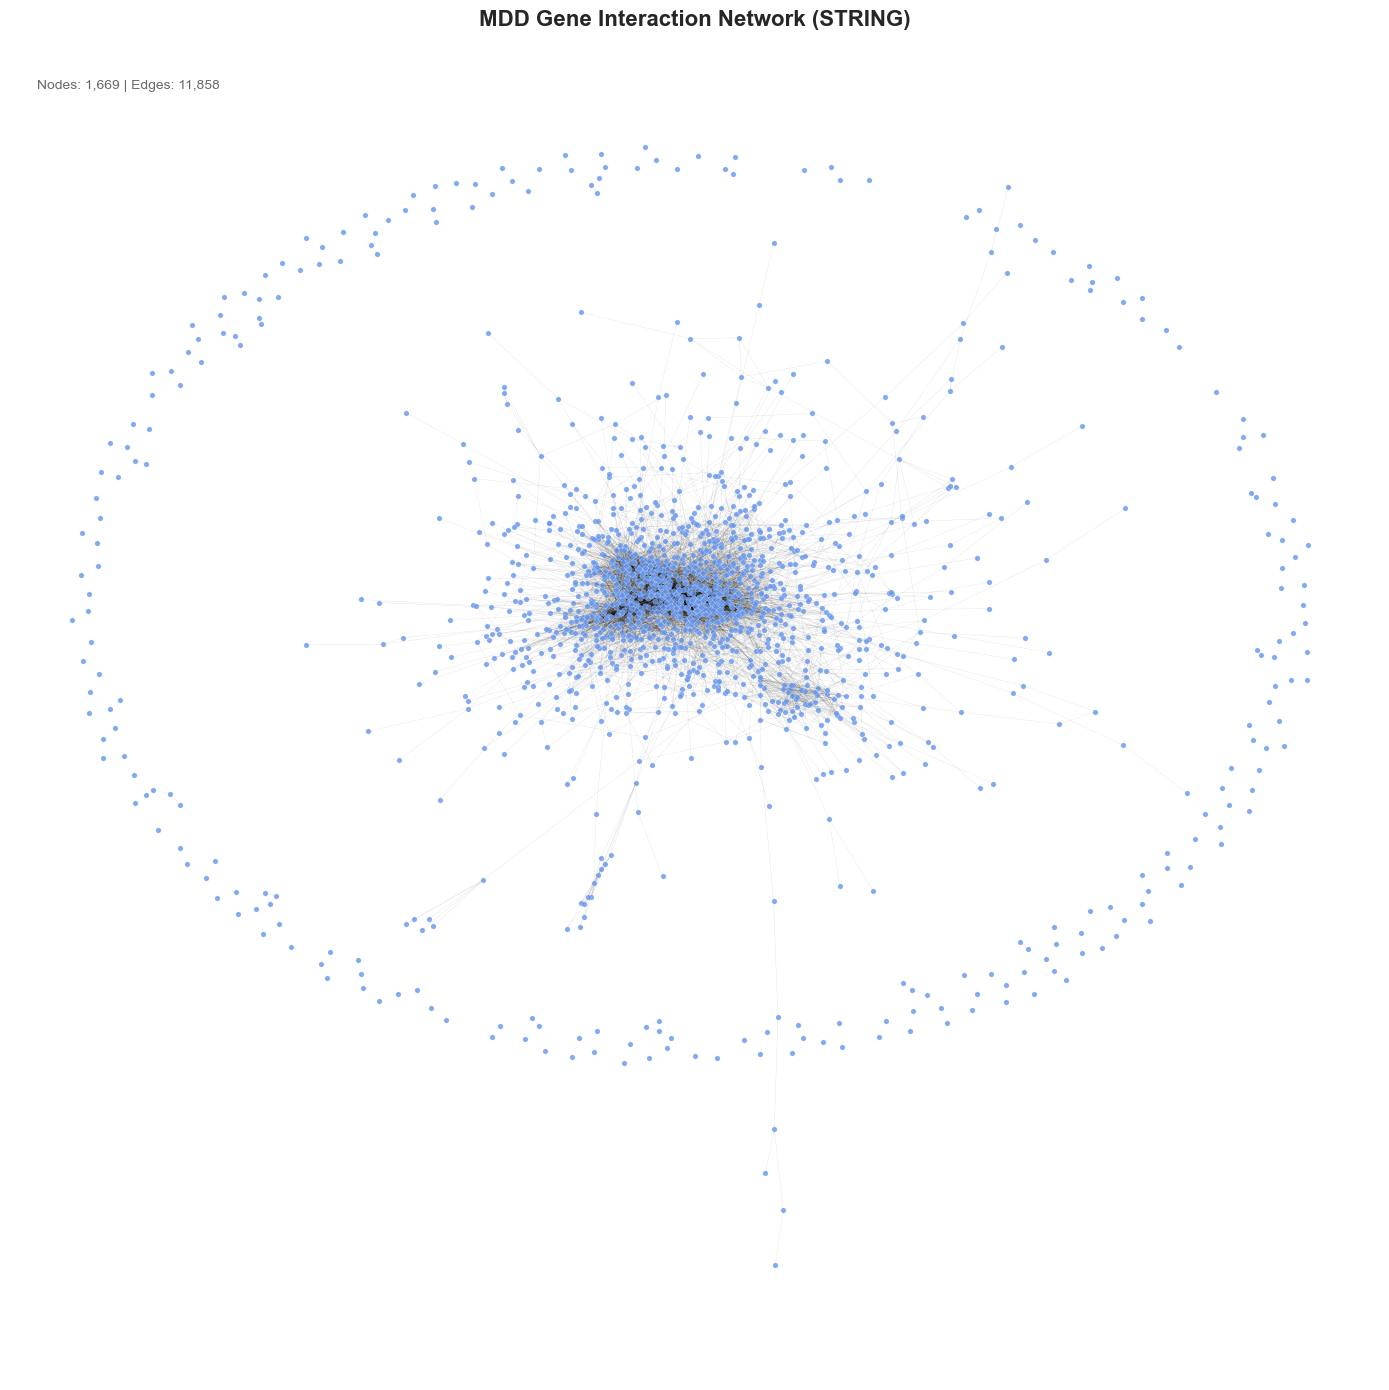

In [7]:
#Another graph!
import matplotlib.pyplot as plt
import networkx as nx

# Set style for cleaner look
plt.style.use("seaborn-v0_8-white")

# Create the layout (spring layout can be slow, so this uses fewer iterations)
pos = nx.spring_layout(G, k=0.08, iterations=50, seed=42)

# Initialize figure
plt.figure(figsize=(14, 14))
plt.title("MDD Gene Interaction Network (STRING)", fontsize=16, fontweight='bold', pad=20)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=15,
    node_color="cornflowerblue",
    alpha=0.8,
    linewidths=0.2,
    edgecolors="white"
)

# Draw edges (thin and transparent for clarity)
nx.draw_networkx_edges(
    G, pos,
    width=0.2,
    alpha=0.15,
    edge_color="black"
)

# Remove axes for a clean look
plt.axis("off")

# Add annotation for node/edge count
plt.text(0.02, 0.98,
         f"Nodes: {G.number_of_nodes():,} | Edges: {G.number_of_edges():,}",
         transform=plt.gca().transAxes,
         fontsize=10, color="dimgray", va="top")

plt.tight_layout()
plt.show()


Initial STRING graph: 1020 nodes, 4198 edges
Positive genes in graph before component filtering: 60
Removed 86 genes from components with no positive connection
Filtered graph: 934 nodes, 4150 edges
Positive genes in filtered graph: 60
Scoring table built: 934 nodes (positives=60)

NEGATIVE SELECTION (30 samples; criteria identical, seed varies)
- Non-positives count: 874
- Bottom quantile q=0.5: cutoff=0.284260
- Exclude dist <= 2: ON
- Eligible negatives: 215
- Selected negatives per sample: 60 (target=60)
- Positives in graph: 60
- Negative sampling seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]
  sample 00 seed=42: size=60 | outside_eligible=0 | overlap_positives=0
  sample 01 seed=43: size=60 | outside_eligible=0 | overlap_positives=0
  sample 02 seed=44: size=60 | outside_eligible=0 | overlap_positives=0
  sample 03 seed=45: size=60 | outside_eligible=0 | overlap_positives=0
  sample 04 seed=46: size

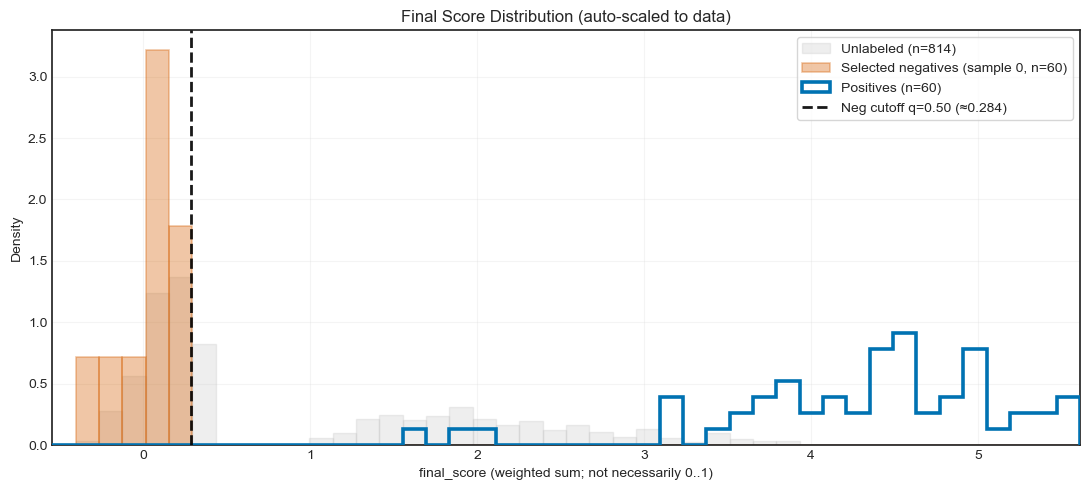

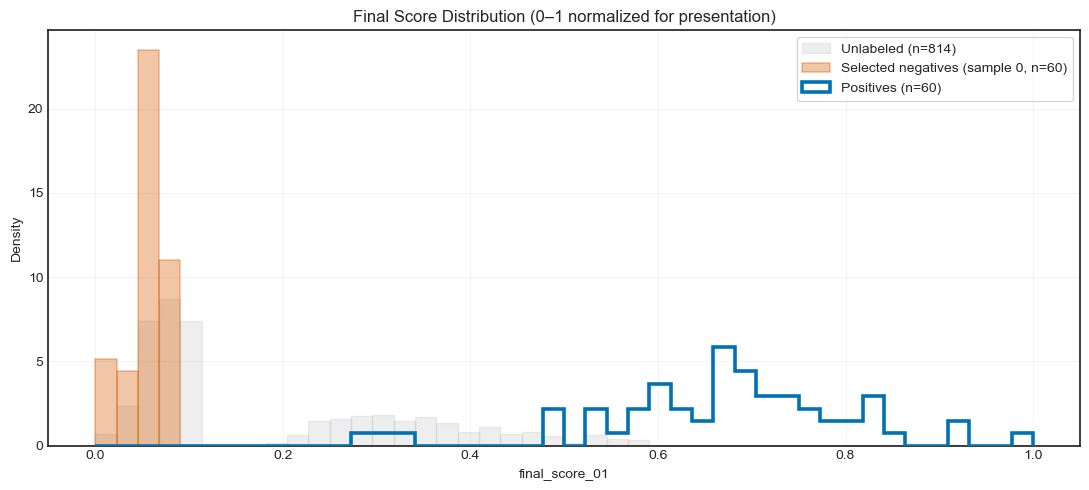

/var/folders/ql/zn64c29n0xbcthrddtdp57_m0000gn/T/ipykernel_95285/853307890.py:366: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


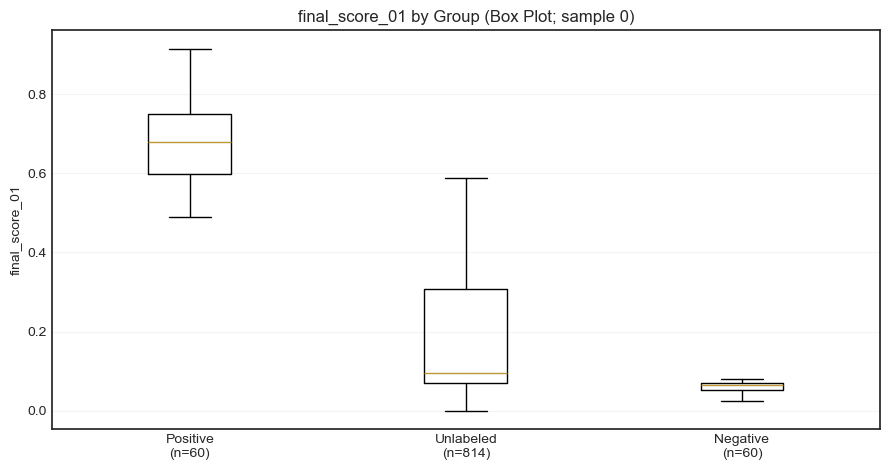


Saved:
- candidate_genes.csv (top 20 non-positive by final_score)
- refined_negative_genes_30samples_thr0.6_q0.5_excl2_k60.csv
- refined_negative_genes_SAMPLE0_thr0.6_q0.5_excl2.csv
- scored_all_nodes.csv (all nodes with features + scores + groups)


In [9]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import random
from collections import deque

# =======================================================
# FULL PIPELINE: Heuristic Scoring + Negative Selection (30 samples)
#
# IMPORTANT:
# - negatives are sampled ONLY from non-positives
# - eligible pool = bottom NEG_Q of non-positive final_score
# - optionally exclude nodes within <= EXCLUDE_DIST hops of positives
#
# CHANGES IN THIS VERSION:
# 1) keep only the part of the graph connected to at least one positive gene
# 2) generate 30 negative samples
# 3) match negatives to number of positives in the filtered graph
# 4) sort eligible genes before sampling for stable reproducibility
#
# Outputs:
#   - scored (DataFrame with features + final_score)
#   - negative_gene_sets (list of 30 negative lists)
#   - negative_gene_sets_by_seed (dict seed -> negative list)
#   - negative_genes / negatives (sample 0, for compatibility)
# =======================================================

# -----------------------------
# Config
# -----------------------------
EDGE_THRESHOLD = 0.6

NEG_Q = 0.50
EXCLUDE_DIST = 2

N_NEG_SAMPLES = 30
BASE_SEED = 42

# Scoring weights (all features are MinMax-scaled first)
WEIGHTS = {
    "ppr": 3.0,
    "pos_w_ratio": 2.0,
    "pos_w_sum": 1.5,
    "pos_w_max": 1.0,
    "prox": 1.5,
    "hub_penalty": -1.0
}
PROX_ALPHA = 0.7

# -----------------------------
# Helpers
# -----------------------------
def multi_source_bfs_distances(G, sources):
    dist = {n: np.inf for n in G.nodes()}
    q = deque()
    for s in sources:
        if s in G:
            dist[s] = 0
            q.append(s)
    while q:
        u = q.popleft()
        for v in G.neighbors(u):
            if dist[v] == np.inf:
                dist[v] = dist[u] + 1
                q.append(v)
    return dist

def summarize_scores(name, arr):
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0:
        print(f"{name:10s}: n=0")
        return
    q01, q25, q50, q75, q99 = np.quantile(arr, [0.01, 0.25, 0.50, 0.75, 0.99])
    print(
        f"{name:10s}: n={arr.size:<6d} min={arr.min(): .6f}  p01={q01: .6f}  "
        f"p25={q25: .6f}  med={q50: .6f}  p75={q75: .6f}  p99={q99: .6f}  max={arr.max(): .6f}"
    )

def auto_bins(all_scores, n_bins=45):
    lo, hi = np.quantile(all_scores, [0.01, 0.99])
    if lo == hi:
        lo, hi = float(np.min(all_scores)), float(np.max(all_scores))
    pad = 0.05 * (hi - lo + 1e-9)
    x_min, x_max = lo - pad, hi + pad
    bins = np.linspace(x_min, x_max, n_bins)
    return bins, x_min, x_max

# =======================================================
# 1) Build Weighted Network
# =======================================================
# EXPECTED INPUTS:
# - interactions: iterable of (geneA, geneB, weight)
# - filtered_result: DataFrame with column "gene_symbol" (positives)
high_conf_interactions = [(a, b, w) for a, b, w in interactions if w >= EDGE_THRESHOLD]

G = nx.Graph()
for a, b, w in high_conf_interactions:
    G.add_edge(str(a), str(b), weight=float(w))

print(f"Initial STRING graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# =======================================================
# 2) Label Positive Genes
# =======================================================
positive_genes = set(filtered_result["gene_symbol"].dropna().astype(str).unique())
nx.set_node_attributes(G, {n: (1 if n in positive_genes else 0) for n in G.nodes()}, "positive")

pos_in_graph = [n for n in G.nodes() if G.nodes[n].get("positive", 0) == 1]
print(f"Positive genes in graph before component filtering: {len(pos_in_graph)}")

# =======================================================
# 3) Keep only nodes connected to at least one positive
# =======================================================
positive_nodes_set = set(pos_in_graph)

reachable_from_positive = set()
for comp in nx.connected_components(G):
    if comp & positive_nodes_set:
        reachable_from_positive.update(comp)

removed_nodes = set(G.nodes()) - reachable_from_positive
n_removed = len(removed_nodes)

# Remove genes from components with no positive connection
G = G.subgraph(reachable_from_positive).copy()

print(f"Removed {n_removed} genes from components with no positive connection")
print(f"Filtered graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Recompute positives in filtered graph
pos_in_graph = [n for n in G.nodes() if G.nodes[n].get("positive", 0) == 1]
print(f"Positive genes in filtered graph: {len(pos_in_graph)}")

# =======================================================
# 4) Precompute Global Signals
# =======================================================
dist_to_pos = multi_source_bfs_distances(G, pos_in_graph) if len(pos_in_graph) > 0 else {n: np.inf for n in G.nodes()}

if len(pos_in_graph) > 0:
    personalization = {n: (1.0 if n in pos_in_graph else 0.0) for n in G.nodes()}
    ppr = nx.pagerank(G, alpha=0.85, personalization=personalization, weight="weight")
else:
    ppr = {n: 0.0 for n in G.nodes()}

deg = dict(G.degree())

# =======================================================
# 5) Feature Table for ALL nodes (including positives)
# =======================================================
rows = []
eps = 1e-9

for node in G.nodes():
    neighbors = list(G.neighbors(node))
    pos_neighbors = [n for n in neighbors if G.nodes[n].get("positive", 0) == 1]

    pos_edges = [G[node][p]["weight"] for p in pos_neighbors]
    pos_w_sum = float(np.sum(pos_edges)) if pos_edges else 0.0
    pos_w_max = float(np.max(pos_edges)) if pos_edges else 0.0
    pos_w_mean = float(np.mean(pos_edges)) if pos_edges else 0.0
    pos_neighbor_count = len(pos_neighbors)

    total_w = float(np.sum([G[node][nbr]["weight"] for nbr in neighbors])) if neighbors else 0.0
    pos_w_ratio = pos_w_sum / (total_w + eps)

    d = dist_to_pos.get(node, np.inf)
    prox = 0.0 if np.isinf(d) else float(np.exp(-PROX_ALPHA * d))

    hub_penalty = float(np.log1p(deg.get(node, 0)))

    rows.append({
        "gene": node,
        "is_positive": int(G.nodes[node].get("positive", 0) == 1),
        "pos_neighbor_count": pos_neighbor_count,
        "pos_w_sum": pos_w_sum,
        "pos_w_max": pos_w_max,
        "pos_w_mean": pos_w_mean,
        "pos_w_ratio": pos_w_ratio,
        "distance_to_positive": float(d) if not np.isinf(d) else np.inf,
        "prox": prox,
        "ppr": float(ppr.get(node, 0.0)),
        "hub_penalty": hub_penalty
    })

scored = pd.DataFrame(rows)
print(f"Scoring table built: {len(scored)} nodes (positives={int(scored['is_positive'].sum())})")

# =======================================================
# 6) Normalize features + Composite Final Score
# =======================================================
score_features = ["ppr", "pos_w_ratio", "pos_w_sum", "pos_w_max", "prox", "hub_penalty"]

if np.isinf(scored["distance_to_positive"]).any():
    reachable = scored.loc[~np.isinf(scored["distance_to_positive"]), "distance_to_positive"]
    worst = float(reachable.max()) + 1 if len(reachable) else 1.0
    scored["distance_to_positive"] = scored["distance_to_positive"].replace(np.inf, worst)

scaler = MinMaxScaler()
scored[score_features] = scaler.fit_transform(scored[score_features])

scored["final_score"] = 0.0
for f, w in WEIGHTS.items():
    scored["final_score"] += scored[f] * float(w)

scored["final_score_01"] = MinMaxScaler().fit_transform(scored[["final_score"]])

scored["group"] = "unlabeled"
scored.loc[scored["is_positive"] == 1, "group"] = "positive"

# =======================================================
# 7) Choose Negatives (ONLY from non-positives) - 30 samples
# =======================================================
nonpos = scored[scored["is_positive"] == 0].copy()

cutoff = nonpos["final_score"].quantile(NEG_Q)
eligible = nonpos[nonpos["final_score"] <= cutoff].copy()

if EXCLUDE_DIST is not None and EXCLUDE_DIST > 0:
    eligible = eligible[eligible["distance_to_positive"] > EXCLUDE_DIST]

# Sort for stable reproducibility
eligible_genes = sorted(eligible["gene"].astype(str).tolist())

# Match negatives to positives in filtered graph
k_target = len(pos_in_graph)
k = min(k_target, len(eligible_genes))

negative_gene_sets = []
negative_gene_sets_by_seed = {}

for i in range(N_NEG_SAMPLES):
    seed_i = BASE_SEED + i
    rng = random.Random(seed_i)
    neg_i = rng.sample(eligible_genes, k=k) if k > 0 else []
    negative_gene_sets.append(neg_i)
    negative_gene_sets_by_seed[seed_i] = neg_i

negatives = negative_gene_sets[0]
negative_genes = negatives

scored.loc[scored["gene"].isin(negatives), "group"] = "negative"

print(f"\nNEGATIVE SELECTION ({N_NEG_SAMPLES} samples; criteria identical, seed varies)")
print(f"- Non-positives count: {len(nonpos)}")
print(f"- Bottom quantile q={NEG_Q}: cutoff={cutoff:.6f}")
print(f"- Exclude dist <= {EXCLUDE_DIST}: {'ON' if EXCLUDE_DIST and EXCLUDE_DIST > 0 else 'OFF'}")
print(f"- Eligible negatives: {len(eligible_genes)}")
print(f"- Selected negatives per sample: {k} (target={k_target})")
print(f"- Positives in graph: {len(pos_in_graph)}")
print(f"- Negative sampling seeds: {[BASE_SEED + i for i in range(N_NEG_SAMPLES)]}")

eligible_set = set(map(str, eligible_genes))
pos_set = set(map(str, pos_in_graph))

for i in range(N_NEG_SAMPLES):
    seed_i = BASE_SEED + i
    neg_set = set(map(str, negative_gene_sets[i]))
    outside = len(neg_set - eligible_set)
    overlap_pos = len(neg_set & pos_set)
    print(f"  sample {i:02d} seed={seed_i}: size={len(neg_set)} | outside_eligible={outside} | overlap_positives={overlap_pos}")

# =======================================================
# 8) Print summaries (sample 0)
# =======================================================
pos_scores = scored.loc[scored["group"] == "positive", "final_score"].values
neg_scores = scored.loc[scored["group"] == "negative", "final_score"].values
unl_scores = scored.loc[scored["group"] == "unlabeled", "final_score"].values
all_scores = scored["final_score"].values

print("\n=== SCORE RANGES (final_score) ===")
summarize_scores("ALL", all_scores)
summarize_scores("POS", pos_scores)
summarize_scores("NEG", neg_scores)
summarize_scores("UNLABELED", unl_scores)

print("\n=== CONSISTENCY CHECKS ===")
print("Any positives selected as negative? ->", bool(set(negatives) & set(pos_in_graph)))
print("Counts by group (sample 0):")
print(scored["group"].value_counts().to_string())

print("\n=== TOP 10 POSITIVES by final_score ===")
print(
    scored[scored["group"] == "positive"]
    .sort_values("final_score", ascending=False)
    .head(10)[["gene", "final_score", "final_score_01", "ppr", "pos_w_ratio", "prox"]]
    .to_string(index=False)
)

print("\n=== TOP 10 NON-POSITIVES by final_score ===")
print(
    scored[scored["is_positive"] == 0]
    .sort_values("final_score", ascending=False)
    .head(10)[["gene", "final_score", "final_score_01", "ppr", "pos_w_ratio", "prox"]]
    .to_string(index=False)
)

# =======================================================
# 9) Visualize (sample 0)
# =======================================================
COL_UNL = "#BDBDBD"
COL_NEG = "#D55E00"
COL_POS = "#0072B2"
COL_CUT = "#000000"

bins, x_min, x_max = auto_bins(all_scores, n_bins=45)

plt.figure(figsize=(11, 5))
plt.hist(unl_scores, bins=bins, density=True, alpha=0.25,
         color=COL_UNL, edgecolor=COL_UNL, label=f"Unlabeled (n={len(unl_scores)})", zorder=1)

plt.hist(neg_scores, bins=bins, density=True, alpha=0.35,
         color=COL_NEG, edgecolor=COL_NEG, linewidth=1.2,
         label=f"Selected negatives (sample 0, n={len(neg_scores)})", zorder=2)

plt.hist(pos_scores, bins=bins, density=True, histtype="step",
         linewidth=2.6, color=COL_POS, label=f"Positives (n={len(pos_scores)})", zorder=4)

plt.axvline(cutoff, linestyle="--", linewidth=2, color=COL_CUT, alpha=0.9,
            label=f"Neg cutoff q={NEG_Q:.2f} (≈{cutoff:.3f})", zorder=5)

plt.xlim(x_min, x_max)
plt.title("Final Score Distribution (auto-scaled to data)")
plt.xlabel("final_score (weighted sum; not necessarily 0..1)")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

bins01 = np.linspace(0, 1, 45)
plt.figure(figsize=(11, 5))

plt.hist(scored.loc[scored["group"] == "unlabeled", "final_score_01"], bins=bins01, density=True,
         alpha=0.25, color=COL_UNL, edgecolor=COL_UNL, label=f"Unlabeled (n={len(unl_scores)})", zorder=1)

plt.hist(scored.loc[scored["group"] == "negative", "final_score_01"], bins=bins01, density=True,
         alpha=0.35, color=COL_NEG, edgecolor=COL_NEG, linewidth=1.2,
         label=f"Selected negatives (sample 0, n={len(neg_scores)})", zorder=2)

plt.hist(scored.loc[scored["group"] == "positive", "final_score_01"], bins=bins01, density=True,
         histtype="step", linewidth=2.6, color=COL_POS, label=f"Positives (n={len(pos_scores)})", zorder=4)

plt.title("Final Score Distribution (0–1 normalized for presentation)")
plt.xlabel("final_score_01")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4.8))
data = []
labels = []
if len(pos_scores) > 0:
    data.append(scored.loc[scored["group"] == "positive", "final_score_01"].values)
    labels.append(f"Positive\n(n={len(pos_scores)})")
if len(unl_scores) > 0:
    data.append(scored.loc[scored["group"] == "unlabeled", "final_score_01"].values)
    labels.append(f"Unlabeled\n(n={len(unl_scores)})")
if len(neg_scores) > 0:
    data.append(scored.loc[scored["group"] == "negative", "final_score_01"].values)
    labels.append(f"Negative\n(n={len(neg_scores)})")

plt.boxplot(data, labels=labels, showfliers=False)
plt.title("final_score_01 by Group (Box Plot; sample 0)")
plt.ylabel("final_score_01")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# =======================================================
# 10) Save Results
# =======================================================
top_candidates = scored[scored["is_positive"] == 0].sort_values("final_score", ascending=False).head(20)
top_candidates.to_csv("candidate_genes.csv", index=False)

neg_long = []
for i in range(N_NEG_SAMPLES):
    seed_i = BASE_SEED + i
    for g in negative_gene_sets[i]:
        neg_long.append({"sample_id": i, "seed": seed_i, "gene": g})

pd.DataFrame(neg_long).to_csv(
    f"refined_negative_genes_{N_NEG_SAMPLES}samples_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}_k{k}.csv",
    index=False
)

pd.DataFrame({"gene": negatives}).to_csv(
    f"refined_negative_genes_SAMPLE0_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}.csv",
    index=False
)

scored.to_csv("scored_all_nodes.csv", index=False)

print("\nSaved:")
print("- candidate_genes.csv (top 20 non-positive by final_score)")
print(f"- refined_negative_genes_{N_NEG_SAMPLES}samples_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}_k{k}.csv")
print(f"- refined_negative_genes_SAMPLE0_thr{EDGE_THRESHOLD}_q{NEG_Q}_excl{EXCLUDE_DIST}.csv")
print("- scored_all_nodes.csv (all nodes with features + scores + groups)")

negative_genes = negatives

=== TRAINING GraphSAGE ACROSS NEGATIVE SAMPLES (masked node classification; threshold tuned on VAL) ===
Rebuilt scored_lookup from scored (cols=11)
Graph nodes: 934 | directed edges: 8300
Feature dim: 20 | scored_merge=True | device=cpu
[RUN 00] labeled=120 (pos=60, neg=60) | device=cpu
    epoch=001 loss=3.0401 val_auc=1.000 val_f1~1.000
    epoch=025 loss=0.0492 val_auc=1.000 val_f1~1.000
RUN 00 | best_epoch=1 | VAL AUC 1.000 AP 1.000 | TEST AUC 1.000 AP 1.000 | t*=0.92 | TEST P 1.000 R 1.000 F1 1.000 | pred_pos=12/24 | pos_w=1.00
[RUN 01] labeled=120 (pos=60, neg=60) | device=cpu
    epoch=001 loss=2.5396 val_auc=1.000 val_f1~0.952
    epoch=025 loss=0.0344 val_auc=1.000 val_f1~1.000
RUN 01 | best_epoch=1 | VAL AUC 1.000 AP 1.000 | TEST AUC 0.993 AP 0.994 | t*=0.94 | TEST P 0.800 R 1.000 F1 0.889 | pred_pos=15/24 | pos_w=1.00
[RUN 02] labeled=120 (pos=60, neg=60) | device=cpu
    epoch=001 loss=1.5621 val_auc=1.000 val_f1~1.000
    epoch=025 loss=0.0239 val_auc=1.000 val_f1~1.000
RU

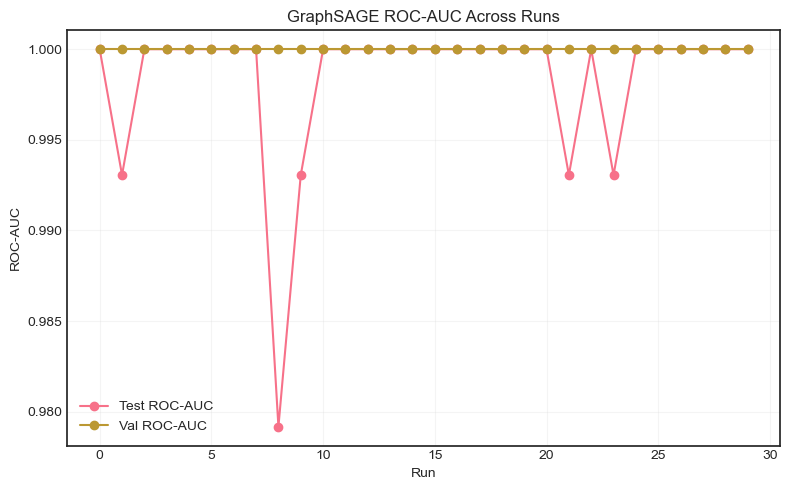

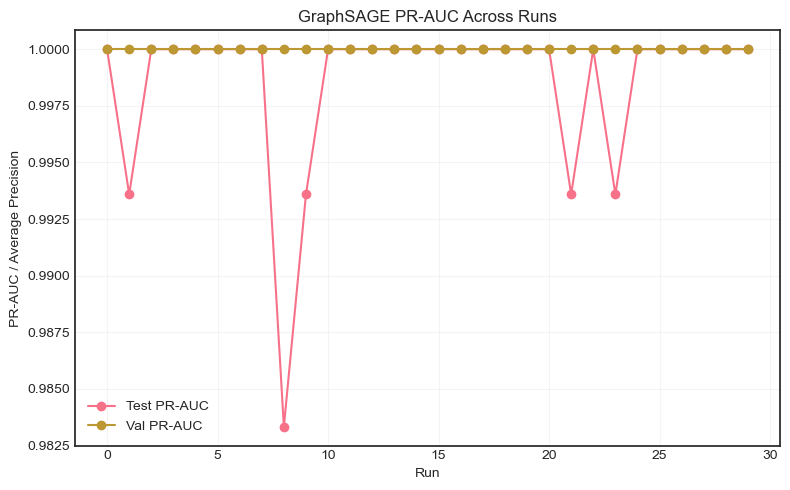

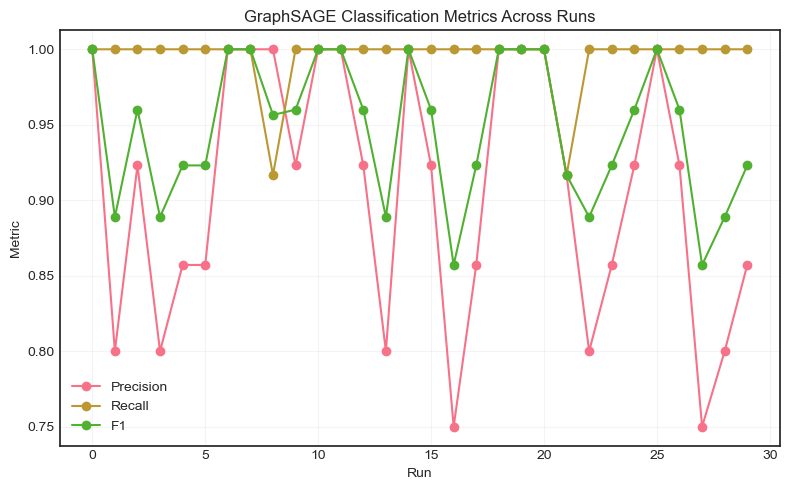

/var/folders/ql/zn64c29n0xbcthrddtdp57_m0000gn/T/ipykernel_95285/2278263973.py:566: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=["Test AUC", "Test AP", "Precision", "Recall", "F1"], showfliers=True)


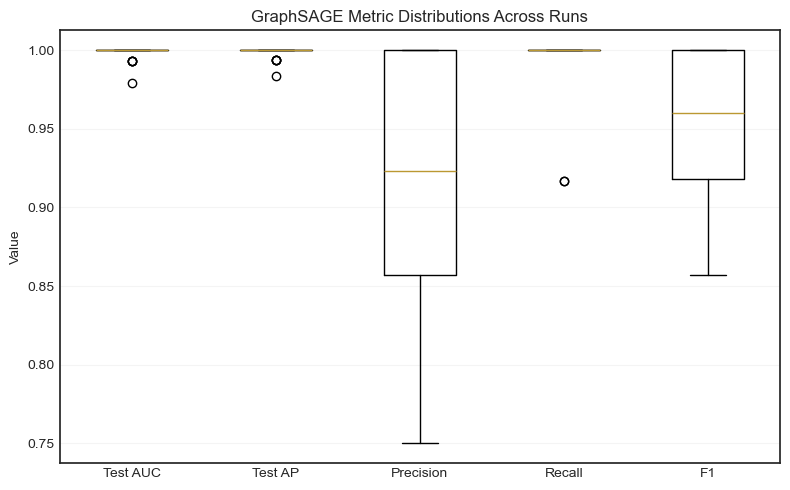


Saved: graphsage_neg_sampling_30runs_results_val_tuned_threshold.csv

Stored GraphSAGE models for ranking: 30

Ready for next cell:
- results_df, summary_df
- graphsage_models_per_run (per-run trained GraphSAGE + threshold + feature_cols)
- Variables used for scoring later: X_t, A_mean, node_to_idx, feature_cols


In [11]:
# ============================================================
# SELF-CONTAINED GraphSAGE (multi-run, masked node classification, reproducible)
# - Rebuilds scored_lookup if missing (from 'scored' DataFrame)
# - Uses threshold tuned on VAL (max F1) so P/R/F1 are meaningful
# - Reports ROC-AUC + PR-AUC (Average Precision) for VAL and TEST
# - Stores graphsage_models_per_run for averaged ranking later
# - Adds summary plots across runs
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support
)

print("=== TRAINING GraphSAGE ACROSS NEGATIVE SAMPLES (masked node classification; threshold tuned on VAL) ===")

# -----------------------------
# Reproducibility
# -----------------------------
GLOBAL_SEED = 42
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

FORCE_CPU = True
if FORCE_CPU:
    DEVICE = torch.device("cpu")
else:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

# -----------------------------
# Preconditions
# -----------------------------
if "G" not in globals():
    raise RuntimeError("G not found. Build the graph first.")
if "negative_gene_sets" not in globals():
    raise RuntimeError("negative_gene_sets not found. Run your negative sampling cell first.")
if "positive_genes" not in globals():
    raise RuntimeError("positive_genes not found.")

if "scored_lookup" not in globals():
    if "scored" not in globals():
        raise RuntimeError("Neither scored_lookup nor scored found. Run your scoring/negative-sampling cell first.")
    SCORED_COLS = [
        "gene",
        "ppr",
        "pos_w_ratio",
        "pos_w_sum",
        "pos_w_max",
        "pos_neighbor_count",
        "distance_to_positive",
        "prox",
        "hub_penalty",
        "final_score",
        "final_score_01",
    ]
    available_scored_cols = [c for c in SCORED_COLS if c in scored.columns]
    scored_lookup = (
        scored[available_scored_cols]
        .copy()
        .assign(gene=lambda d: d["gene"].astype(str))
        .drop_duplicates(subset=["gene"])
        .set_index("gene")
    )
    print(f"Rebuilt scored_lookup from scored (cols={len(available_scored_cols)})")

# -----------------------------
# Config
# -----------------------------
EXPECTED_RUNS = 30
SPLIT_SEED = 42
N_EPOCHS = 200
PATIENCE = 25
LR = 0.01
WEIGHT_DECAY = 1e-4

HIDDEN = 32
DROPOUT = 0.4

SCORED_MERGE = True
INCLUDE_SELF_IN_MEAN = True

n_runs = len(negative_gene_sets)
if n_runs != EXPECTED_RUNS:
    print(f"Warning: expected {EXPECTED_RUNS} negative sets, but found {n_runs}. Running with {n_runs} sets.")

# -----------------------------
# Precompute centralities ONCE
# -----------------------------
deg_cent = nx.degree_centrality(G)
try:
    btw_cent = nx.betweenness_centrality(G)
except Exception:
    btw_cent = {n: 0.0 for n in G.nodes()}
try:
    clo_cent = nx.closeness_centrality(G)
except Exception:
    clo_cent = {n: 0.0 for n in G.nodes()}
clust = nx.clustering(G)

def extract_structural_features(graph, gene):
    gene = str(gene)
    if gene not in graph:
        return None
    neighbors = list(graph.neighbors(gene))
    if not neighbors:
        return None

    neighbor_degrees = [graph.degree(n) for n in neighbors]
    neighbor_weights = [float(graph[gene][n].get("weight", 1.0)) for n in neighbors]

    row = {
        "gene": gene,
        "degree": graph.degree(gene),
        "clustering_coefficient": float(clust.get(gene, 0.0)),
        "neighbor_count": len(neighbors),
        "avg_neighbor_degree": float(np.mean(neighbor_degrees)) if neighbors else 0.0,
        "max_neighbor_degree": float(np.max(neighbor_degrees)) if neighbors else 0.0,
        "avg_edge_weight": float(np.mean(neighbor_weights)) if neighbors else 0.0,
        "max_edge_weight": float(np.max(neighbor_weights)) if neighbors else 0.0,
        "degree_centrality": float(deg_cent.get(gene, 0.0)),
        "betweenness_centrality": float(btw_cent.get(gene, 0.0)),
        "closeness_centrality": float(clo_cent.get(gene, 0.0)),
    }
    return row

# -----------------------------
# Global node indexing
# -----------------------------
nodes = [str(n) for n in G.nodes()]
node_to_idx = {n: i for i, n in enumerate(nodes)}
N = len(nodes)

# -----------------------------
# edge_index (undirected -> doubled)
# -----------------------------
edges = []
for u, v in G.edges():
    u = str(u)
    v = str(v)
    if u in node_to_idx and v in node_to_idx:
        ui = node_to_idx[u]
        vi = node_to_idx[v]
        edges.append((ui, vi))
        edges.append((vi, ui))
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
num_edges_dir = edge_index.size(1)

# -----------------------------
# Build all-node feature matrix X once
# -----------------------------
def build_all_node_features(graph):
    rows = []
    for g in nodes:
        r = extract_structural_features(graph, g)
        if r is None:
            r = {"gene": g}
        if SCORED_MERGE and g in scored_lookup.index:
            s = scored_lookup.loc[g].to_dict()
            s.pop("gene", None)
            r.update(s)
        r["gene"] = g
        rows.append(r)

    df = pd.DataFrame(rows).fillna(0)
    df = df.replace([np.inf, -np.inf], 0)

    genes = df["gene"].astype(str).values
    X_df = df.drop(columns=["gene"])

    for c in X_df.columns:
        X_df[c] = pd.to_numeric(X_df[c], errors="coerce").fillna(0.0)

    return genes, X_df

all_genes, X_df = build_all_node_features(G)
feature_cols = list(X_df.columns)
X = torch.tensor(X_df.values, dtype=torch.float32)

print(f"Graph nodes: {N} | directed edges: {num_edges_dir}")
print(f"Feature dim: {X.shape[1]} | scored_merge={SCORED_MERGE} | device={DEVICE}")

# -----------------------------
# Row-normalized adjacency for mean aggregation
# -----------------------------
def row_norm_adj(edge_index, num_nodes, include_self=True, device=None):
    if device is None:
        device = edge_index.device

    idx = edge_index.to(device)
    vals = torch.ones(idx.size(1), dtype=torch.float32, device=device)

    if include_self:
        self_loops = torch.arange(num_nodes, device=device)
        self_idx = torch.stack([self_loops, self_loops], dim=0)
        idx = torch.cat([idx, self_idx], dim=1)
        vals = torch.cat([vals, torch.ones(num_nodes, dtype=torch.float32, device=device)], dim=0)

    A = torch.sparse_coo_tensor(idx, vals, (num_nodes, num_nodes)).coalesce()
    deg = torch.sparse.sum(A, dim=1).to_dense()
    deg_inv = torch.pow(deg.clamp(min=1e-12), -1.0)

    row, col = A.indices()
    v = A.values() * deg_inv[row]
    A_mean = torch.sparse_coo_tensor(A.indices(), v, A.size()).coalesce()
    return A_mean

# -----------------------------
# GraphSAGE model
# -----------------------------
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, out_dim, bias=True)
        self.lin_neigh = nn.Linear(in_dim, out_dim, bias=True)

    def forward(self, x, A_mean):
        neigh = torch.sparse.mm(A_mean, x)
        out = self.lin_self(x) + self.lin_neigh(neigh)
        return out

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hid_dim, dropout=0.4):
        super().__init__()
        self.sage1 = GraphSAGELayer(in_dim, hid_dim)
        self.sage2 = GraphSAGELayer(hid_dim, 1)
        self.dropout = dropout

    def forward(self, X, A_mean):
        h = self.sage1(X, A_mean)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.sage2(h, A_mean).squeeze(-1)
        return out

# -----------------------------
# Metrics helpers
# -----------------------------
def sigmoid_np(x):
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + np.exp(-x))

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_score))

def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, y_score))

def make_masks(labeled_idx, y_labeled, split_seed=42, val_frac=0.2, test_frac=0.2):
    rng = np.random.RandomState(split_seed)
    labeled_idx = np.asarray(labeled_idx)
    y_labeled = np.asarray(y_labeled).astype(int)

    pos = labeled_idx[y_labeled == 1]
    neg = labeled_idx[y_labeled == 0]
    rng.shuffle(pos)
    rng.shuffle(neg)

    def split_class(arr):
        n = len(arr)
        n_test = int(np.round(test_frac * n))
        n_val = int(np.round(val_frac * (n - n_test)))
        test = arr[:n_test]
        val = arr[n_test:n_test+n_val]
        train = arr[n_test+n_val:]
        return train, val, test

    pos_tr, pos_va, pos_te = split_class(pos)
    neg_tr, neg_va, neg_te = split_class(neg)

    train_idx = np.concatenate([pos_tr, neg_tr])
    val_idx   = np.concatenate([pos_va, neg_va])
    test_idx  = np.concatenate([pos_te, neg_te])

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    train_mask = torch.zeros(N, dtype=torch.bool)
    val_mask   = torch.zeros(N, dtype=torch.bool)
    test_mask  = torch.zeros(N, dtype=torch.bool)

    train_mask[torch.tensor(train_idx, dtype=torch.long)] = True
    val_mask[torch.tensor(val_idx, dtype=torch.long)] = True
    test_mask[torch.tensor(test_idx, dtype=torch.long)] = True

    return train_mask, val_mask, test_mask

def best_threshold_by_f1(logits, y_all, mask_bool):
    mask = mask_bool.detach().cpu().numpy().astype(bool)
    y = y_all.detach().cpu().numpy()[mask].astype(int)
    l = logits.detach().cpu().numpy()[mask]
    p = sigmoid_np(l)

    thresholds = np.linspace(0.01, 0.99, 99)
    best = {"t": 0.5, "p": 0.0, "r": 0.0, "f1": -1.0}
    for t in thresholds:
        yhat = (p >= t).astype(int)
        prec, rec, f1, _ = precision_recall_fscore_support(y, yhat, average="binary", zero_division=0)
        f1 = float(f1)
        if f1 > best["f1"]:
            best = {"t": float(t), "p": float(prec), "r": float(rec), "f1": f1}
    return best

def eval_on_mask(logits, y_all, mask_bool, threshold):
    mask = mask_bool.detach().cpu().numpy().astype(bool)
    y = y_all.detach().cpu().numpy()[mask].astype(int)
    l = logits.detach().cpu().numpy()[mask]
    prob = sigmoid_np(l)
    yhat = (prob >= threshold).astype(int)

    auc = safe_auc(y, prob)
    ap = safe_ap(y, prob)

    prec, rec, f1, _ = precision_recall_fscore_support(y, yhat, average="binary", zero_division=0)
    return {
        "auc": auc,
        "ap": ap,
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "n": int(mask.sum()),
        "pos": int((y == 1).sum()),
        "neg": int((y == 0).sum()),
        "pred_pos": int((yhat == 1).sum())
    }

# -----------------------------
# Build y for each run
# -----------------------------
def build_labels_for_run(pos_genes, neg_genes):
    y = torch.full((N,), -1, dtype=torch.long)
    pos_set = set(map(str, pos_genes))
    neg_set = set(map(str, neg_genes))

    labeled_idx = []
    y_labeled = []

    for g in pos_set:
        if g in node_to_idx:
            labeled_idx.append(node_to_idx[g])
            y_labeled.append(1)
            y[node_to_idx[g]] = 1
    for g in neg_set:
        if g in node_to_idx:
            labeled_idx.append(node_to_idx[g])
            y_labeled.append(0)
            y[node_to_idx[g]] = 0

    return y, np.array(labeled_idx, dtype=int), np.array(y_labeled, dtype=int)

# -----------------------------
# Training across runs
# -----------------------------
A_mean = row_norm_adj(edge_index.to(DEVICE), N, include_self=INCLUDE_SELF_IN_MEAN, device=DEVICE)
X_t = X.to(DEVICE)

all_rows = []
graphsage_models_per_run = []

for run_id, neg_set in enumerate(negative_gene_sets):
    run_seed = GLOBAL_SEED + run_id
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)

    y_all, labeled_idx, y_labeled = build_labels_for_run(positive_genes, neg_set)
    y_all = y_all.to(DEVICE)

    train_mask, val_mask, test_mask = make_masks(
        labeled_idx=labeled_idx,
        y_labeled=y_labeled,
        split_seed=SPLIT_SEED,
        val_frac=0.2,
        test_frac=0.2
    )
    train_mask = train_mask.to(DEVICE)
    val_mask = val_mask.to(DEVICE)
    test_mask = test_mask.to(DEVICE)

    y_train_np = y_all[train_mask].detach().cpu().numpy()
    n_pos = int((y_train_np == 1).sum())
    n_neg = int((y_train_np == 0).sum())
    pos_weight = float(n_neg / max(1, n_pos))

    model = GraphSAGE(in_dim=X_t.shape[1], hid_dim=HIDDEN, dropout=DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, device=DEVICE))

    best_val_auc = -np.inf
    best_state = None
    best_epoch = 0
    bad = 0

    print(f"[RUN {run_id:02d}] labeled={len(labeled_idx)} (pos={int((y_labeled==1).sum())}, neg={int((y_labeled==0).sum())}) | device={DEVICE}")

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        opt.zero_grad()

        logits = model(X_t, A_mean)
        loss = loss_fn(logits[train_mask], y_all[train_mask].float())
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(X_t, A_mean)

        y_val = y_all[val_mask].detach().cpu().numpy().astype(int)
        val_prob = sigmoid_np(logits_eval[val_mask].detach().cpu().numpy())
        val_auc = safe_auc(y_val, val_prob)

        improved = (not np.isnan(val_auc)) and (val_auc > best_val_auc + 1e-6)
        if improved:
            best_val_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad = 0
        else:
            bad += 1

        if epoch == 1 or epoch % 25 == 0:
            if not np.isnan(val_auc) and len(np.unique(y_val)) == 2:
                bt_tmp = best_threshold_by_f1(logits_eval, y_all, val_mask)
                val_f1 = bt_tmp["f1"]
            else:
                val_f1 = 0.0
            print(f"    epoch={epoch:03d} loss={loss.item():.4f} val_auc={0.0 if np.isnan(val_auc) else val_auc:.3f} val_f1~{val_f1:.3f}")

        if bad >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        logits_final = model(X_t, A_mean)

    bt = best_threshold_by_f1(logits_final, y_all, val_mask)
    t_star = bt["t"]

    val_metrics = eval_on_mask(logits_final, y_all, val_mask, threshold=t_star)
    test_metrics = eval_on_mask(logits_final, y_all, test_mask, threshold=t_star)

    print(
        f"RUN {run_id:02d} | best_epoch={best_epoch} | "
        f"VAL AUC {val_metrics['auc']:.3f} AP {val_metrics['ap']:.3f} | "
        f"TEST AUC {test_metrics['auc']:.3f} AP {test_metrics['ap']:.3f} | "
        f"t*={t_star:.2f} | "
        f"TEST P {test_metrics['precision']:.3f} R {test_metrics['recall']:.3f} F1 {test_metrics['f1']:.3f} "
        f"| pred_pos={test_metrics['pred_pos']}/{test_metrics['n']} | pos_w={pos_weight:.2f}"
    )

    all_rows.append({
        "run": run_id,
        "labeled": int(len(labeled_idx)),
        "train_pos": int(n_pos),
        "train_neg": int(n_neg),
        "pos_weight": float(pos_weight),
        "best_epoch": int(best_epoch),
        "val_auc": float(val_metrics["auc"]),
        "val_ap": float(val_metrics["ap"]),
        "test_auc": float(test_metrics["auc"]),
        "test_ap": float(test_metrics["ap"]),
        "threshold": float(t_star),
        "precision": float(test_metrics["precision"]),
        "recall": float(test_metrics["recall"]),
        "f1": float(test_metrics["f1"]),
        "test_pred_pos": int(test_metrics["pred_pos"]),
        "test_n": int(test_metrics["n"]),
    })

    graphsage_models_per_run.append({
        "run_id": run_id,
        "model_name": "GraphSAGE",
        "model": model,
        "feature_cols": feature_cols,
        "node_to_idx": node_to_idx,
        "threshold": float(t_star),
        "device": str(DEVICE),
        "scored_merge": bool(SCORED_MERGE),
        "include_self_in_mean": bool(INCLUDE_SELF_IN_MEAN),
        "positive_genes_list": list(map(str, positive_genes)),
        "negative_genes_list": list(map(str, neg_set)),
    })

results_df = pd.DataFrame(all_rows)

print("\n=== SUMMARY (GraphSAGE across runs; threshold tuned on VAL) ===")
summary_df = results_df[["val_auc","val_ap","test_auc","test_ap","precision","recall","f1"]].agg(["mean","std"]).round(4)
print(summary_df.to_string())

plt.figure(figsize=(8, 5))
plt.plot(results_df["run"], results_df["test_auc"], marker="o", label="Test ROC-AUC")
plt.plot(results_df["run"], results_df["val_auc"], marker="o", label="Val ROC-AUC")
plt.xlabel("Run")
plt.ylabel("ROC-AUC")
plt.title("GraphSAGE ROC-AUC Across Runs")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results_df["run"], results_df["test_ap"], marker="o", label="Test PR-AUC")
plt.plot(results_df["run"], results_df["val_ap"], marker="o", label="Val PR-AUC")
plt.xlabel("Run")
plt.ylabel("PR-AUC / Average Precision")
plt.title("GraphSAGE PR-AUC Across Runs")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results_df["run"], results_df["precision"], marker="o", label="Precision")
plt.plot(results_df["run"], results_df["recall"], marker="o", label="Recall")
plt.plot(results_df["run"], results_df["f1"], marker="o", label="F1")
plt.xlabel("Run")
plt.ylabel("Metric")
plt.title("GraphSAGE Classification Metrics Across Runs")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
box_data = [
    results_df["test_auc"].values,
    results_df["test_ap"].values,
    results_df["precision"].values,
    results_df["recall"].values,
    results_df["f1"].values,
]
plt.boxplot(box_data, labels=["Test AUC", "Test AP", "Precision", "Recall", "F1"], showfliers=True)
plt.title("GraphSAGE Metric Distributions Across Runs")
plt.ylabel("Value")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

results_df.to_csv("graphsage_neg_sampling_30runs_results_val_tuned_threshold.csv", index=False)
print("\nSaved: graphsage_neg_sampling_30runs_results_val_tuned_threshold.csv")

print(f"\nStored GraphSAGE models for ranking: {len(graphsage_models_per_run)}")

print("\nReady for next cell:")
print("- results_df, summary_df")
print("- graphsage_models_per_run (per-run trained GraphSAGE + threshold + feature_cols)")
print("- Variables used for scoring later: X_t, A_mean, node_to_idx, feature_cols")

=== AVERAGED GraphSAGE RANKING ACROSS RUNS ===
Grouping mode: UNION of negatives across 30 runs
Scoring mode: MEAN over 30 runs | model=GraphSAGE
Unlabeled genes: 659
Unique unlabeled scores: 658
Top score: 0.996373 | Unlabeled genes at top score: 1
Unlabeled rows with duplicated feature vectors (RUN 0 feature space): 2 / 659

Most frequent unlabeled score values (top 10):
model_score
0.856752    2
0.955244    1
0.962958    1
0.970548    1
0.969981    1
0.965131    1
0.963524    1
0.903169    1
0.952930    1
0.942446    1


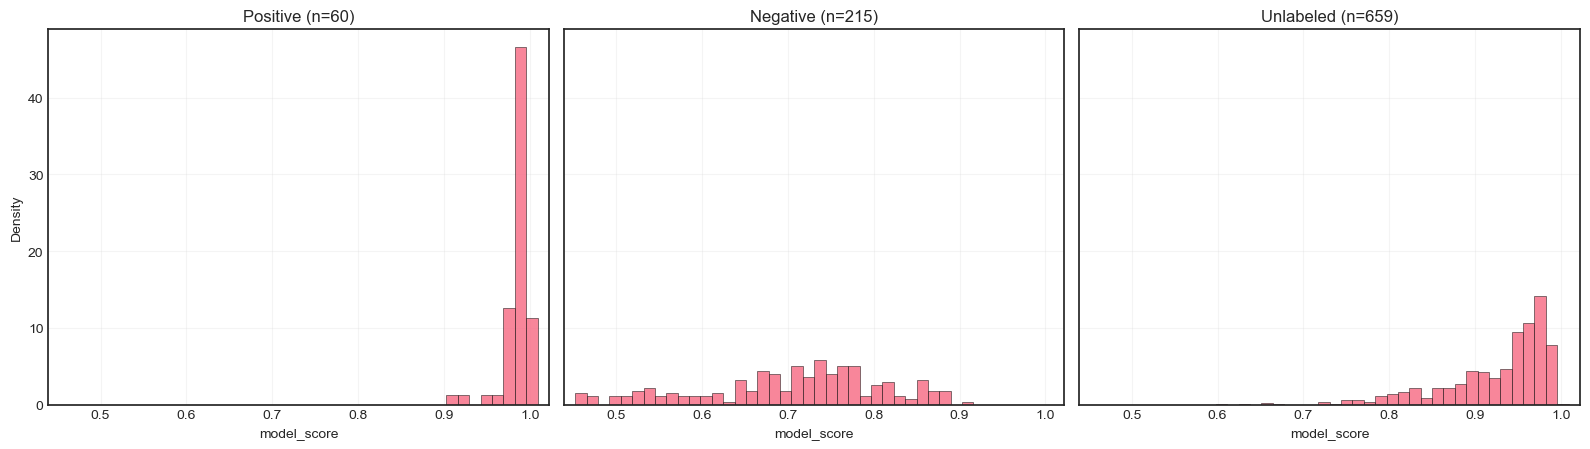


Top 40 unlabeled genes ranked by averaged GraphSAGE score:
 rank     gene  model_score  model_score_std  model_score_min  model_score_max  degree  max_neighbor_degree
    1       TH     0.996373         0.010306         0.949113              1.0      37                 87.0
    2    OPRM1     0.994461         0.014434         0.923058              1.0      28                 60.0
    3    HIF1A     0.993828         0.018307         0.900581              1.0      31                 67.0
    4      CCK     0.993597         0.022312         0.875529              1.0      28                 67.0
    5     FGF5     0.993500         0.027786         0.844680              1.0      18                 87.0
    6 SERPINE1     0.993144         0.021385         0.883300              1.0      21                 67.0
    7   GRIN2A     0.993001         0.019706         0.914565              1.0      53                 87.0
    8   CAMK2A     0.992989         0.022389         0.882120              1

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import networkx as nx

print("=== AVERAGED GraphSAGE RANKING ACROSS RUNS ===")

# -----------------------------
# 0) Preconditions
# -----------------------------
if "graphsage_models_per_run" not in globals() or len(graphsage_models_per_run) == 0:
    raise NameError("graphsage_models_per_run not found (or empty). Run the revised GraphSAGE multi-run training cell first.")
if "G" not in globals():
    raise NameError("G not found. Build the network first.")
if "positive_genes" not in globals():
    raise NameError("positive_genes not found.")
if "negative_gene_sets" not in globals():
    raise NameError("negative_gene_sets not found.")
if "scored_lookup" not in globals():
    print("Warning: scored_lookup not found. Will score using only structural features.")

# -----------------------------
# Config
# -----------------------------
RUN_ID = 0
SCORE_MODE = "mean"          # "single" or "mean"
NEG_GROUP_MODE = "union"     # "union" or "single_run"
OUT_PATH = "Results/GraphSAGE_mean_30runs_results.csv"

# -----------------------------
# 1) Choose run info + define groups
# -----------------------------
n_runs = len(graphsage_models_per_run)
if RUN_ID < 0 or RUN_ID >= n_runs:
    raise ValueError(f"RUN_ID must be in [0, {n_runs-1}]")

info0 = graphsage_models_per_run[RUN_ID]
feature_cols0 = list(info0["feature_cols"])

pos_set = set(map(str, positive_genes))

if NEG_GROUP_MODE == "single_run":
    neg_set = set(map(str, graphsage_models_per_run[RUN_ID]["negative_genes_list"]))
    print(f"Grouping mode: negatives from RUN {RUN_ID} only")
elif NEG_GROUP_MODE == "union":
    neg_set = set()
    for rinfo in graphsage_models_per_run:
        neg_set.update(map(str, rinfo["negative_genes_list"]))
    print(f"Grouping mode: UNION of negatives across {n_runs} runs")
else:
    raise ValueError("NEG_GROUP_MODE must be 'union' or 'single_run'")

def assign_group(g):
    g = str(g)
    if g in pos_set:
        return "positive"
    if g in neg_set:
        return "negative"
    return "unlabeled"

# -----------------------------
# 2) Build node order + row-normalized adjacency
# -----------------------------
nodes = [str(n) for n in G.nodes()]
node_to_idx = {n: i for i, n in enumerate(nodes)}
N = len(nodes)

edges = []
for u, v in G.edges():
    u = str(u)
    v = str(v)
    if u in node_to_idx and v in node_to_idx:
        ui = node_to_idx[u]
        vi = node_to_idx[v]
        edges.append((ui, vi))
        edges.append((vi, ui))
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

def row_norm_adj(edge_index, num_nodes, include_self=True, device=None):
    if device is None:
        device = edge_index.device

    idx = edge_index.to(device)
    vals = torch.ones(idx.size(1), dtype=torch.float32, device=device)

    if include_self:
        self_loops = torch.arange(num_nodes, device=device)
        self_idx = torch.stack([self_loops, self_loops], dim=0)
        idx = torch.cat([idx, self_idx], dim=1)
        vals = torch.cat([vals, torch.ones(num_nodes, dtype=torch.float32, device=device)], dim=0)

    A = torch.sparse_coo_tensor(idx, vals, (num_nodes, num_nodes)).coalesce()
    deg = torch.sparse.sum(A, dim=1).to_dense()
    deg_inv = torch.pow(deg.clamp(min=1e-12), -1.0)

    row, col = A.indices()
    v = A.values() * deg_inv[row]
    A_mean = torch.sparse_coo_tensor(A.indices(), v, A.size()).coalesce()
    return A_mean

# -----------------------------
# 3) Build all-node feature table aligned to training feature cols
# -----------------------------
deg_cent = nx.degree_centrality(G)
try:
    btw_cent = nx.betweenness_centrality(G)
except Exception:
    btw_cent = {n: 0.0 for n in G.nodes()}
try:
    clo_cent = nx.closeness_centrality(G)
except Exception:
    clo_cent = {n: 0.0 for n in G.nodes()}
clust = nx.clustering(G)

def extract_structural_features(graph, gene):
    gene = str(gene)
    if gene not in graph:
        return None
    neighbors = list(graph.neighbors(gene))
    if not neighbors:
        return None

    neighbor_degrees = [graph.degree(n) for n in neighbors]
    neighbor_weights = [float(graph[gene][n].get("weight", 1.0)) for n in neighbors]

    return {
        "gene": gene,
        "degree": graph.degree(gene),
        "clustering_coefficient": float(clust.get(gene, 0.0)),
        "neighbor_count": len(neighbors),
        "avg_neighbor_degree": float(np.mean(neighbor_degrees)) if neighbors else 0.0,
        "max_neighbor_degree": float(np.max(neighbor_degrees)) if neighbors else 0.0,
        "avg_edge_weight": float(np.mean(neighbor_weights)) if neighbors else 0.0,
        "max_edge_weight": float(np.max(neighbor_weights)) if neighbors else 0.0,
        "degree_centrality": float(deg_cent.get(gene, 0.0)),
        "betweenness_centrality": float(btw_cent.get(gene, 0.0)),
        "closeness_centrality": float(clo_cent.get(gene, 0.0)),
    }

def build_all_feature_df(feature_cols):
    rows = []
    for g in nodes:
        r = extract_structural_features(G, g)
        if r is None:
            r = {"gene": g}

        if "scored_lookup" in globals() and g in scored_lookup.index:
            s = scored_lookup.loc[g].to_dict()
            s.pop("gene", None)
            r.update(s)

        r["gene"] = g
        rows.append(r)

    df = pd.DataFrame(rows)
    df["gene"] = df["gene"].astype(str)

    for c in feature_cols:
        if c not in df.columns:
            df[c] = 0.0

    X_df = df[feature_cols].copy()
    X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    for c in X_df.columns:
        X_df[c] = pd.to_numeric(X_df[c], errors="coerce").fillna(0.0)

    return df, X_df

all_df0, X_feat0 = build_all_feature_df(feature_cols0)
all_df0["group"] = all_df0["gene"].apply(assign_group)

# -----------------------------
# 4) Score with GraphSAGE
# -----------------------------
def _sigmoid_np(x):
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + np.exp(-x))

score_device = torch.device("cpu")

def _score_graphsage(run_info, X_feat_df):
    model = run_info["model"]
    fcols = list(run_info["feature_cols"])
    include_self = bool(run_info.get("include_self_in_mean", True))

    X_np = X_feat_df[fcols].values.astype(np.float32)
    X_t = torch.tensor(X_np, dtype=torch.float32, device=score_device)
    A_mean = row_norm_adj(edge_index, N, include_self=include_self, device=score_device)

    model = model.to(score_device)
    model.eval()
    with torch.no_grad():
        logits = model(X_t, A_mean).detach().cpu().numpy()

    return _sigmoid_np(logits)

if SCORE_MODE == "single":
    scores_all = _score_graphsage(info0, X_feat0)
    all_df = all_df0.copy()
    all_df["model_score"] = scores_all
    print(f"Scoring mode: SINGLE run {RUN_ID} | model=GraphSAGE | features={len(feature_cols0)}")

elif SCORE_MODE == "mean":
    score_mat = []
    for rinfo in graphsage_models_per_run:
        _, X_feat_r = build_all_feature_df(list(rinfo["feature_cols"]))
        score_mat.append(_score_graphsage(rinfo, X_feat_r))

    score_mat = np.vstack(score_mat)

    all_df = all_df0.copy()
    all_df["model_score_mean"] = score_mat.mean(axis=0)
    all_df["model_score_std"] = score_mat.std(axis=0)
    all_df["model_score_min"] = score_mat.min(axis=0)
    all_df["model_score_max"] = score_mat.max(axis=0)
    all_df["model_score"] = all_df["model_score_mean"]

    print(f"Scoring mode: MEAN over {n_runs} runs | model=GraphSAGE")
else:
    raise ValueError("SCORE_MODE must be 'single' or 'mean'.")

# -----------------------------
# 5) Tie diagnostics
# -----------------------------
unl = all_df[all_df["group"] == "unlabeled"].copy()
n_unl = len(unl)
n_unique = unl["model_score"].nunique(dropna=False) if n_unl else 0
top_score = float(unl["model_score"].max()) if n_unl else np.nan
n_at_top = int((unl["model_score"] == top_score).sum()) if n_unl else 0

if n_unl:
    X_unl = X_feat0.loc[unl.index].copy()
    n_dup = int(X_unl.duplicated(keep=False).sum())
else:
    n_dup = 0

print(f"Unlabeled genes: {n_unl}")
print(f"Unique unlabeled scores: {n_unique}")
if n_unl:
    print(f"Top score: {top_score:.6f} | Unlabeled genes at top score: {n_at_top}")
    print(f"Unlabeled rows with duplicated feature vectors (RUN {RUN_ID} feature space): {n_dup} / {n_unl}")
    print("\nMost frequent unlabeled score values (top 10):")
    print(unl["model_score"].value_counts().head(10).to_string())

# -----------------------------
# 6) Plot score distributions
# -----------------------------
pos_scores = all_df.loc[all_df["group"] == "positive", "model_score"].values
neg_scores = all_df.loc[all_df["group"] == "negative", "model_score"].values
unl_scores = all_df.loc[all_df["group"] == "unlabeled", "model_score"].values

all_scores = np.concatenate([pos_scores, neg_scores, unl_scores]) if len(all_df) else np.array([])
if len(all_scores) == 0:
    raise RuntimeError("No scores computed (all_scores empty).")

lo, hi = np.quantile(all_scores, [0.01, 0.99])
if lo == hi:
    lo, hi = float(np.min(all_scores)), float(np.max(all_scores))
pad = 0.05 * (hi - lo + 1e-9)
x_min, x_max = lo - pad, hi + pad
bins = np.linspace(x_min, x_max, 45)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, sharey=True)

axes[0].hist(pos_scores, bins=bins, density=True, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[0].set_title(f"Positive (n={len(pos_scores)})")
axes[0].set_xlabel("model_score")
axes[0].set_ylabel("Density")
axes[0].grid(alpha=0.2)

axes[1].hist(neg_scores, bins=bins, density=True, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[1].set_title(f"Negative (n={len(neg_scores)})")
axes[1].set_xlabel("model_score")
axes[1].grid(alpha=0.2)

axes[2].hist(unl_scores, bins=bins, density=True, alpha=0.85, edgecolor="black", linewidth=0.4)
axes[2].set_title(f"Unlabeled (n={len(unl_scores)})")
axes[2].set_xlabel("model_score")
axes[2].grid(alpha=0.2)

for ax in axes:
    ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

# -----------------------------
# 7) Ranked candidates
# -----------------------------
rank_df = all_df[all_df["group"] == "unlabeled"][["gene", "model_score"]].copy()

tie_cols = [c for c in ["pos_weight_fraction", "degree", "max_neighbor_degree"] if c in all_df.columns]
for c in tie_cols:
    rank_df[c] = all_df.loc[rank_df.index, c].values

if SCORE_MODE == "mean" and "model_score_std" in all_df.columns:
    rank_df["model_score_std"] = all_df.loc[rank_df.index, "model_score_std"].values
    rank_df["model_score_min"] = all_df.loc[rank_df.index, "model_score_min"].values
    rank_df["model_score_max"] = all_df.loc[rank_df.index, "model_score_max"].values
    sort_cols = ["model_score", "model_score_std"] + tie_cols + ["gene"]
    ascending = [False, True] + [False] * len(tie_cols) + [True]
else:
    sort_cols = ["model_score"] + tie_cols + ["gene"]
    ascending = [False] + [False] * len(tie_cols) + [True]

rank_df = rank_df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)
rank_df["rank"] = np.arange(1, len(rank_df) + 1)

print("\nTop 40 unlabeled genes ranked by averaged GraphSAGE score:")
show_cols = ["rank", "gene", "model_score"]
if SCORE_MODE == "mean" and "model_score_std" in rank_df.columns:
    show_cols += ["model_score_std", "model_score_min", "model_score_max"]
show_cols += tie_cols
print(rank_df.head(40)[show_cols].to_string(index=False))

# Convenience outputs
rank_candidates_df = rank_df.copy()
scored_all_df = all_df.copy()

print("\nSaved in memory:")
print("- rank_candidates_df (unlabeled ranking)")
print("- scored_all_df (all nodes with group + model_score)")

rank_candidates_df.to_csv(OUT_PATH, index=False)
print(f"\nSaved unlabeled candidate genes to: {OUT_PATH}")

In [15]:
import numpy as np
import pandas as pd

print("=== SCORE DISTRIBUTION SUMMARY (UNLABELED GENES ONLY) ===")

# -----------------------------
# Preconditions
# -----------------------------
if "scored_all_df" not in globals():
    raise NameError("scored_all_df not found. Run the scoring cell first.")
if "model_score" not in scored_all_df.columns:
    raise NameError("model_score column not found in scored_all_df.")

# -----------------------------
# Select unlabeled genes
# -----------------------------
unl_df = scored_all_df[scored_all_df["group"] == "unlabeled"].copy()

if len(unl_df) == 0:
    raise RuntimeError("No unlabeled genes found.")

scores = unl_df["model_score"].astype(float).values

# -----------------------------
# Basic distribution statistics
# -----------------------------
summary = {
    "n_unlabeled": len(scores),
    "mean": np.mean(scores),
    "std": np.std(scores),
    "min": np.min(scores),
    "q25": np.quantile(scores, 0.25),
    "median": np.quantile(scores, 0.50),
    "q75": np.quantile(scores, 0.75),
    "max": np.max(scores),
    "q90": np.quantile(scores, 0.90),
    "q95": np.quantile(scores, 0.95),
    "q99": np.quantile(scores, 0.99),
}

summary_df = pd.DataFrame(summary, index=["value"]).T
summary_df["value"] = summary_df["value"].astype(float)

print("\n--- Distribution statistics (unlabeled genes) ---")
print(summary_df.round(6).to_string())

# -----------------------------
# Concentration diagnostics
# -----------------------------
q95 = summary["q95"]
q99 = summary["q99"]

prop_above_95 = np.mean(scores >= q95)
prop_above_99 = np.mean(scores >= q99)

print("\n--- Score concentration diagnostics ---")
print(f"Genes ≥ 95th percentile score: {prop_above_95:.3%}")
print(f"Genes ≥ 99th percentile score: {prop_above_99:.3%}")

# -----------------------------
# Optional: detect heavy tails
# -----------------------------
iqr = summary["q75"] - summary["q25"]
upper_fence = summary["q75"] + 1.5 * iqr
n_outliers = int(np.sum(scores > upper_fence))

print("\n--- Tail behavior ---")
print(f"IQR: {iqr:.6f}")
print(f"Upper fence (Q75 + 1.5*IQR): {upper_fence:.6f}")
print(f"High-score outliers above upper fence: {n_outliers} ({n_outliers / len(scores):.3%})")

print("\nDone. These statistics can be used to summarize score distributions in the Results section.")


=== SCORE DISTRIBUTION SUMMARY (UNLABELED GENES ONLY) ===

--- Distribution statistics (unlabeled genes) ---
                  value
n_unlabeled  659.000000
mean           0.925741
std            0.063384
min            0.607791
q25            0.898752
median         0.947938
q75            0.971388
max            0.996373
q90            0.982820
q95            0.988646
q99            0.992994

--- Score concentration diagnostics ---
Genes ≥ 95th percentile score: 5.008%
Genes ≥ 99th percentile score: 1.062%

--- Tail behavior ---
IQR: 0.072636
Upper fence (Q75 + 1.5*IQR): 1.080341
High-score outliers above upper fence: 0 (0.000%)

Done. These statistics can be used to summarize score distributions in the Results section.


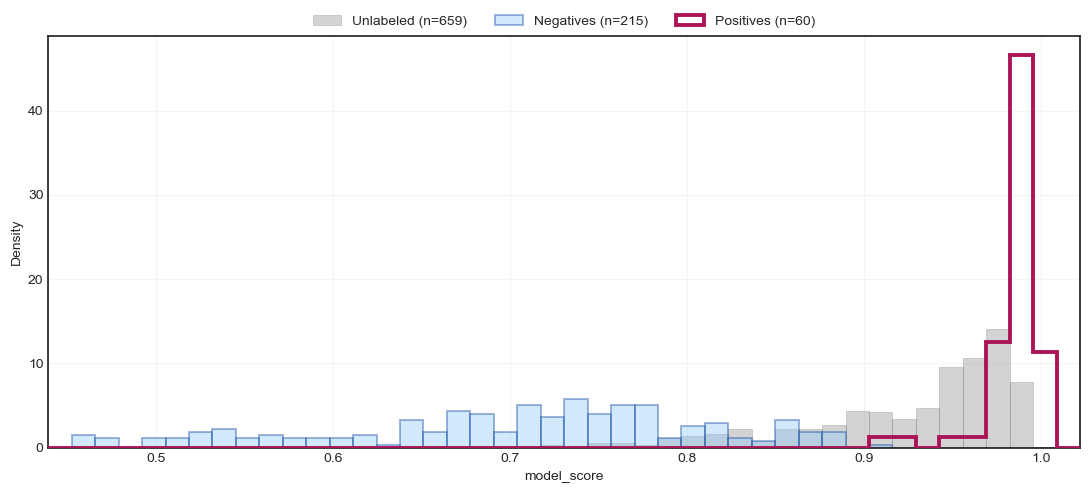

In [17]:
# =======================================================
# 5b) Combined overlay plot (final paper styling)
# =======================================================
COL_UNL_FILL = "#6E6E6E"    # dark gray (unlabeled)
COL_POS_EDGE = "#AD1457"    # dark pink margin (positives)
COL_NEG_FILL = "#90CAF9"    # light blue fill (negatives)
COL_NEG_EDGE = "#0D47A1"    # dark blue margin (negatives)

plt.figure(figsize=(11, 5))

# Unlabeled: dark gray filled
plt.hist(
    unl_scores,
    bins=bins,
    density=True,
    alpha=0.30,
    color=COL_UNL_FILL,
    edgecolor=COL_UNL_FILL,
    linewidth=0.6,
    label=f"Unlabeled (n={len(unl_scores)})",
    zorder=1,
)

# Negatives: blue filled with dark blue margin
plt.hist(
    neg_scores,
    bins=bins,
    density=True,
    alpha=0.40,
    color=COL_NEG_FILL,
    edgecolor=COL_NEG_EDGE,
    linewidth=1.4,
    label=f"Negatives (n={len(neg_scores)})",
    zorder=2,
)

# Positives: unfilled with dark pink margin
plt.hist(
    pos_scores,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2.8,
    color=COL_POS_EDGE,
    label=f"Positives (n={len(pos_scores)})",
    zorder=4,
)

plt.xlim(x_min, x_max)
plt.xlabel("model_score")
plt.ylabel("Density")
plt.grid(alpha=0.2)

# Legend / description at upper center
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False,
)

plt.tight_layout()
plt.savefig("Results/GSAGE.png",
            dpi=300, bbox_inches="tight")
plt.show()


In [19]:
# Validation - Leave out 10% of positives

=== ONE-CELL: LEAVE-10%-OUT POSITIVE PERCENTILE RANKING RECOVERY + NEGATIVE SELECTION + GraphSAGE ===
Percentile definition: 100 = best rank, 0 = worst rank
Ranking pool: unlabeled genes only + hidden positives forced back for evaluation
Initial STRING graph: 1020 nodes, 4198 edges
Positive genes in graph before component filtering: 60
Removed 86 genes from components with no positive connection
Filtered graph: 934 nodes, 4150 edges
Positive genes in filtered graph: 60
[RUN 00] train_pos=54 | hidden_pos=6 | eligible_neg=221 | sampled_neg=54 | feature_dim=18
    epoch=001 loss=1.0902 val_auc=1.000 val_ap=1.000
    epoch=025 loss=0.0829 val_auc=1.000 val_ap=1.000
RUN 00 | best_epoch=1 | VAL AUC 1.000 AP 1.000 | candidate_count=826 | mean_hidden_percentile=69.52 | median_hidden_percentile=70.42
[RUN 01] train_pos=54 | hidden_pos=6 | eligible_neg=228 | sampled_neg=54 | feature_dim=18
    epoch=001 loss=0.9444 val_auc=0.983 val_ap=0.986
    epoch=025 loss=0.0051 val_auc=1.000 val_ap=1.000
R

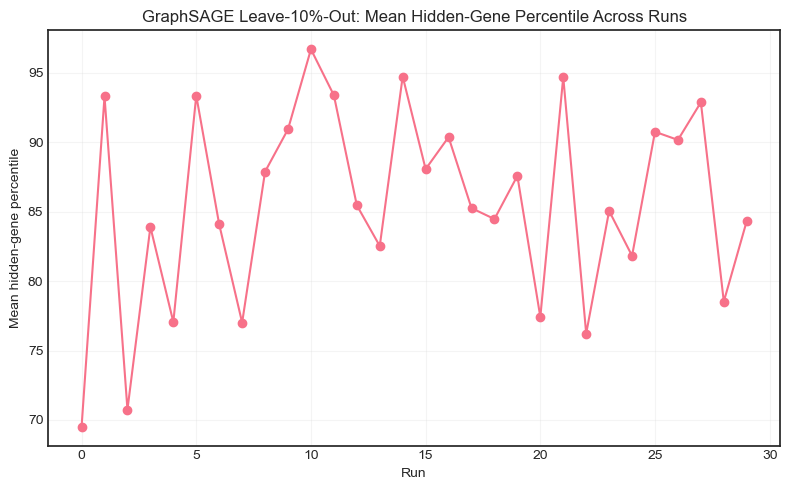

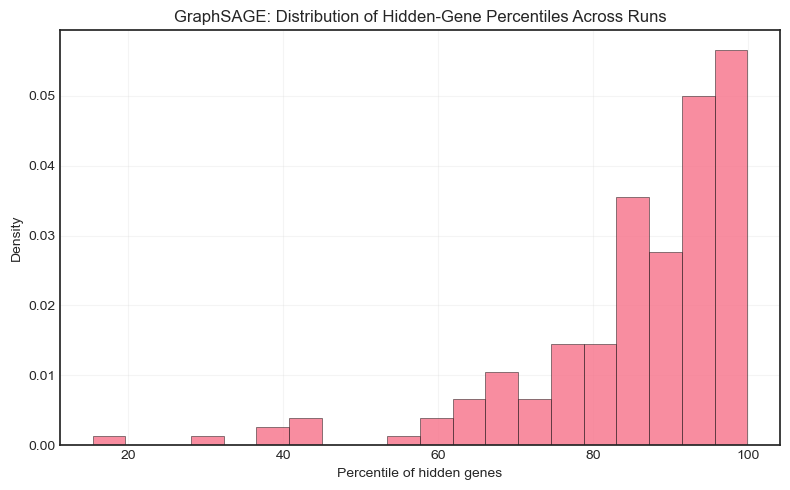

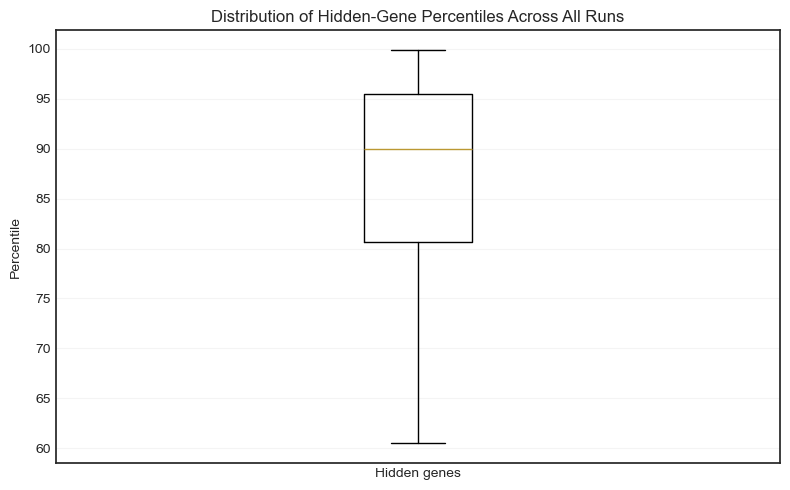

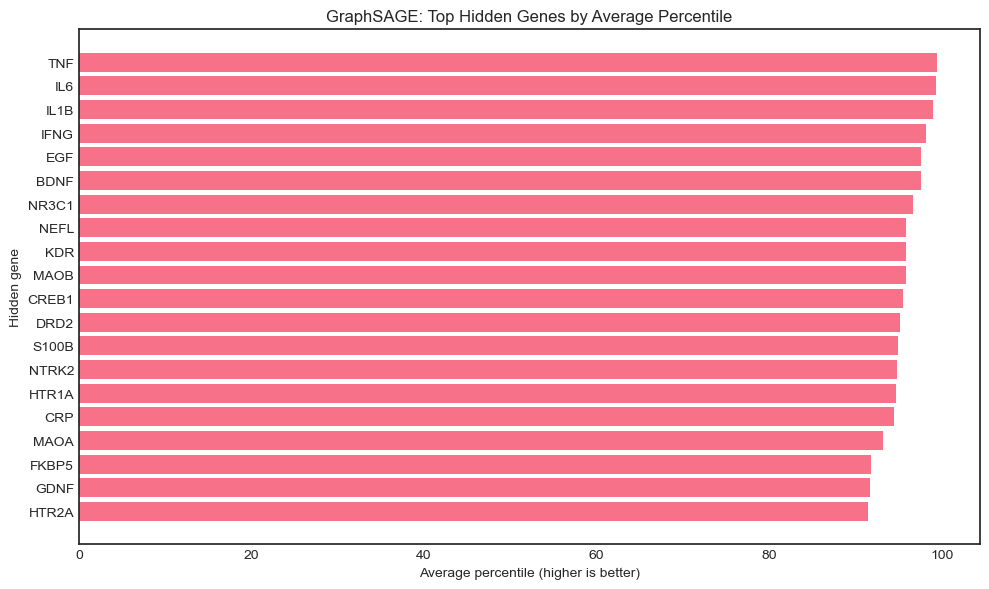

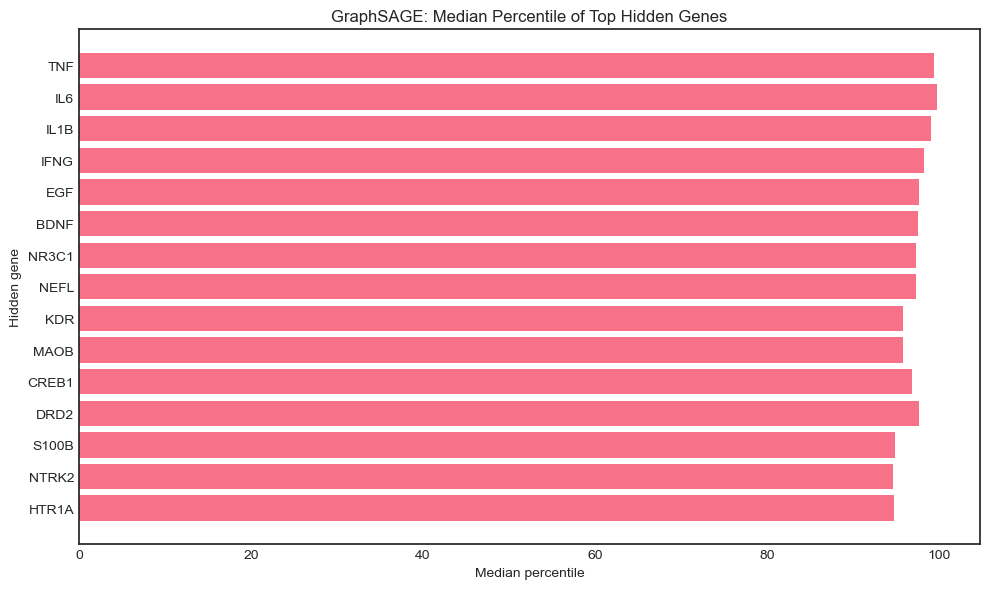


Saved:
- graphsage_leave10_percentile_results.csv
- graphsage_leave10_hidden_gene_percentile_long.csv
- graphsage_leave10_hidden_gene_percentile_summary.csv
- graphsage_leave10_hidden_gene_percentiles_by_run.csv
- graphsage_leave10_negative_gene_sets.csv
- graphsage_leave10_scored_run0.csv

Ready objects:
- G
- positive_genes
- negative_gene_sets_graphsage
- results_df
- hidden_gene_percentile_df
- gene_percentile_summary
- per_gene_per_run_percentiles
- graphsage_models_per_run
- scored_tables_per_run


In [34]:
# ============================================================
# ONE-CELL PIPELINE:
# Leave-10%-out positive percentile ranking recovery
# + negative selection + GraphSAGE
#
# REVISED:
# - ranking is over UNLABELED genes only
# - training positives are excluded from ranking
# - sampled negatives are excluded from ranking
# - hidden positives are forced back into the ranking pool for evaluation
# - shows unlabeled candidate count per run
# ============================================================

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from collections import deque
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)

print("=== ONE-CELL: LEAVE-10%-OUT POSITIVE PERCENTILE RANKING RECOVERY + NEGATIVE SELECTION + GraphSAGE ===")
print("Percentile definition: 100 = best rank, 0 = worst rank")
print("Ranking pool: unlabeled genes only + hidden positives forced back for evaluation")

# =======================================================
# 0) Reproducibility
# =======================================================
GLOBAL_SEED = 42
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

FORCE_CPU = True
DEVICE = torch.device("cpu") if FORCE_CPU else torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

# =======================================================
# 1) Config
# =======================================================
EDGE_THRESHOLD = 0.6

NEG_Q = 0.50
EXCLUDE_DIST = 2

N_RUNS = 30
BASE_SEED = 42
HOLDOUT_POS_FRAC = 0.10

WEIGHTS = {
    "ppr": 3.0,
    "pos_w_ratio": 2.0,
    "pos_w_sum": 1.5,
    "pos_w_max": 1.0,
    "prox": 1.5,
    "hub_penalty": -1.0
}
PROX_ALPHA = 0.7

VAL_FRAC = 0.20

# GraphSAGE
N_EPOCHS = 200
PATIENCE = 25
LR = 0.01
WEIGHT_DECAY = 1e-4
HIDDEN = 32
DROPOUT = 0.4
INCLUDE_SELF_IN_MEAN = True

# Ranking settings
EXCLUDE_SAMPLED_NEGATIVES_FROM_RANKING = True
RANK_UNLABELED_ONLY = True

# =======================================================
# 2) Preconditions
# =======================================================
if "interactions" not in globals():
    raise RuntimeError("interactions not found.")
if "filtered_result" not in globals():
    raise RuntimeError("filtered_result not found.")

# =======================================================
# 3) Helpers
# =======================================================
def multi_source_bfs_distances(graph, sources):
    dist = {n: np.inf for n in graph.nodes()}
    q = deque()
    for s in sources:
        if s in graph:
            dist[s] = 0
            q.append(s)
    while q:
        u = q.popleft()
        for v in graph.neighbors(u):
            if dist[v] == np.inf:
                dist[v] = dist[u] + 1
                q.append(v)
    return dist

def sigmoid_np(x):
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + np.exp(-x))

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_score))

def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, y_score))

def split_train_holdout_positives(pos_genes, holdout_frac, seed):
    pos_genes = np.array(sorted(set(map(str, pos_genes))))
    rng = np.random.RandomState(seed)
    rng.shuffle(pos_genes)
    n_holdout = max(1, int(np.round(holdout_frac * len(pos_genes))))
    heldout = pos_genes[:n_holdout].tolist()
    train_pos = pos_genes[n_holdout:].tolist()
    return train_pos, heldout

def make_train_val_masks(labeled_idx, y_labeled, n_nodes, split_seed=42, val_frac=0.2):
    rng = np.random.RandomState(split_seed)
    labeled_idx = np.asarray(labeled_idx)
    y_labeled = np.asarray(y_labeled).astype(int)

    pos = labeled_idx[y_labeled == 1]
    neg = labeled_idx[y_labeled == 0]
    rng.shuffle(pos)
    rng.shuffle(neg)

    def split_class(arr):
        n = len(arr)
        n_val = max(1, int(np.round(val_frac * n))) if n > 1 else 0
        val = arr[:n_val]
        train = arr[n_val:]
        return train, val

    pos_tr, pos_va = split_class(pos)
    neg_tr, neg_va = split_class(neg)

    train_idx = np.concatenate([pos_tr, neg_tr]) if len(pos_tr) + len(neg_tr) > 0 else np.array([], dtype=int)
    val_idx = np.concatenate([pos_va, neg_va]) if len(pos_va) + len(neg_va) > 0 else np.array([], dtype=int)

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    train_mask = torch.zeros(n_nodes, dtype=torch.bool)
    val_mask = torch.zeros(n_nodes, dtype=torch.bool)

    if len(train_idx) > 0:
        train_mask[torch.tensor(train_idx, dtype=torch.long)] = True
    if len(val_idx) > 0:
        val_mask[torch.tensor(val_idx, dtype=torch.long)] = True

    return train_mask, val_mask

def evaluate_hidden_percentile_ranking(
    logits_np,
    nodes,
    node_to_idx,
    train_positive_genes,
    heldout_positive_genes,
    sampled_negative_genes=None,
    exclude_sampled_negatives=True,
    rank_unlabeled_only=True
):
    train_pos_set = set(map(str, train_positive_genes))
    heldout_set = set(map(str, heldout_positive_genes))
    neg_set = set(map(str, sampled_negative_genes)) if sampled_negative_genes is not None else set()

    if rank_unlabeled_only:
        candidate_genes = [g for g in nodes if (g not in train_pos_set) and (g not in neg_set)]
    else:
        candidate_genes = [g for g in nodes if g not in train_pos_set]
        if exclude_sampled_negatives:
            candidate_genes = [g for g in candidate_genes if g not in neg_set]

    for g in heldout_set:
        if g not in candidate_genes and g in node_to_idx:
            candidate_genes.append(g)

    candidate_genes = sorted(set(candidate_genes))

    candidate_probs = np.array(
        [sigmoid_np([logits_np[node_to_idx[g]]])[0] for g in candidate_genes],
        dtype=float
    )

    order = np.argsort(-candidate_probs)
    ranked_genes = [candidate_genes[i] for i in order]
    ranked_probs = candidate_probs[order]

    rank_map = {g: i + 1 for i, g in enumerate(ranked_genes)}
    prob_map = {g: float(ranked_probs[i]) for i, g in enumerate(ranked_genes)}

    n_candidates = len(ranked_genes)

    rows = []
    for g in map(str, heldout_positive_genes):
        if g not in rank_map:
            rows.append({
                "hidden_gene": g,
                "prob": np.nan,
                "rank": np.nan,
                "percentile": np.nan
            })
            continue

        rank_i = rank_map[g]
        pct = 100.0 if n_candidates <= 1 else 100.0 * (1.0 - (rank_i - 1) / (n_candidates - 1))

        rows.append({
            "hidden_gene": g,
            "prob": prob_map[g],
            "rank": rank_i,
            "percentile": pct
        })

    hidden_df = pd.DataFrame(rows)

    return {
        "candidate_count": int(n_candidates),
        "hidden_df": hidden_df
    }

# =======================================================
# 4) Build weighted graph ONCE
# =======================================================
high_conf_interactions = [(a, b, w) for a, b, w in interactions if w >= EDGE_THRESHOLD]

G = nx.Graph()
for a, b, w in high_conf_interactions:
    G.add_edge(str(a), str(b), weight=float(w))

print(f"Initial STRING graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

full_positive_genes = set(filtered_result["gene_symbol"].dropna().astype(str).unique())
nx.set_node_attributes(G, {n: (1 if n in full_positive_genes else 0) for n in G.nodes()}, "positive")

pos_in_graph_before = [n for n in G.nodes() if G.nodes[n].get("positive", 0) == 1]
print(f"Positive genes in graph before component filtering: {len(pos_in_graph_before)}")

positive_nodes_set = set(pos_in_graph_before)
reachable_from_positive = set()
for comp in nx.connected_components(G):
    if comp & positive_nodes_set:
        reachable_from_positive.update(comp)

removed_nodes = set(G.nodes()) - reachable_from_positive
G = G.subgraph(reachable_from_positive).copy()

print(f"Removed {len(removed_nodes)} genes from components with no positive connection")
print(f"Filtered graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

positive_genes = sorted([n for n in G.nodes() if n in full_positive_genes])
print(f"Positive genes in filtered graph: {len(positive_genes)}")

nodes = [str(n) for n in G.nodes()]
node_to_idx = {n: i for i, n in enumerate(nodes)}
N = len(nodes)

# =======================================================
# 5) Static structural features ONCE
# =======================================================
deg_cent = nx.degree_centrality(G)
try:
    btw_cent = nx.betweenness_centrality(G)
except Exception:
    btw_cent = {n: 0.0 for n in G.nodes()}
try:
    clo_cent = nx.closeness_centrality(G)
except Exception:
    clo_cent = {n: 0.0 for n in G.nodes()}
clust = nx.clustering(G)
deg = dict(G.degree())

struct_rows = []
for gene in nodes:
    neighbors = list(G.neighbors(gene))
    neighbor_degrees = [G.degree(n) for n in neighbors] if neighbors else []
    neighbor_weights = [float(G[gene][n].get("weight", 1.0)) for n in neighbors] if neighbors else []

    struct_rows.append({
        "gene": gene,
        "degree": G.degree(gene),
        "clustering_coefficient": float(clust.get(gene, 0.0)),
        "neighbor_count": len(neighbors),
        "avg_neighbor_degree": float(np.mean(neighbor_degrees)) if neighbors else 0.0,
        "max_neighbor_degree": float(np.max(neighbor_degrees)) if neighbors else 0.0,
        "avg_edge_weight": float(np.mean(neighbor_weights)) if neighbors else 0.0,
        "max_edge_weight": float(np.max(neighbor_weights)) if neighbors else 0.0,
        "degree_centrality": float(deg_cent.get(gene, 0.0)),
        "betweenness_centrality": float(btw_cent.get(gene, 0.0)),
        "closeness_centrality": float(clo_cent.get(gene, 0.0)),
    })

struct_df = pd.DataFrame(struct_rows).set_index("gene").fillna(0).replace([np.inf, -np.inf], 0)

# =======================================================
# 6) Run-specific scoring / negative selection
# =======================================================
def build_run_scored_table(graph, nodes, train_positive_genes):
    eps = 1e-9
    train_positive_genes = [str(g) for g in train_positive_genes if str(g) in graph]

    if len(train_positive_genes) > 0:
        dist_to_pos = multi_source_bfs_distances(graph, train_positive_genes)
        personalization = {n: (1.0 if n in train_positive_genes else 0.0) for n in graph.nodes()}
        ppr = nx.pagerank(graph, alpha=0.85, personalization=personalization, weight="weight")
    else:
        dist_to_pos = {n: np.inf for n in graph.nodes()}
        ppr = {n: 0.0 for n in graph.nodes()}

    train_pos_set = set(train_positive_genes)
    rows = []

    for node in nodes:
        neighbors = list(graph.neighbors(node))
        pos_neighbors = [n for n in neighbors if n in train_pos_set]
        pos_edges = [graph[node][p]["weight"] for p in pos_neighbors]

        pos_w_sum = float(np.sum(pos_edges)) if pos_edges else 0.0
        pos_w_max = float(np.max(pos_edges)) if pos_edges else 0.0
        pos_w_mean = float(np.mean(pos_edges)) if pos_edges else 0.0
        pos_neighbor_count = len(pos_neighbors)

        total_w = float(np.sum([graph[node][nbr]["weight"] for nbr in neighbors])) if neighbors else 0.0
        pos_w_ratio = pos_w_sum / (total_w + eps)

        d = dist_to_pos.get(node, np.inf)
        prox = 0.0 if np.isinf(d) else float(np.exp(-PROX_ALPHA * d))
        hub_penalty = float(np.log1p(deg.get(node, 0)))

        rows.append({
            "gene": node,
            "is_train_positive": int(node in train_pos_set),
            "pos_neighbor_count": pos_neighbor_count,
            "pos_w_sum": pos_w_sum,
            "pos_w_max": pos_w_max,
            "pos_w_mean": pos_w_mean,
            "pos_w_ratio": pos_w_ratio,
            "distance_to_positive": float(d) if not np.isinf(d) else np.inf,
            "prox": prox,
            "ppr": float(ppr.get(node, 0.0)),
            "hub_penalty": hub_penalty
        })

    scored_run = pd.DataFrame(rows)

    score_features = ["ppr", "pos_w_ratio", "pos_w_sum", "pos_w_max", "prox", "hub_penalty"]

    if np.isinf(scored_run["distance_to_positive"]).any():
        reachable = scored_run.loc[~np.isinf(scored_run["distance_to_positive"]), "distance_to_positive"]
        worst = float(reachable.max()) + 1 if len(reachable) else 1.0
        scored_run["distance_to_positive"] = scored_run["distance_to_positive"].replace(np.inf, worst)

    scaler = MinMaxScaler()
    scored_run[score_features] = scaler.fit_transform(scored_run[score_features])

    scored_run["final_score"] = 0.0
    for f, w in WEIGHTS.items():
        scored_run["final_score"] += scored_run[f] * float(w)

    scored_run["final_score_01"] = MinMaxScaler().fit_transform(scored_run[["final_score"]])
    return scored_run

def sample_negatives_for_run(scored_run, train_positive_genes, heldout_positive_genes, seed):
    train_pos_set = set(map(str, train_positive_genes))
    heldout_set = set(map(str, heldout_positive_genes))

    nonpos = scored_run[
        (~scored_run["gene"].astype(str).isin(train_pos_set)) &
        (~scored_run["gene"].astype(str).isin(heldout_set))
    ].copy()

    cutoff = nonpos["final_score"].quantile(NEG_Q)
    eligible = nonpos[nonpos["final_score"] <= cutoff].copy()

    if EXCLUDE_DIST is not None and EXCLUDE_DIST > 0:
        eligible = eligible[eligible["distance_to_positive"] > EXCLUDE_DIST]

    eligible_genes = sorted(eligible["gene"].astype(str).tolist())

    k_target = len(train_positive_genes)
    k = min(k_target, len(eligible_genes))

    rng = random.Random(seed)
    neg_genes = rng.sample(eligible_genes, k=k) if k > 0 else []

    return neg_genes, eligible_genes, cutoff, k

def build_run_node_feature_df(scored_run):
    run_lookup = scored_run.copy().assign(gene=lambda d: d["gene"].astype(str)).set_index("gene")

    feature_df = struct_df.copy()
    merge_cols = [
        "ppr",
        "pos_w_ratio",
        "pos_w_sum",
        "pos_w_max",
        "pos_neighbor_count",
        "distance_to_positive",
        "prox",
        "hub_penalty"
    ]

    common = feature_df.index.intersection(run_lookup.index)
    for c in merge_cols:
        if c in run_lookup.columns:
            feature_df.loc[common, c] = run_lookup.loc[common, c]

    feature_df = feature_df.fillna(0).replace([np.inf, -np.inf], 0)
    return feature_df.reset_index().rename(columns={"index": "gene"})

def build_run_tensors(full_feature_df, train_pos_genes, neg_genes, node_to_idx):
    feature_cols = [c for c in full_feature_df.columns if c != "gene"]

    X_df = full_feature_df.set_index("gene").loc[nodes, feature_cols].copy()
    X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X_t = torch.tensor(X_df.values, dtype=torch.float32, device=DEVICE)

    y = torch.full((N,), -1, dtype=torch.long)
    pos_set = set(map(str, train_pos_genes))
    neg_set = set(map(str, neg_genes))

    labeled_idx = []
    y_labeled = []

    for g in pos_set:
        if g in node_to_idx:
            idx = node_to_idx[g]
            y[idx] = 1
            labeled_idx.append(idx)
            y_labeled.append(1)

    for g in neg_set:
        if g in node_to_idx:
            idx = node_to_idx[g]
            y[idx] = 0
            labeled_idx.append(idx)
            y_labeled.append(0)

    return X_t, feature_cols, y.to(DEVICE), np.array(labeled_idx, dtype=int), np.array(y_labeled, dtype=int)

# =======================================================
# 7) Graph tensors and GraphSAGE
# =======================================================
edges = []
for u, v in G.edges():
    ui = node_to_idx[str(u)]
    vi = node_to_idx[str(v)]
    edges.append((ui, vi))
    edges.append((vi, ui))

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

def row_norm_adj(edge_index, num_nodes, include_self=True, device=None):
    if device is None:
        device = edge_index.device

    idx = edge_index.to(device)
    vals = torch.ones(idx.size(1), dtype=torch.float32, device=device)

    if include_self:
        self_loops = torch.arange(num_nodes, device=device)
        self_idx = torch.stack([self_loops, self_loops], dim=0)
        idx = torch.cat([idx, self_idx], dim=1)
        vals = torch.cat([vals, torch.ones(num_nodes, dtype=torch.float32, device=device)], dim=0)

    A = torch.sparse_coo_tensor(idx, vals, (num_nodes, num_nodes)).coalesce()
    degv = torch.sparse.sum(A, dim=1).to_dense()
    deg_inv = torch.pow(degv.clamp(min=1e-12), -1.0)

    row, col = A.indices()
    v = A.values() * deg_inv[row]
    A_mean = torch.sparse_coo_tensor(A.indices(), v, A.size()).coalesce()
    return A_mean

A_mean = row_norm_adj(edge_index.to(DEVICE), N, include_self=INCLUDE_SELF_IN_MEAN, device=DEVICE)

class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, out_dim, bias=True)
        self.lin_neigh = nn.Linear(in_dim, out_dim, bias=True)

    def forward(self, x, A_mean):
        neigh = torch.sparse.mm(A_mean, x)
        out = self.lin_self(x) + self.lin_neigh(neigh)
        return out

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hid_dim, dropout=0.4):
        super().__init__()
        self.sage1 = GraphSAGELayer(in_dim, hid_dim)
        self.sage2 = GraphSAGELayer(hid_dim, 1)
        self.dropout = dropout

    def forward(self, X, A_mean):
        h = self.sage1(X, A_mean)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.sage2(h, A_mean).squeeze(-1)
        return out

# =======================================================
# 8) Run the pipeline
# =======================================================
all_rows = []
graphsage_models_per_run = []
negative_gene_sets_graphsage = []
scored_tables_per_run = []
hidden_gene_percentile_rows = []

for run_id in range(N_RUNS):
    run_seed = BASE_SEED + run_id
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)

    train_positive_genes, heldout_positive_genes = split_train_holdout_positives(
        positive_genes,
        holdout_frac=HOLDOUT_POS_FRAC,
        seed=run_seed
    )

    scored_run = build_run_scored_table(G, nodes, train_positive_genes)

    neg_genes, eligible_genes, cutoff, k = sample_negatives_for_run(
        scored_run=scored_run,
        train_positive_genes=train_positive_genes,
        heldout_positive_genes=heldout_positive_genes,
        seed=run_seed
    )
    negative_gene_sets_graphsage.append(neg_genes)

    full_feature_df = build_run_node_feature_df(scored_run)

    X_t, feature_cols, y_all, labeled_idx, y_labeled = build_run_tensors(
        full_feature_df=full_feature_df,
        train_pos_genes=train_positive_genes,
        neg_genes=neg_genes,
        node_to_idx=node_to_idx
    )

    train_mask, val_mask = make_train_val_masks(
        labeled_idx=labeled_idx,
        y_labeled=y_labeled,
        n_nodes=N,
        split_seed=run_seed,
        val_frac=VAL_FRAC
    )
    train_mask = train_mask.to(DEVICE)
    val_mask = val_mask.to(DEVICE)

    y_train_np = y_all[train_mask].detach().cpu().numpy()
    n_pos = int((y_train_np == 1).sum())
    n_neg = int((y_train_np == 0).sum())
    pos_weight = float(n_neg / max(1, n_pos))

    model = GraphSAGE(
        in_dim=X_t.shape[1],
        hid_dim=HIDDEN,
        dropout=DROPOUT
    ).to(DEVICE)

    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, device=DEVICE))

    best_val_auc = -np.inf
    best_state = None
    best_epoch = 0
    bad = 0

    print(
        f"[RUN {run_id:02d}] "
        f"train_pos={len(train_positive_genes)} | hidden_pos={len(heldout_positive_genes)} | "
        f"eligible_neg={len(eligible_genes)} | sampled_neg={len(neg_genes)} | "
        f"feature_dim={X_t.shape[1]}"
    )

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        opt.zero_grad()

        logits = model(X_t, A_mean)
        loss = loss_fn(logits[train_mask], y_all[train_mask].float())
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(X_t, A_mean)

        y_val = y_all[val_mask].detach().cpu().numpy().astype(int)
        val_prob = sigmoid_np(logits_eval[val_mask].detach().cpu().numpy())
        val_auc = safe_auc(y_val, val_prob)

        improved = (not np.isnan(val_auc)) and (val_auc > best_val_auc + 1e-6)
        if improved:
            best_val_auc = val_auc
            best_state = {k_: v.detach().cpu().clone() for k_, v in model.state_dict().items()}
            best_epoch = epoch
            bad = 0
        else:
            bad += 1

        if epoch == 1 or epoch % 25 == 0:
            val_ap_tmp = safe_ap(y_val, val_prob)
            print(
                f"    epoch={epoch:03d} "
                f"loss={loss.item():.4f} "
                f"val_auc={0.0 if np.isnan(val_auc) else val_auc:.3f} "
                f"val_ap={0.0 if np.isnan(val_ap_tmp) else val_ap_tmp:.3f}"
            )

        if bad >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        logits_final = model(X_t, A_mean)

    logits_np = logits_final.detach().cpu().numpy()

    val_prob = sigmoid_np(logits_np[val_mask.detach().cpu().numpy().astype(bool)])
    y_val_final = y_all[val_mask].detach().cpu().numpy().astype(int)
    val_auc_final = safe_auc(y_val_final, val_prob)
    val_ap_final = safe_ap(y_val_final, val_prob)

    pct_eval = evaluate_hidden_percentile_ranking(
        logits_np=logits_np,
        nodes=nodes,
        node_to_idx=node_to_idx,
        train_positive_genes=train_positive_genes,
        heldout_positive_genes=heldout_positive_genes,
        sampled_negative_genes=neg_genes,
        exclude_sampled_negatives=EXCLUDE_SAMPLED_NEGATIVES_FROM_RANKING
    )

    hidden_pct_mean = float(pct_eval["hidden_df"]["percentile"].mean()) if len(pct_eval["hidden_df"]) > 0 else np.nan
    hidden_pct_median = float(pct_eval["hidden_df"]["percentile"].median()) if len(pct_eval["hidden_df"]) > 0 else np.nan

    print(
        f"RUN {run_id:02d} | best_epoch={best_epoch} | "
        f"VAL AUC {0.0 if np.isnan(val_auc_final) else val_auc_final:.3f} "
        f"AP {0.0 if np.isnan(val_ap_final) else val_ap_final:.3f} | "
        f"candidate_count={pct_eval['candidate_count']} | "
        f"mean_hidden_percentile={hidden_pct_mean:.2f} | "
        f"median_hidden_percentile={hidden_pct_median:.2f}"
    )

    row = {
        "run": run_id,
        "model": "GraphSAGE_leave_10pct_out_percentile_ranking",
        "train_pos_total": int(len(train_positive_genes)),
        "hidden_pos_total": int(len(heldout_positive_genes)),
        "eligible_neg_total": int(len(eligible_genes)),
        "sampled_neg_total": int(len(neg_genes)),
        "neg_cutoff": float(cutoff),
        "labeled_total": int(len(labeled_idx)),
        "train_pos_used": int(n_pos),
        "train_neg_used": int(n_neg),
        "pos_weight": float(pos_weight),
        "best_epoch": int(best_epoch),
        "feature_dim": int(X_t.shape[1]),
        "val_auc": float(val_auc_final) if not np.isnan(val_auc_final) else np.nan,
        "val_ap": float(val_ap_final) if not np.isnan(val_ap_final) else np.nan,
        "candidate_count": int(pct_eval["candidate_count"]),
        "mean_hidden_percentile": hidden_pct_mean,
        "median_hidden_percentile": hidden_pct_median,
        "include_self_in_mean": bool(INCLUDE_SELF_IN_MEAN),
    }
    all_rows.append(row)

    pct_hidden_df = pct_eval["hidden_df"].copy()
    pct_hidden_df["run"] = run_id
    pct_hidden_df["candidate_count"] = pct_eval["candidate_count"]
    hidden_gene_percentile_rows.append(pct_hidden_df)

    scored_tables_per_run.append(scored_run.copy())

    graphsage_models_per_run.append({
        "run_id": run_id,
        "model_name": "GraphSAGE_leave_10pct_out_percentile_ranking",
        "model": model,
        "feature_cols": feature_cols,
        "node_to_idx": node_to_idx,
        "device": str(DEVICE),
        "include_self_in_mean": bool(INCLUDE_SELF_IN_MEAN),
        "train_positive_genes_list": list(map(str, train_positive_genes)),
        "heldout_positive_genes_list": list(map(str, heldout_positive_genes)),
        "negative_genes_list": list(map(str, neg_genes)),
    })

results_df = pd.DataFrame(all_rows)
hidden_gene_percentile_df = pd.concat(hidden_gene_percentile_rows, axis=0, ignore_index=True)

# =======================================================
# 9) Summaries
# =======================================================
print("\n=== SUMMARY: RUN-LEVEL PERCENTILE RANKING RECOVERY (GraphSAGE) ===")
summary_cols = [
    "mean_hidden_percentile",
    "median_hidden_percentile",
    "candidate_count",
    "train_pos_total",
    "hidden_pos_total",
    "sampled_neg_total",
    "val_auc",
    "val_ap",
    "best_epoch"
]
print(results_df[summary_cols].agg(["mean", "std", "min", "max"]).round(4).to_string())

print("\n=== GLOBAL PERCENTILE SUMMARY ===")
all_hidden_percentiles = hidden_gene_percentile_df["percentile"]
print(f"Mean percentile:   {all_hidden_percentiles.mean():.2f}")
print(f"Median percentile: {all_hidden_percentiles.median():.2f}")
print(f"Std percentile:    {all_hidden_percentiles.std():.2f}")
print(f"Min percentile:    {all_hidden_percentiles.min():.2f}")
print(f"Max percentile:    {all_hidden_percentiles.max():.2f}")

print("\n=== SUMMARY: GENE-LEVEL PERCENTILE RANKING RECOVERY (GraphSAGE) ===")
gene_percentile_summary = (
    hidden_gene_percentile_df
    .groupby("hidden_gene", as_index=False)
    .agg(
        times_hidden=("hidden_gene", "size"),
        median_rank=("rank", "median"),
        mean_rank=("rank", "mean"),
        median_percentile=("percentile", "median"),
        mean_percentile=("percentile", "mean"),
        std_percentile=("percentile", "std"),
        median_prob=("prob", "median"),
        mean_prob=("prob", "mean"),
    )
    .sort_values(["mean_percentile", "times_hidden"], ascending=[False, False])
)
print(gene_percentile_summary.head(20).round(4).to_string(index=False))

overall_mean_percentile = hidden_gene_percentile_df["percentile"].mean()
print(f"\nOverall hidden-gene mean percentile across all hidden instances: {overall_mean_percentile:.2f}")

per_gene_per_run_percentiles = hidden_gene_percentile_df[
    ["run", "hidden_gene", "rank", "percentile", "prob"]
].copy()

# =======================================================
# 10) Plots
# =======================================================
plt.figure(figsize=(8, 5))
plt.plot(results_df["run"], results_df["mean_hidden_percentile"], marker="o")
plt.xlabel("Run")
plt.ylabel("Mean hidden-gene percentile")
plt.title("GraphSAGE Leave-10%-Out: Mean Hidden-Gene Percentile Across Runs")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(hidden_gene_percentile_df["percentile"], bins=20, density=True, alpha=0.8, edgecolor="black", linewidth=0.4)
plt.xlabel("Percentile of hidden genes")
plt.ylabel("Density")
plt.title("GraphSAGE: Distribution of Hidden-Gene Percentiles Across Runs")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(hidden_gene_percentile_df["percentile"], tick_labels=["Hidden genes"], showfliers=False)
plt.ylabel("Percentile")
plt.title("Distribution of Hidden-Gene Percentiles Across All Runs")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

top_genes_pct = gene_percentile_summary.head(20).copy()
plt.figure(figsize=(10, 6))
plt.barh(top_genes_pct["hidden_gene"][::-1], top_genes_pct["mean_percentile"][::-1])
plt.xlabel("Average percentile (higher is better)")
plt.ylabel("Hidden gene")
plt.title("GraphSAGE: Top Hidden Genes by Average Percentile")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
gene_pct_for_plot = gene_percentile_summary.sort_values("mean_percentile", ascending=False).head(15)
plt.barh(gene_pct_for_plot["hidden_gene"][::-1], gene_pct_for_plot["median_percentile"][::-1])
plt.xlabel("Median percentile")
plt.ylabel("Hidden gene")
plt.title("GraphSAGE: Median Percentile of Top Hidden Genes")
plt.tight_layout()
plt.show()

# =======================================================
# 11) Save
# =======================================================
results_df.to_csv("graphsage_leave10_percentile_results.csv", index=False)
hidden_gene_percentile_df.to_csv("graphsage_leave10_hidden_gene_percentile_long.csv", index=False)
gene_percentile_summary.to_csv("graphsage_leave10_hidden_gene_percentile_summary.csv", index=False)
per_gene_per_run_percentiles.to_csv("graphsage_leave10_hidden_gene_percentiles_by_run.csv", index=False)

neg_long = []
for i, negs in enumerate(negative_gene_sets_graphsage):
    seed_i = BASE_SEED + i
    for g in negs:
        neg_long.append({"run": i, "seed": seed_i, "gene": g})
pd.DataFrame(neg_long).to_csv("graphsage_leave10_negative_gene_sets.csv", index=False)

if len(scored_tables_per_run) > 0:
    scored_tables_per_run[0].to_csv("graphsage_leave10_scored_run0.csv", index=False)

print("\nSaved:")
print("- graphsage_leave10_percentile_results.csv")
print("- graphsage_leave10_hidden_gene_percentile_long.csv")
print("- graphsage_leave10_hidden_gene_percentile_summary.csv")
print("- graphsage_leave10_hidden_gene_percentiles_by_run.csv")
print("- graphsage_leave10_negative_gene_sets.csv")
print("- graphsage_leave10_scored_run0.csv")

print("\nReady objects:")
print("- G")
print("- positive_genes")
print("- negative_gene_sets_graphsage")
print("- results_df")
print("- hidden_gene_percentile_df")
print("- gene_percentile_summary")
print("- per_gene_per_run_percentiles")
print("- graphsage_models_per_run")
print("- scored_tables_per_run")

=== ONE-CELL: LEAVE-10%-OUT POSITIVE CLASSIFICATION + TOP-5% RANKING RECOVERY + NEGATIVE SELECTION + GraphSAGE ===
Initial STRING graph: 1020 nodes, 4198 edges
Positive genes in graph before component filtering: 60
Removed 86 genes from components with no positive connection
Filtered graph: 934 nodes, 4150 edges
Positive genes in filtered graph: 60
[RUN 00] train_pos=54 | hidden_pos=6 | eligible_neg=221 | sampled_neg=54 | feature_dim=18
    epoch=001 loss=1.0902 val_auc=1.000 val_f1~1.000
    epoch=025 loss=0.0829 val_auc=1.000 val_f1~1.000
RUN 00 | best_epoch=1 | VAL AUC 1.000 AP 1.000 | threshold=0.83 | classif_recovered=4/6 (0.667) | top5_recovered=2/6 (0.333) | top5_cutoff=44
[RUN 01] train_pos=54 | hidden_pos=6 | eligible_neg=228 | sampled_neg=54 | feature_dim=18
    epoch=001 loss=0.9444 val_auc=0.983 val_f1~0.952
    epoch=025 loss=0.0051 val_auc=1.000 val_f1~1.000
RUN 01 | best_epoch=2 | VAL AUC 1.000 AP 1.000 | threshold=0.66 | classif_recovered=6/6 (1.000) | top5_recovered=4/

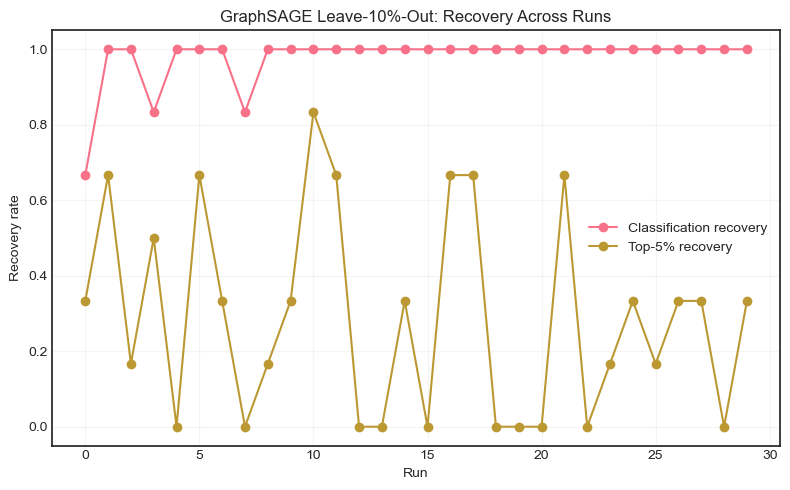

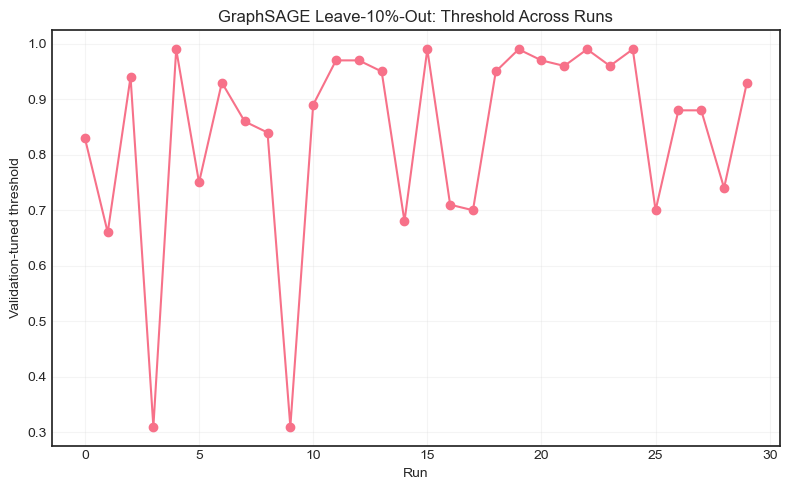

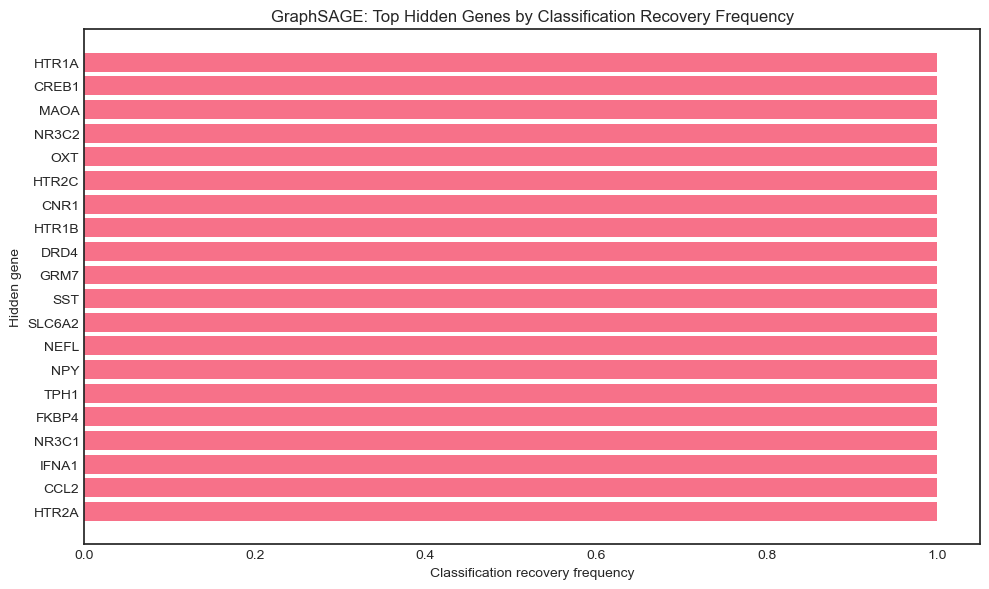

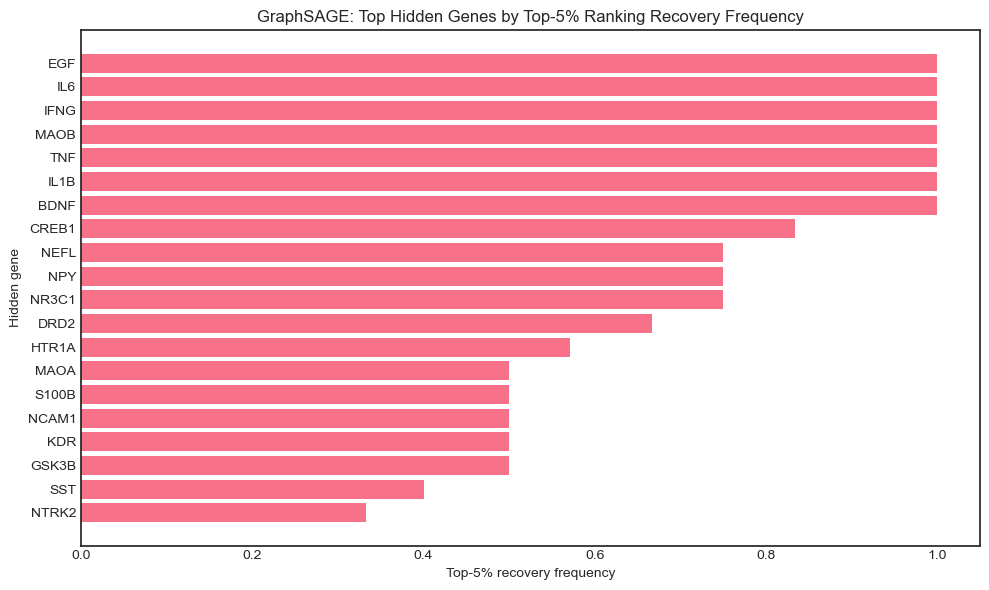


Saved:
- graphsage_leave10_classification_and_top5_recovery_results.csv
- graphsage_leave10_hidden_gene_classification_recovery_long.csv
- graphsage_leave10_hidden_gene_top5_recovery_long.csv
- graphsage_leave10_hidden_gene_classification_recovery_summary.csv
- graphsage_leave10_hidden_gene_top5_recovery_summary.csv
- graphsage_leave10_negative_gene_sets.csv
- graphsage_leave10_scored_run0.csv

Ready objects:
- G
- positive_genes
- negative_gene_sets_graphsage
- results_df
- hidden_gene_classification_df
- hidden_gene_top5_df
- gene_class_summary
- gene_top5_summary
- graphsage_models_per_run
- scored_tables_per_run


In [27]:
# # ============================================================
# # ONE-CELL PIPELINE:
# # Leave-10%-out positive classification recovery + top-5% ranking recovery
# # + negative selection + GraphSAGE
# #
# # GOAL
# # 1) Build the graph once
# # 2) For each run:
# #    - randomly hide 10% of known positives
# #    - NEVER allow hidden positives to become negatives
# #    - recompute positive-dependent features using TRAIN positives only
# #    - rebuild the negative pool using TRAIN positives only
# #    - sample negatives from eligible non-positive/non-hidden genes
# #    - build run-specific node features for all nodes
# #    - train GraphSAGE on train positives vs sampled negatives
# #    - tune a decision threshold on the validation set
# #    - evaluate hidden positives in two ways:
# #         (a) classification recovery: predicted positive or not
# #         (b) top-5% ranking recovery: ranked in top 5% or not
# #
# # MAIN METRICS
# # - classification_recovery_rate = (# hidden positives classified positive) / (# hidden positives)
# # - top5_recovery_rate           = (# hidden positives in top 5% ranked candidates) / (# hidden positives)
# # ============================================================

# import os
# import random
# import warnings
# warnings.filterwarnings("ignore")

# import numpy as np
# import pandas as pd
# import networkx as nx
# import matplotlib.pyplot as plt
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# from collections import deque
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics import (
#     roc_auc_score,
#     average_precision_score,
#     precision_recall_fscore_support
# )

# print("=== ONE-CELL: LEAVE-10%-OUT POSITIVE CLASSIFICATION + TOP-5% RANKING RECOVERY + NEGATIVE SELECTION + GraphSAGE ===")

# # =======================================================
# # 0) Reproducibility
# # =======================================================
# GLOBAL_SEED = 42
# os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
# random.seed(GLOBAL_SEED)
# np.random.seed(GLOBAL_SEED)
# torch.manual_seed(GLOBAL_SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(GLOBAL_SEED)

# FORCE_CPU = True
# DEVICE = torch.device("cpu") if FORCE_CPU else torch.device("cuda" if torch.cuda.is_available() else "cpu")

# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False
# try:
#     torch.use_deterministic_algorithms(True)
# except Exception:
#     pass

# # =======================================================
# # 1) Config
# # =======================================================
# EDGE_THRESHOLD = 0.6

# NEG_Q = 0.50
# EXCLUDE_DIST = 2

# N_RUNS = 30
# BASE_SEED = 42
# HOLDOUT_POS_FRAC = 0.10

# WEIGHTS = {
#     "ppr": 3.0,
#     "pos_w_ratio": 2.0,
#     "pos_w_sum": 1.5,
#     "pos_w_max": 1.0,
#     "prox": 1.5,
#     "hub_penalty": -1.0
# }
# PROX_ALPHA = 0.7

# VAL_FRAC = 0.20
# THRESH_GRID = np.linspace(0.01, 0.99, 99)

# # GraphSAGE
# N_EPOCHS = 200
# PATIENCE = 25
# LR = 0.01
# WEIGHT_DECAY = 1e-4
# HIDDEN = 32
# DROPOUT = 0.4
# INCLUDE_SELF_IN_MEAN = True

# # Ranking config
# TOP_FRACTION = 0.05
# EXCLUDE_SAMPLED_NEGATIVES_FROM_RANKING = False

# # =======================================================
# # 2) Preconditions
# # =======================================================
# if "interactions" not in globals():
#     raise RuntimeError("interactions not found.")
# if "filtered_result" not in globals():
#     raise RuntimeError("filtered_result not found.")

# # =======================================================
# # 3) Helpers
# # =======================================================
# def multi_source_bfs_distances(graph, sources):
#     dist = {n: np.inf for n in graph.nodes()}
#     q = deque()
#     for s in sources:
#         if s in graph:
#             dist[s] = 0
#             q.append(s)
#     while q:
#         u = q.popleft()
#         for v in graph.neighbors(u):
#             if dist[v] == np.inf:
#                 dist[v] = dist[u] + 1
#                 q.append(v)
#     return dist

# def sigmoid_np(x):
#     x = np.asarray(x, dtype=float)
#     return 1.0 / (1.0 + np.exp(-x))

# def safe_auc(y_true, y_score):
#     y_true = np.asarray(y_true).astype(int)
#     if len(np.unique(y_true)) < 2:
#         return np.nan
#     return float(roc_auc_score(y_true, y_score))

# def safe_ap(y_true, y_score):
#     y_true = np.asarray(y_true).astype(int)
#     if len(np.unique(y_true)) < 2:
#         return np.nan
#     return float(average_precision_score(y_true, y_score))

# def split_train_holdout_positives(pos_genes, holdout_frac, seed):
#     pos_genes = np.array(sorted(set(map(str, pos_genes))))
#     rng = np.random.RandomState(seed)
#     rng.shuffle(pos_genes)
#     n_holdout = max(1, int(np.round(holdout_frac * len(pos_genes))))
#     heldout = pos_genes[:n_holdout].tolist()
#     train_pos = pos_genes[n_holdout:].tolist()
#     return train_pos, heldout

# def make_train_val_masks(labeled_idx, y_labeled, n_nodes, split_seed=42, val_frac=0.2):
#     rng = np.random.RandomState(split_seed)
#     labeled_idx = np.asarray(labeled_idx)
#     y_labeled = np.asarray(y_labeled).astype(int)

#     pos = labeled_idx[y_labeled == 1]
#     neg = labeled_idx[y_labeled == 0]
#     rng.shuffle(pos)
#     rng.shuffle(neg)

#     def split_class(arr):
#         n = len(arr)
#         n_val = max(1, int(np.round(val_frac * n))) if n > 1 else 0
#         val = arr[:n_val]
#         train = arr[n_val:]
#         return train, val

#     pos_tr, pos_va = split_class(pos)
#     neg_tr, neg_va = split_class(neg)

#     train_idx = np.concatenate([pos_tr, neg_tr]) if len(pos_tr) + len(neg_tr) > 0 else np.array([], dtype=int)
#     val_idx = np.concatenate([pos_va, neg_va]) if len(pos_va) + len(neg_va) > 0 else np.array([], dtype=int)

#     rng.shuffle(train_idx)
#     rng.shuffle(val_idx)

#     train_mask = torch.zeros(n_nodes, dtype=torch.bool)
#     val_mask = torch.zeros(n_nodes, dtype=torch.bool)

#     if len(train_idx) > 0:
#         train_mask[torch.tensor(train_idx, dtype=torch.long)] = True
#     if len(val_idx) > 0:
#         val_mask[torch.tensor(val_idx, dtype=torch.long)] = True

#     return train_mask, val_mask

# def best_threshold_by_f1_from_mask(logits, y_all, mask_bool, thresholds=THRESH_GRID):
#     mask = mask_bool.detach().cpu().numpy().astype(bool)
#     y = y_all.detach().cpu().numpy()[mask].astype(int)
#     prob = sigmoid_np(logits.detach().cpu().numpy()[mask])

#     if len(y) == 0 or len(np.unique(y)) < 2:
#         return {"t": 0.5, "precision": np.nan, "recall": np.nan, "f1": np.nan}

#     best = {"t": 0.5, "precision": 0.0, "recall": 0.0, "f1": -1.0}
#     for t in thresholds:
#         yhat = (prob >= t).astype(int)
#         p, r, f1, _ = precision_recall_fscore_support(y, yhat, average="binary", zero_division=0)
#         if float(f1) > best["f1"]:
#             best = {
#                 "t": float(t),
#                 "precision": float(p),
#                 "recall": float(r),
#                 "f1": float(f1)
#             }
#     return best

# def evaluate_hidden_positive_classification_recovery(logits_np, node_to_idx, heldout_positive_genes, threshold):
#     rows = []
#     for g in map(str, heldout_positive_genes):
#         if g not in node_to_idx:
#             rows.append({
#                 "hidden_gene": g,
#                 "logit": np.nan,
#                 "prob": np.nan,
#                 "pred_positive": 0
#             })
#             continue

#         idx = node_to_idx[g]
#         logit = float(logits_np[idx])
#         prob = float(sigmoid_np([logit])[0])
#         pred_positive = int(prob >= threshold)

#         rows.append({
#             "hidden_gene": g,
#             "logit": logit,
#             "prob": prob,
#             "pred_positive": pred_positive
#         })

#     out_df = pd.DataFrame(rows)
#     n_hidden = int(len(out_df))
#     n_recovered = int(out_df["pred_positive"].sum()) if n_hidden > 0 else 0
#     recovery_rate = float(n_recovered / n_hidden) if n_hidden > 0 else np.nan

#     return {
#         "n_hidden": n_hidden,
#         "n_recovered": n_recovered,
#         "recovery_rate": recovery_rate,
#         "hidden_df": out_df
#     }

# def evaluate_hidden_top_fraction_recovery(
#     logits_np,
#     nodes,
#     node_to_idx,
#     train_positive_genes,
#     heldout_positive_genes,
#     sampled_negative_genes=None,
#     top_fraction=0.05,
#     exclude_sampled_negatives=False
# ):
#     train_pos_set = set(map(str, train_positive_genes))
#     neg_set = set(map(str, sampled_negative_genes)) if sampled_negative_genes is not None else set()

#     candidate_genes = [g for g in nodes if g not in train_pos_set]
#     if exclude_sampled_negatives:
#         candidate_genes = [g for g in candidate_genes if g not in neg_set]

#     candidate_probs = np.array(
#         [sigmoid_np([logits_np[node_to_idx[g]]])[0] for g in candidate_genes],
#         dtype=float
#     )

#     order = np.argsort(-candidate_probs)
#     ranked_genes = [candidate_genes[i] for i in order]
#     ranked_probs = candidate_probs[order]

#     rank_map = {g: i + 1 for i, g in enumerate(ranked_genes)}
#     prob_map = {g: float(ranked_probs[i]) for i, g in enumerate(ranked_genes)}

#     top_k = max(1, int(np.ceil(float(top_fraction) * len(ranked_genes))))

#     rows = []
#     for g in map(str, heldout_positive_genes):
#         if g not in rank_map:
#             rows.append({
#                 "hidden_gene": g,
#                 "prob": np.nan,
#                 "rank": np.nan,
#                 "in_top_fraction": 0
#             })
#             continue

#         rank_i = rank_map[g]
#         rows.append({
#             "hidden_gene": g,
#             "prob": prob_map[g],
#             "rank": rank_i,
#             "in_top_fraction": int(rank_i <= top_k)
#         })

#     hidden_df = pd.DataFrame(rows)
#     n_hidden = int(len(hidden_df))
#     n_recovered = int(hidden_df["in_top_fraction"].sum()) if n_hidden > 0 else 0
#     recovery_rate = float(n_recovered / n_hidden) if n_hidden > 0 else np.nan

#     return {
#         "n_hidden": n_hidden,
#         "n_recovered_topfrac": n_recovered,
#         "topfrac_recovery_rate": recovery_rate,
#         "top_fraction": float(top_fraction),
#         "top_k": int(top_k),
#         "candidate_count": int(len(ranked_genes)),
#         "hidden_df": hidden_df
#     }

# # =======================================================
# # 4) Build weighted graph ONCE
# # =======================================================
# high_conf_interactions = [(a, b, w) for a, b, w in interactions if w >= EDGE_THRESHOLD]

# G = nx.Graph()
# for a, b, w in high_conf_interactions:
#     G.add_edge(str(a), str(b), weight=float(w))

# print(f"Initial STRING graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# full_positive_genes = set(filtered_result["gene_symbol"].dropna().astype(str).unique())
# nx.set_node_attributes(G, {n: (1 if n in full_positive_genes else 0) for n in G.nodes()}, "positive")

# pos_in_graph_before = [n for n in G.nodes() if G.nodes[n].get("positive", 0) == 1]
# print(f"Positive genes in graph before component filtering: {len(pos_in_graph_before)}")

# positive_nodes_set = set(pos_in_graph_before)
# reachable_from_positive = set()
# for comp in nx.connected_components(G):
#     if comp & positive_nodes_set:
#         reachable_from_positive.update(comp)

# removed_nodes = set(G.nodes()) - reachable_from_positive
# G = G.subgraph(reachable_from_positive).copy()

# print(f"Removed {len(removed_nodes)} genes from components with no positive connection")
# print(f"Filtered graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# positive_genes = sorted([n for n in G.nodes() if n in full_positive_genes])
# print(f"Positive genes in filtered graph: {len(positive_genes)}")

# nodes = [str(n) for n in G.nodes()]
# node_to_idx = {n: i for i, n in enumerate(nodes)}
# N = len(nodes)

# # =======================================================
# # 5) Static structural features ONCE
# # =======================================================
# deg_cent = nx.degree_centrality(G)
# try:
#     btw_cent = nx.betweenness_centrality(G)
# except Exception:
#     btw_cent = {n: 0.0 for n in G.nodes()}
# try:
#     clo_cent = nx.closeness_centrality(G)
# except Exception:
#     clo_cent = {n: 0.0 for n in G.nodes()}
# clust = nx.clustering(G)
# deg = dict(G.degree())

# struct_rows = []
# for gene in nodes:
#     neighbors = list(G.neighbors(gene))
#     neighbor_degrees = [G.degree(n) for n in neighbors] if neighbors else []
#     neighbor_weights = [float(G[gene][n].get("weight", 1.0)) for n in neighbors] if neighbors else []

#     struct_rows.append({
#         "gene": gene,
#         "degree": G.degree(gene),
#         "clustering_coefficient": float(clust.get(gene, 0.0)),
#         "neighbor_count": len(neighbors),
#         "avg_neighbor_degree": float(np.mean(neighbor_degrees)) if neighbors else 0.0,
#         "max_neighbor_degree": float(np.max(neighbor_degrees)) if neighbors else 0.0,
#         "avg_edge_weight": float(np.mean(neighbor_weights)) if neighbors else 0.0,
#         "max_edge_weight": float(np.max(neighbor_weights)) if neighbors else 0.0,
#         "degree_centrality": float(deg_cent.get(gene, 0.0)),
#         "betweenness_centrality": float(btw_cent.get(gene, 0.0)),
#         "closeness_centrality": float(clo_cent.get(gene, 0.0)),
#     })

# struct_df = pd.DataFrame(struct_rows).set_index("gene").fillna(0).replace([np.inf, -np.inf], 0)

# # =======================================================
# # 6) Run-specific scoring / negative selection
# # =======================================================
# def build_run_scored_table(graph, nodes, train_positive_genes):
#     eps = 1e-9
#     train_positive_genes = [str(g) for g in train_positive_genes if str(g) in graph]

#     if len(train_positive_genes) > 0:
#         dist_to_pos = multi_source_bfs_distances(graph, train_positive_genes)
#         personalization = {n: (1.0 if n in train_positive_genes else 0.0) for n in graph.nodes()}
#         ppr = nx.pagerank(graph, alpha=0.85, personalization=personalization, weight="weight")
#     else:
#         dist_to_pos = {n: np.inf for n in graph.nodes()}
#         ppr = {n: 0.0 for n in graph.nodes()}

#     train_pos_set = set(train_positive_genes)
#     rows = []

#     for node in nodes:
#         neighbors = list(graph.neighbors(node))
#         pos_neighbors = [n for n in neighbors if n in train_pos_set]
#         pos_edges = [graph[node][p]["weight"] for p in pos_neighbors]

#         pos_w_sum = float(np.sum(pos_edges)) if pos_edges else 0.0
#         pos_w_max = float(np.max(pos_edges)) if pos_edges else 0.0
#         pos_w_mean = float(np.mean(pos_edges)) if pos_edges else 0.0
#         pos_neighbor_count = len(pos_neighbors)

#         total_w = float(np.sum([graph[node][nbr]["weight"] for nbr in neighbors])) if neighbors else 0.0
#         pos_w_ratio = pos_w_sum / (total_w + eps)

#         d = dist_to_pos.get(node, np.inf)
#         prox = 0.0 if np.isinf(d) else float(np.exp(-PROX_ALPHA * d))
#         hub_penalty = float(np.log1p(deg.get(node, 0)))

#         rows.append({
#             "gene": node,
#             "is_train_positive": int(node in train_pos_set),
#             "pos_neighbor_count": pos_neighbor_count,
#             "pos_w_sum": pos_w_sum,
#             "pos_w_max": pos_w_max,
#             "pos_w_mean": pos_w_mean,
#             "pos_w_ratio": pos_w_ratio,
#             "distance_to_positive": float(d) if not np.isinf(d) else np.inf,
#             "prox": prox,
#             "ppr": float(ppr.get(node, 0.0)),
#             "hub_penalty": hub_penalty
#         })

#     scored_run = pd.DataFrame(rows)

#     score_features = ["ppr", "pos_w_ratio", "pos_w_sum", "pos_w_max", "prox", "hub_penalty"]

#     if np.isinf(scored_run["distance_to_positive"]).any():
#         reachable = scored_run.loc[~np.isinf(scored_run["distance_to_positive"]), "distance_to_positive"]
#         worst = float(reachable.max()) + 1 if len(reachable) else 1.0
#         scored_run["distance_to_positive"] = scored_run["distance_to_positive"].replace(np.inf, worst)

#     scaler = MinMaxScaler()
#     scored_run[score_features] = scaler.fit_transform(scored_run[score_features])

#     scored_run["final_score"] = 0.0
#     for f, w in WEIGHTS.items():
#         scored_run["final_score"] += scored_run[f] * float(w)

#     scored_run["final_score_01"] = MinMaxScaler().fit_transform(scored_run[["final_score"]])
#     return scored_run

# def sample_negatives_for_run(scored_run, train_positive_genes, heldout_positive_genes, seed):
#     train_pos_set = set(map(str, train_positive_genes))
#     heldout_set = set(map(str, heldout_positive_genes))

#     nonpos = scored_run[
#         (~scored_run["gene"].astype(str).isin(train_pos_set)) &
#         (~scored_run["gene"].astype(str).isin(heldout_set))
#     ].copy()

#     cutoff = nonpos["final_score"].quantile(NEG_Q)
#     eligible = nonpos[nonpos["final_score"] <= cutoff].copy()

#     if EXCLUDE_DIST is not None and EXCLUDE_DIST > 0:
#         eligible = eligible[eligible["distance_to_positive"] > EXCLUDE_DIST]

#     eligible_genes = sorted(eligible["gene"].astype(str).tolist())

#     k_target = len(train_positive_genes)
#     k = min(k_target, len(eligible_genes))

#     rng = random.Random(seed)
#     neg_genes = rng.sample(eligible_genes, k=k) if k > 0 else []

#     return neg_genes, eligible_genes, cutoff, k

# def build_run_node_feature_df(scored_run):
#     run_lookup = scored_run.copy().assign(gene=lambda d: d["gene"].astype(str)).set_index("gene")

#     feature_df = struct_df.copy()
#     merge_cols = [
#         "ppr",
#         "pos_w_ratio",
#         "pos_w_sum",
#         "pos_w_max",
#         "pos_neighbor_count",
#         "distance_to_positive",
#         "prox",
#         "hub_penalty"
#     ]

#     common = feature_df.index.intersection(run_lookup.index)
#     for c in merge_cols:
#         if c in run_lookup.columns:
#             feature_df.loc[common, c] = run_lookup.loc[common, c]

#     feature_df = feature_df.fillna(0).replace([np.inf, -np.inf], 0)
#     return feature_df.reset_index().rename(columns={"index": "gene"})

# def build_run_tensors(full_feature_df, train_pos_genes, neg_genes, node_to_idx):
#     feature_cols = [c for c in full_feature_df.columns if c != "gene"]

#     X_df = full_feature_df.set_index("gene").loc[nodes, feature_cols].copy()
#     X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
#     X_t = torch.tensor(X_df.values, dtype=torch.float32, device=DEVICE)

#     y = torch.full((N,), -1, dtype=torch.long)
#     pos_set = set(map(str, train_pos_genes))
#     neg_set = set(map(str, neg_genes))

#     labeled_idx = []
#     y_labeled = []

#     for g in pos_set:
#         if g in node_to_idx:
#             idx = node_to_idx[g]
#             y[idx] = 1
#             labeled_idx.append(idx)
#             y_labeled.append(1)

#     for g in neg_set:
#         if g in node_to_idx:
#             idx = node_to_idx[g]
#             y[idx] = 0
#             labeled_idx.append(idx)
#             y_labeled.append(0)

#     return X_t, feature_cols, y.to(DEVICE), np.array(labeled_idx, dtype=int), np.array(y_labeled, dtype=int)

# # =======================================================
# # 7) Graph tensors and GraphSAGE
# # =======================================================
# edges = []
# for u, v in G.edges():
#     ui = node_to_idx[str(u)]
#     vi = node_to_idx[str(v)]
#     edges.append((ui, vi))
#     edges.append((vi, ui))

# edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# def row_norm_adj(edge_index, num_nodes, include_self=True, device=None):
#     if device is None:
#         device = edge_index.device

#     idx = edge_index.to(device)
#     vals = torch.ones(idx.size(1), dtype=torch.float32, device=device)

#     if include_self:
#         self_loops = torch.arange(num_nodes, device=device)
#         self_idx = torch.stack([self_loops, self_loops], dim=0)
#         idx = torch.cat([idx, self_idx], dim=1)
#         vals = torch.cat([vals, torch.ones(num_nodes, dtype=torch.float32, device=device)], dim=0)

#     A = torch.sparse_coo_tensor(idx, vals, (num_nodes, num_nodes)).coalesce()
#     degv = torch.sparse.sum(A, dim=1).to_dense()
#     deg_inv = torch.pow(degv.clamp(min=1e-12), -1.0)

#     row, col = A.indices()
#     v = A.values() * deg_inv[row]
#     A_mean = torch.sparse_coo_tensor(A.indices(), v, A.size()).coalesce()
#     return A_mean

# A_mean = row_norm_adj(edge_index.to(DEVICE), N, include_self=INCLUDE_SELF_IN_MEAN, device=DEVICE)

# class GraphSAGELayer(nn.Module):
#     def __init__(self, in_dim, out_dim):
#         super().__init__()
#         self.lin_self = nn.Linear(in_dim, out_dim, bias=True)
#         self.lin_neigh = nn.Linear(in_dim, out_dim, bias=True)

#     def forward(self, x, A_mean):
#         neigh = torch.sparse.mm(A_mean, x)
#         out = self.lin_self(x) + self.lin_neigh(neigh)
#         return out

# class GraphSAGE(nn.Module):
#     def __init__(self, in_dim, hid_dim, dropout=0.4):
#         super().__init__()
#         self.sage1 = GraphSAGELayer(in_dim, hid_dim)
#         self.sage2 = GraphSAGELayer(hid_dim, 1)
#         self.dropout = dropout

#     def forward(self, X, A_mean):
#         h = self.sage1(X, A_mean)
#         h = F.relu(h)
#         h = F.dropout(h, p=self.dropout, training=self.training)
#         out = self.sage2(h, A_mean).squeeze(-1)
#         return out

# # =======================================================
# # 8) Run the pipeline
# # =======================================================
# all_rows = []
# graphsage_models_per_run = []
# negative_gene_sets_graphsage = []
# scored_tables_per_run = []

# hidden_gene_classification_rows = []
# hidden_gene_top5_rows = []

# for run_id in range(N_RUNS):
#     run_seed = BASE_SEED + run_id
#     random.seed(run_seed)
#     np.random.seed(run_seed)
#     torch.manual_seed(run_seed)
#     if torch.cuda.is_available():
#         torch.cuda.manual_seed_all(run_seed)

#     train_positive_genes, heldout_positive_genes = split_train_holdout_positives(
#         positive_genes,
#         holdout_frac=HOLDOUT_POS_FRAC,
#         seed=run_seed
#     )

#     scored_run = build_run_scored_table(G, nodes, train_positive_genes)

#     neg_genes, eligible_genes, cutoff, k = sample_negatives_for_run(
#         scored_run=scored_run,
#         train_positive_genes=train_positive_genes,
#         heldout_positive_genes=heldout_positive_genes,
#         seed=run_seed
#     )
#     negative_gene_sets_graphsage.append(neg_genes)

#     full_feature_df = build_run_node_feature_df(scored_run)

#     X_t, feature_cols, y_all, labeled_idx, y_labeled = build_run_tensors(
#         full_feature_df=full_feature_df,
#         train_pos_genes=train_positive_genes,
#         neg_genes=neg_genes,
#         node_to_idx=node_to_idx
#     )

#     train_mask, val_mask = make_train_val_masks(
#         labeled_idx=labeled_idx,
#         y_labeled=y_labeled,
#         n_nodes=N,
#         split_seed=run_seed,
#         val_frac=VAL_FRAC
#     )
#     train_mask = train_mask.to(DEVICE)
#     val_mask = val_mask.to(DEVICE)

#     y_train_np = y_all[train_mask].detach().cpu().numpy()
#     n_pos = int((y_train_np == 1).sum())
#     n_neg = int((y_train_np == 0).sum())
#     pos_weight = float(n_neg / max(1, n_pos))

#     model = GraphSAGE(
#         in_dim=X_t.shape[1],
#         hid_dim=HIDDEN,
#         dropout=DROPOUT
#     ).to(DEVICE)

#     opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
#     loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, device=DEVICE))

#     best_val_auc = -np.inf
#     best_state = None
#     best_epoch = 0
#     bad = 0

#     print(
#         f"[RUN {run_id:02d}] "
#         f"train_pos={len(train_positive_genes)} | hidden_pos={len(heldout_positive_genes)} | "
#         f"eligible_neg={len(eligible_genes)} | sampled_neg={len(neg_genes)} | "
#         f"feature_dim={X_t.shape[1]}"
#     )

#     for epoch in range(1, N_EPOCHS + 1):
#         model.train()
#         opt.zero_grad()

#         logits = model(X_t, A_mean)
#         loss = loss_fn(logits[train_mask], y_all[train_mask].float())
#         loss.backward()
#         opt.step()

#         model.eval()
#         with torch.no_grad():
#             logits_eval = model(X_t, A_mean)

#         y_val = y_all[val_mask].detach().cpu().numpy().astype(int)
#         val_prob = sigmoid_np(logits_eval[val_mask].detach().cpu().numpy())
#         val_auc = safe_auc(y_val, val_prob)

#         improved = (not np.isnan(val_auc)) and (val_auc > best_val_auc + 1e-6)
#         if improved:
#             best_val_auc = val_auc
#             best_state = {k_: v.detach().cpu().clone() for k_, v in model.state_dict().items()}
#             best_epoch = epoch
#             bad = 0
#         else:
#             bad += 1

#         if epoch == 1 or epoch % 25 == 0:
#             bt_tmp = best_threshold_by_f1_from_mask(logits_eval, y_all, val_mask, thresholds=THRESH_GRID)
#             val_f1 = 0.0 if np.isnan(bt_tmp["f1"]) else bt_tmp["f1"]
#             print(
#                 f"    epoch={epoch:03d} "
#                 f"loss={loss.item():.4f} "
#                 f"val_auc={0.0 if np.isnan(val_auc) else val_auc:.3f} "
#                 f"val_f1~{val_f1:.3f}"
#             )

#         if bad >= PATIENCE:
#             break

#     if best_state is not None:
#         model.load_state_dict(best_state)

#     model.eval()
#     with torch.no_grad():
#         logits_final = model(X_t, A_mean)

#     bt = best_threshold_by_f1_from_mask(logits_final, y_all, val_mask, thresholds=THRESH_GRID)
#     t_star = bt["t"]

#     logits_np = logits_final.detach().cpu().numpy()

#     class_recovery = evaluate_hidden_positive_classification_recovery(
#         logits_np=logits_np,
#         node_to_idx=node_to_idx,
#         heldout_positive_genes=heldout_positive_genes,
#         threshold=t_star
#     )

#     top5_recovery = evaluate_hidden_top_fraction_recovery(
#         logits_np=logits_np,
#         nodes=nodes,
#         node_to_idx=node_to_idx,
#         train_positive_genes=train_positive_genes,
#         heldout_positive_genes=heldout_positive_genes,
#         sampled_negative_genes=neg_genes,
#         top_fraction=TOP_FRACTION,
#         exclude_sampled_negatives=EXCLUDE_SAMPLED_NEGATIVES_FROM_RANKING
#     )

#     val_prob = sigmoid_np(logits_np[val_mask.detach().cpu().numpy().astype(bool)])
#     y_val_final = y_all[val_mask].detach().cpu().numpy().astype(int)
#     val_auc_final = safe_auc(y_val_final, val_prob)
#     val_ap_final = safe_ap(y_val_final, val_prob)

#     print(
#         f"RUN {run_id:02d} | best_epoch={best_epoch} | "
#         f"VAL AUC {0.0 if np.isnan(val_auc_final) else val_auc_final:.3f} AP {0.0 if np.isnan(val_ap_final) else val_ap_final:.3f} | "
#         f"threshold={t_star:.2f} | "
#         f"classif_recovered={class_recovery['n_recovered']}/{class_recovery['n_hidden']} ({class_recovery['recovery_rate']:.3f}) | "
#         f"top5_recovered={top5_recovery['n_recovered_topfrac']}/{top5_recovery['n_hidden']} ({top5_recovery['topfrac_recovery_rate']:.3f}) | "
#         f"top5_cutoff={top5_recovery['top_k']}"
#     )

#     row = {
#         "run": run_id,
#         "model": "GraphSAGE_leave_10pct_out_classification_and_top5_recovery",
#         "train_pos_total": int(len(train_positive_genes)),
#         "hidden_pos_total": int(len(heldout_positive_genes)),
#         "eligible_neg_total": int(len(eligible_genes)),
#         "sampled_neg_total": int(len(neg_genes)),
#         "neg_cutoff": float(cutoff),
#         "labeled_total": int(len(labeled_idx)),
#         "train_pos_used": int(n_pos),
#         "train_neg_used": int(n_neg),
#         "pos_weight": float(pos_weight),
#         "best_epoch": int(best_epoch),
#         "feature_dim": int(X_t.shape[1]),
#         "val_auc": float(val_auc_final) if not np.isnan(val_auc_final) else np.nan,
#         "val_ap": float(val_ap_final) if not np.isnan(val_ap_final) else np.nan,
#         "threshold": float(t_star),
#         "val_thr_precision": float(bt["precision"]) if not np.isnan(bt["precision"]) else np.nan,
#         "val_thr_recall": float(bt["recall"]) if not np.isnan(bt["recall"]) else np.nan,
#         "val_thr_f1": float(bt["f1"]) if not np.isnan(bt["f1"]) else np.nan,
#         "n_hidden": int(class_recovery["n_hidden"]),
#         "n_recovered_classification": int(class_recovery["n_recovered"]),
#         "classification_recovery_rate": float(class_recovery["recovery_rate"]),
#         "candidate_count": int(top5_recovery["candidate_count"]),
#         "top5_cutoff": int(top5_recovery["top_k"]),
#         "n_recovered_top5": int(top5_recovery["n_recovered_topfrac"]),
#         "top5_recovery_rate": float(top5_recovery["topfrac_recovery_rate"]),
#         "include_self_in_mean": bool(INCLUDE_SELF_IN_MEAN),
#     }
#     all_rows.append(row)

#     class_hidden_df = class_recovery["hidden_df"].copy()
#     class_hidden_df["run"] = run_id
#     class_hidden_df["threshold"] = t_star
#     hidden_gene_classification_rows.append(class_hidden_df)

#     top5_hidden_df = top5_recovery["hidden_df"].copy()
#     top5_hidden_df["run"] = run_id
#     top5_hidden_df["top5_cutoff"] = top5_recovery["top_k"]
#     top5_hidden_df["candidate_count"] = top5_recovery["candidate_count"]
#     hidden_gene_top5_rows.append(top5_hidden_df)

#     scored_tables_per_run.append(scored_run.copy())

#     graphsage_models_per_run.append({
#         "run_id": run_id,
#         "model_name": "GraphSAGE_leave_10pct_out_classification_and_top5_recovery",
#         "model": model,
#         "feature_cols": feature_cols,
#         "node_to_idx": node_to_idx,
#         "device": str(DEVICE),
#         "threshold": float(t_star),
#         "top_fraction": float(TOP_FRACTION),
#         "include_self_in_mean": bool(INCLUDE_SELF_IN_MEAN),
#         "train_positive_genes_list": list(map(str, train_positive_genes)),
#         "heldout_positive_genes_list": list(map(str, heldout_positive_genes)),
#         "negative_genes_list": list(map(str, neg_genes)),
#         "recovered_hidden_genes_classification": class_hidden_df.loc[class_hidden_df["pred_positive"] == 1, "hidden_gene"].tolist(),
#         "missed_hidden_genes_classification": class_hidden_df.loc[class_hidden_df["pred_positive"] == 0, "hidden_gene"].tolist(),
#         "recovered_hidden_genes_top5": top5_hidden_df.loc[top5_hidden_df["in_top_fraction"] == 1, "hidden_gene"].tolist(),
#         "missed_hidden_genes_top5": top5_hidden_df.loc[top5_hidden_df["in_top_fraction"] == 0, "hidden_gene"].tolist(),
#     })

# results_df = pd.DataFrame(all_rows)
# hidden_gene_classification_df = pd.concat(hidden_gene_classification_rows, axis=0, ignore_index=True)
# hidden_gene_top5_df = pd.concat(hidden_gene_top5_rows, axis=0, ignore_index=True)

# # =======================================================
# # 9) Summaries
# # =======================================================
# print("\n=== SUMMARY: RUN-LEVEL RECOVERY (GraphSAGE) ===")
# summary_cols = [
#     "classification_recovery_rate",
#     "n_recovered_classification",
#     "n_hidden",
#     "top5_recovery_rate",
#     "n_recovered_top5",
#     "candidate_count",
#     "top5_cutoff",
#     "val_auc",
#     "val_ap",
#     "threshold",
#     "val_thr_precision",
#     "val_thr_recall",
#     "val_thr_f1"
# ]
# print(results_df[summary_cols].agg(["mean", "std", "min", "max"]).round(4).to_string())

# print("\n=== SUMMARY: GENE-LEVEL CLASSIFICATION RECOVERY FREQUENCY (GraphSAGE) ===")
# gene_class_summary = (
#     hidden_gene_classification_df
#     .groupby("hidden_gene", as_index=False)
#     .agg(
#         times_hidden=("hidden_gene", "size"),
#         times_recovered=("pred_positive", "sum"),
#         recovery_rate=("pred_positive", "mean"),
#         median_prob=("prob", "median"),
#         mean_prob=("prob", "mean"),
#     )
#     .sort_values(["recovery_rate", "times_recovered", "mean_prob"], ascending=[False, False, False])
# )
# print(gene_class_summary.head(20).round(4).to_string(index=False))

# print("\n=== SUMMARY: GENE-LEVEL TOP-5% RANKING RECOVERY FREQUENCY (GraphSAGE) ===")
# gene_top5_summary = (
#     hidden_gene_top5_df
#     .groupby("hidden_gene", as_index=False)
#     .agg(
#         times_hidden=("hidden_gene", "size"),
#         times_recovered_top5=("in_top_fraction", "sum"),
#         top5_recovery_rate=("in_top_fraction", "mean"),
#         median_rank=("rank", "median"),
#         mean_rank=("rank", "mean"),
#         median_prob=("prob", "median"),
#         mean_prob=("prob", "mean"),
#     )
#     .sort_values(["top5_recovery_rate", "times_recovered_top5", "mean_prob"], ascending=[False, False, False])
# )
# print(gene_top5_summary.head(20).round(4).to_string(index=False))

# overall_class_recovery = hidden_gene_classification_df["pred_positive"].mean()
# overall_top5_recovery = hidden_gene_top5_df["in_top_fraction"].mean()

# print(f"\nOverall hidden-gene classification recovery rate across all hidden instances: {overall_class_recovery:.4f}")
# print(f"Overall hidden-gene top-5% ranking recovery rate across all hidden instances: {overall_top5_recovery:.4f}")

# # =======================================================
# # 10) Plots
# # =======================================================
# plt.figure(figsize=(8, 5))
# plt.plot(results_df["run"], results_df["classification_recovery_rate"], marker="o", label="Classification recovery")
# plt.plot(results_df["run"], results_df["top5_recovery_rate"], marker="o", label="Top-5% recovery")
# plt.xlabel("Run")
# plt.ylabel("Recovery rate")
# plt.title("GraphSAGE Leave-10%-Out: Recovery Across Runs")
# plt.legend()
# plt.grid(alpha=0.2)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.plot(results_df["run"], results_df["threshold"], marker="o")
# plt.xlabel("Run")
# plt.ylabel("Validation-tuned threshold")
# plt.title("GraphSAGE Leave-10%-Out: Threshold Across Runs")
# plt.grid(alpha=0.2)
# plt.tight_layout()
# plt.show()

# top_genes_class = gene_class_summary.head(20).copy()
# plt.figure(figsize=(10, 6))
# plt.barh(top_genes_class["hidden_gene"][::-1], top_genes_class["recovery_rate"][::-1])
# plt.xlabel("Classification recovery frequency")
# plt.ylabel("Hidden gene")
# plt.title("GraphSAGE: Top Hidden Genes by Classification Recovery Frequency")
# plt.tight_layout()
# plt.show()

# top_genes_top5 = gene_top5_summary.head(20).copy()
# plt.figure(figsize=(10, 6))
# plt.barh(top_genes_top5["hidden_gene"][::-1], top_genes_top5["top5_recovery_rate"][::-1])
# plt.xlabel("Top-5% recovery frequency")
# plt.ylabel("Hidden gene")
# plt.title("GraphSAGE: Top Hidden Genes by Top-5% Ranking Recovery Frequency")
# plt.tight_layout()
# plt.show()

# # =======================================================
# # 11) Save
# # =======================================================
# results_df.to_csv("graphsage_leave10_classification_and_top5_recovery_results.csv", index=False)
# hidden_gene_classification_df.to_csv("graphsage_leave10_hidden_gene_classification_recovery_long.csv", index=False)
# hidden_gene_top5_df.to_csv("graphsage_leave10_hidden_gene_top5_recovery_long.csv", index=False)
# gene_class_summary.to_csv("graphsage_leave10_hidden_gene_classification_recovery_summary.csv", index=False)
# gene_top5_summary.to_csv("graphsage_leave10_hidden_gene_top5_recovery_summary.csv", index=False)

# neg_long = []
# for i, negs in enumerate(negative_gene_sets_graphsage):
#     seed_i = BASE_SEED + i
#     for g in negs:
#         neg_long.append({"run": i, "seed": seed_i, "gene": g})
# pd.DataFrame(neg_long).to_csv("graphsage_leave10_negative_gene_sets.csv", index=False)

# if len(scored_tables_per_run) > 0:
#     scored_tables_per_run[0].to_csv("graphsage_leave10_scored_run0.csv", index=False)

# print("\nSaved:")
# print("- graphsage_leave10_classification_and_top5_recovery_results.csv")
# print("- graphsage_leave10_hidden_gene_classification_recovery_long.csv")
# print("- graphsage_leave10_hidden_gene_top5_recovery_long.csv")
# print("- graphsage_leave10_hidden_gene_classification_recovery_summary.csv")
# print("- graphsage_leave10_hidden_gene_top5_recovery_summary.csv")
# print("- graphsage_leave10_negative_gene_sets.csv")
# print("- graphsage_leave10_scored_run0.csv")

# print("\nReady objects:")
# print("- G")
# print("- positive_genes")
# print("- negative_gene_sets_graphsage")
# print("- results_df")
# print("- hidden_gene_classification_df")
# print("- hidden_gene_top5_df")
# print("- gene_class_summary")
# print("- gene_top5_summary")
# print("- graphsage_models_per_run")
# print("- scored_tables_per_run")

=== ONE-CELL: LEAVE-10%-OUT POSITIVE PERCENTILE RANKING RECOVERY + NEGATIVE SELECTION + GraphSAGE ===
Percentile definition: 100 = best rank, 0 = worst rank
Initial STRING graph: 1020 nodes, 4198 edges
Positive genes in graph before component filtering: 60
Removed 86 genes from components with no positive connection
Filtered graph: 934 nodes, 4150 edges
Positive genes in filtered graph: 60
[RUN 00] train_pos=54 | hidden_pos=6 | eligible_neg=221 | sampled_neg=54 | feature_dim=18
    epoch=001 loss=1.0902 val_auc=1.000 val_ap=1.000
    epoch=025 loss=0.0829 val_auc=1.000 val_ap=1.000
RUN 00 | best_epoch=1 | VAL AUC 1.000 AP 1.000 | candidate_count=880 | mean_hidden_percentile=70.88 | median_hidden_percentile=72.24
[RUN 01] train_pos=54 | hidden_pos=6 | eligible_neg=228 | sampled_neg=54 | feature_dim=18
    epoch=001 loss=0.9444 val_auc=0.983 val_ap=0.986
    epoch=025 loss=0.0051 val_auc=1.000 val_ap=1.000
RUN 01 | best_epoch=2 | VAL AUC 1.000 AP 1.000 | candidate_count=880 | mean_hidden

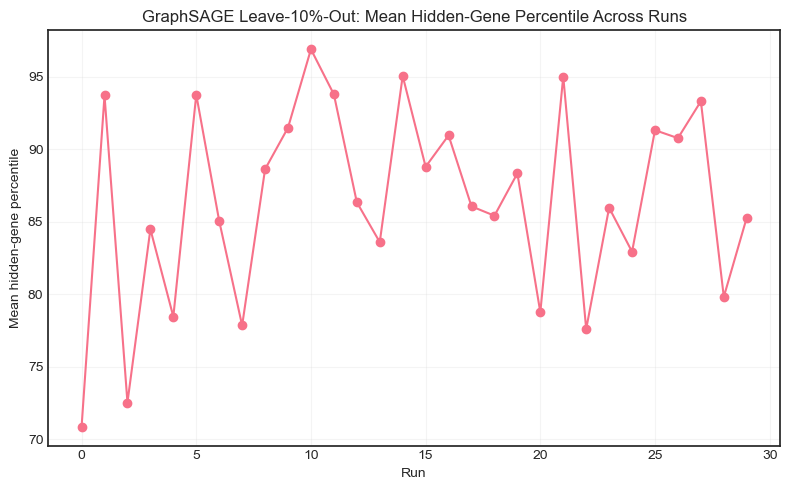

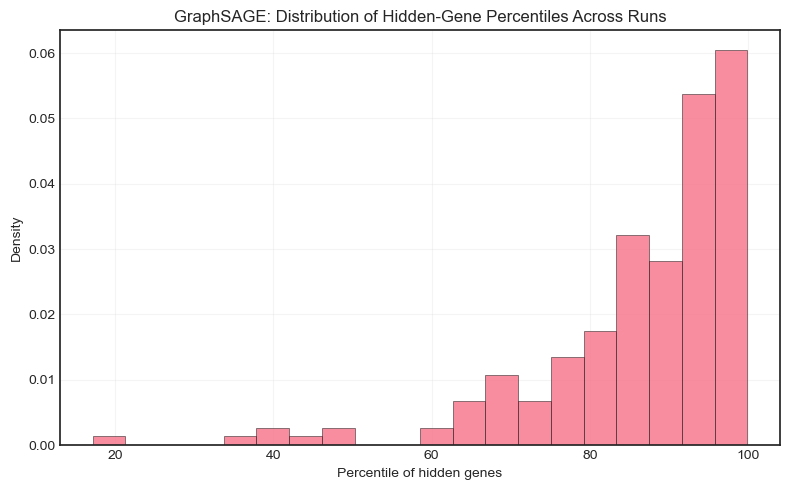

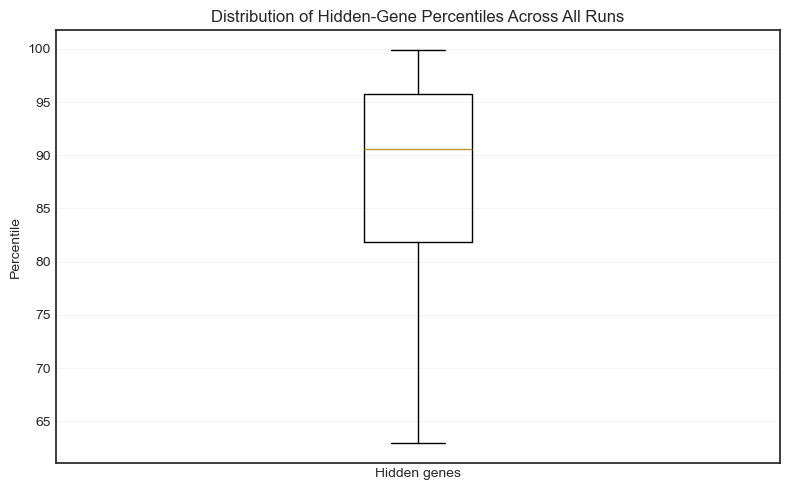

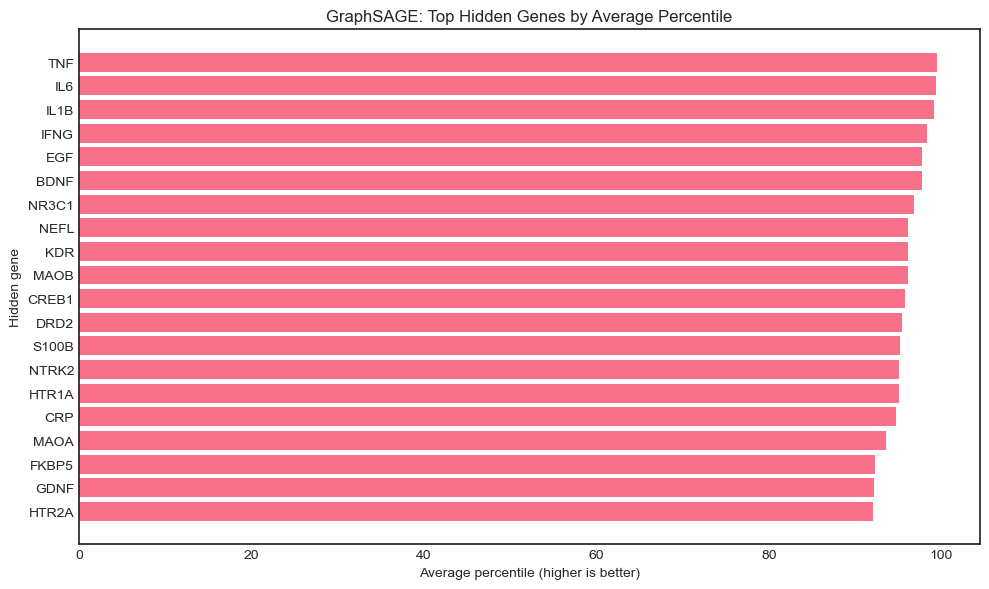

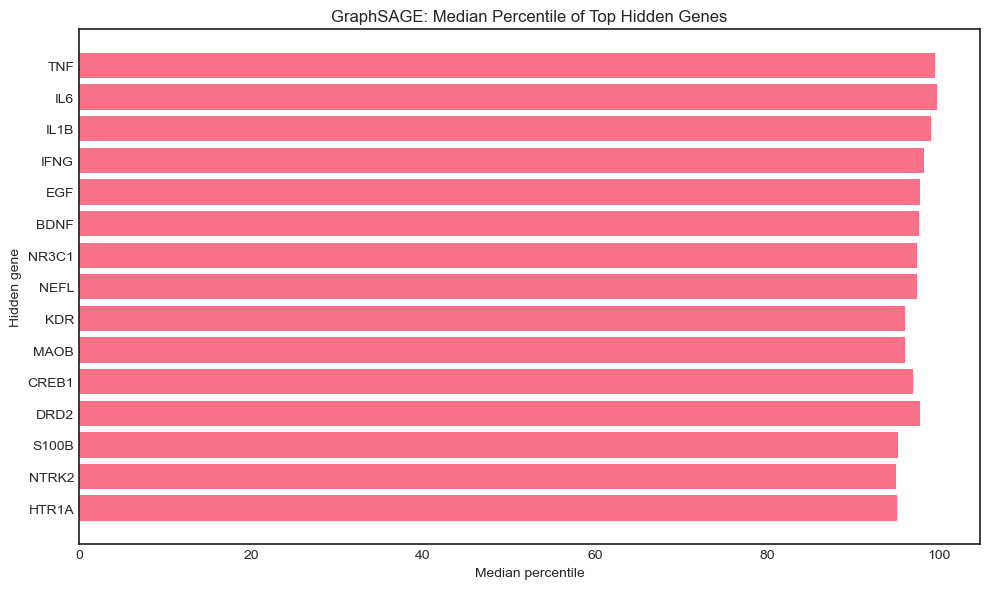


Saved:
- graphsage_leave10_percentile_results.csv
- graphsage_leave10_hidden_gene_percentile_long.csv
- graphsage_leave10_hidden_gene_percentile_summary.csv
- graphsage_leave10_hidden_gene_percentiles_by_run.csv
- graphsage_leave10_negative_gene_sets.csv
- graphsage_leave10_scored_run0.csv

Ready objects:
- G
- positive_genes
- negative_gene_sets_graphsage
- results_df
- hidden_gene_percentile_df
- gene_percentile_summary
- per_gene_per_run_percentiles
- graphsage_models_per_run
- scored_tables_per_run


In [29]:
# # ============================================================
# # ONE-CELL PIPELINE:
# # Leave-10%-out positive percentile ranking recovery
# # + negative selection + GraphSAGE
# #
# # GOAL
# # 1) Build the graph once
# # 2) For each run:
# #    - randomly hide 10% of known positives
# #    - never allow hidden positives to become negatives
# #    - recompute positive-dependent features using TRAIN positives only
# #    - rebuild the negative pool using TRAIN positives only
# #    - sample negatives from eligible non-positive/non-hidden genes
# #    - build run-specific node features for all nodes
# #    - train GraphSAGE on train positives vs sampled negatives
# #    - monitor validation AUC/AP for early stopping
# #    - rank candidate genes by predicted score
# #    - evaluate hidden positives by percentile position among candidates
# #
# # MAIN METRICS
# # - hidden_percentile: percentile rank of each hidden gene among ranked candidates
# #                      (higher is better; 100 = best-ranked candidate)
# # - mean_hidden_percentile per run
# # - median_hidden_percentile per run
# # ============================================================

# import os
# import random
# import warnings
# warnings.filterwarnings("ignore")

# import numpy as np
# import pandas as pd
# import networkx as nx
# import matplotlib.pyplot as plt
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# from collections import deque
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics import (
#     roc_auc_score,
#     average_precision_score,
# )

# print("=== ONE-CELL: LEAVE-10%-OUT POSITIVE PERCENTILE RANKING RECOVERY + NEGATIVE SELECTION + GraphSAGE ===")
# print("Percentile definition: 100 = best rank, 0 = worst rank")

# # =======================================================
# # 0) Reproducibility
# # =======================================================
# GLOBAL_SEED = 42
# os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
# random.seed(GLOBAL_SEED)
# np.random.seed(GLOBAL_SEED)
# torch.manual_seed(GLOBAL_SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(GLOBAL_SEED)

# FORCE_CPU = True
# DEVICE = torch.device("cpu") if FORCE_CPU else torch.device("cuda" if torch.cuda.is_available() else "cpu")

# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False
# try:
#     torch.use_deterministic_algorithms(True)
# except Exception:
#     pass

# # =======================================================
# # 1) Config
# # =======================================================
# EDGE_THRESHOLD = 0.6

# NEG_Q = 0.50
# EXCLUDE_DIST = 2

# N_RUNS = 30
# BASE_SEED = 42
# HOLDOUT_POS_FRAC = 0.10

# WEIGHTS = {
#     "ppr": 3.0,
#     "pos_w_ratio": 2.0,
#     "pos_w_sum": 1.5,
#     "pos_w_max": 1.0,
#     "prox": 1.5,
#     "hub_penalty": -1.0
# }
# PROX_ALPHA = 0.7

# VAL_FRAC = 0.20

# # GraphSAGE
# N_EPOCHS = 200
# PATIENCE = 25
# LR = 0.01
# WEIGHT_DECAY = 1e-4
# HIDDEN = 32
# DROPOUT = 0.4
# INCLUDE_SELF_IN_MEAN = True

# EXCLUDE_SAMPLED_NEGATIVES_FROM_RANKING = False

# # =======================================================
# # 2) Preconditions
# # =======================================================
# if "interactions" not in globals():
#     raise RuntimeError("interactions not found.")
# if "filtered_result" not in globals():
#     raise RuntimeError("filtered_result not found.")

# # =======================================================
# # 3) Helpers
# # =======================================================
# def multi_source_bfs_distances(graph, sources):
#     dist = {n: np.inf for n in graph.nodes()}
#     q = deque()
#     for s in sources:
#         if s in graph:
#             dist[s] = 0
#             q.append(s)
#     while q:
#         u = q.popleft()
#         for v in graph.neighbors(u):
#             if dist[v] == np.inf:
#                 dist[v] = dist[u] + 1
#                 q.append(v)
#     return dist

# def sigmoid_np(x):
#     x = np.asarray(x, dtype=float)
#     return 1.0 / (1.0 + np.exp(-x))

# def safe_auc(y_true, y_score):
#     y_true = np.asarray(y_true).astype(int)
#     if len(np.unique(y_true)) < 2:
#         return np.nan
#     return float(roc_auc_score(y_true, y_score))

# def safe_ap(y_true, y_score):
#     y_true = np.asarray(y_true).astype(int)
#     if len(np.unique(y_true)) < 2:
#         return np.nan
#     return float(average_precision_score(y_true, y_score))

# def split_train_holdout_positives(pos_genes, holdout_frac, seed):
#     pos_genes = np.array(sorted(set(map(str, pos_genes))))
#     rng = np.random.RandomState(seed)
#     rng.shuffle(pos_genes)
#     n_holdout = max(1, int(np.round(holdout_frac * len(pos_genes))))
#     heldout = pos_genes[:n_holdout].tolist()
#     train_pos = pos_genes[n_holdout:].tolist()
#     return train_pos, heldout

# def make_train_val_masks(labeled_idx, y_labeled, n_nodes, split_seed=42, val_frac=0.2):
#     rng = np.random.RandomState(split_seed)
#     labeled_idx = np.asarray(labeled_idx)
#     y_labeled = np.asarray(y_labeled).astype(int)

#     pos = labeled_idx[y_labeled == 1]
#     neg = labeled_idx[y_labeled == 0]
#     rng.shuffle(pos)
#     rng.shuffle(neg)

#     def split_class(arr):
#         n = len(arr)
#         n_val = max(1, int(np.round(val_frac * n))) if n > 1 else 0
#         val = arr[:n_val]
#         train = arr[n_val:]
#         return train, val

#     pos_tr, pos_va = split_class(pos)
#     neg_tr, neg_va = split_class(neg)

#     train_idx = np.concatenate([pos_tr, neg_tr]) if len(pos_tr) + len(neg_tr) > 0 else np.array([], dtype=int)
#     val_idx = np.concatenate([pos_va, neg_va]) if len(pos_va) + len(neg_va) > 0 else np.array([], dtype=int)

#     rng.shuffle(train_idx)
#     rng.shuffle(val_idx)

#     train_mask = torch.zeros(n_nodes, dtype=torch.bool)
#     val_mask = torch.zeros(n_nodes, dtype=torch.bool)

#     if len(train_idx) > 0:
#         train_mask[torch.tensor(train_idx, dtype=torch.long)] = True
#     if len(val_idx) > 0:
#         val_mask[torch.tensor(val_idx, dtype=torch.long)] = True

#     return train_mask, val_mask

# def evaluate_hidden_percentile_ranking(
#     logits_np,
#     nodes,
#     node_to_idx,
#     train_positive_genes,
#     heldout_positive_genes,
#     sampled_negative_genes=None,
#     exclude_sampled_negatives=False
# ):
#     train_pos_set = set(map(str, train_positive_genes))
#     neg_set = set(map(str, sampled_negative_genes)) if sampled_negative_genes is not None else set()

#     candidate_genes = [g for g in nodes if g not in train_pos_set]
#     if exclude_sampled_negatives:
#         candidate_genes = [g for g in candidate_genes if g not in neg_set]

#     candidate_probs = np.array(
#         [sigmoid_np([logits_np[node_to_idx[g]]])[0] for g in candidate_genes],
#         dtype=float
#     )

#     order = np.argsort(-candidate_probs)
#     ranked_genes = [candidate_genes[i] for i in order]
#     ranked_probs = candidate_probs[order]

#     rank_map = {g: i + 1 for i, g in enumerate(ranked_genes)}
#     prob_map = {g: float(ranked_probs[i]) for i, g in enumerate(ranked_genes)}

#     n_candidates = len(ranked_genes)

#     rows = []
#     for g in map(str, heldout_positive_genes):
#         if g not in rank_map:
#             rows.append({
#                 "hidden_gene": g,
#                 "prob": np.nan,
#                 "rank": np.nan,
#                 "percentile": np.nan
#             })
#             continue

#         rank_i = rank_map[g]
#         if n_candidates <= 1:
#             pct = 100.0
#         else:
#             pct = 100.0 * (1.0 - (rank_i - 1) / (n_candidates - 1))

#         rows.append({
#             "hidden_gene": g,
#             "prob": prob_map[g],
#             "rank": rank_i,
#             "percentile": pct
#         })

#     hidden_df = pd.DataFrame(rows)

#     return {
#         "candidate_count": int(n_candidates),
#         "hidden_df": hidden_df
#     }

# # =======================================================
# # 4) Build weighted graph ONCE
# # =======================================================
# high_conf_interactions = [(a, b, w) for a, b, w in interactions if w >= EDGE_THRESHOLD]

# G = nx.Graph()
# for a, b, w in high_conf_interactions:
#     G.add_edge(str(a), str(b), weight=float(w))

# print(f"Initial STRING graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# full_positive_genes = set(filtered_result["gene_symbol"].dropna().astype(str).unique())
# nx.set_node_attributes(G, {n: (1 if n in full_positive_genes else 0) for n in G.nodes()}, "positive")

# pos_in_graph_before = [n for n in G.nodes() if G.nodes[n].get("positive", 0) == 1]
# print(f"Positive genes in graph before component filtering: {len(pos_in_graph_before)}")

# positive_nodes_set = set(pos_in_graph_before)
# reachable_from_positive = set()
# for comp in nx.connected_components(G):
#     if comp & positive_nodes_set:
#         reachable_from_positive.update(comp)

# removed_nodes = set(G.nodes()) - reachable_from_positive
# G = G.subgraph(reachable_from_positive).copy()

# print(f"Removed {len(removed_nodes)} genes from components with no positive connection")
# print(f"Filtered graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# positive_genes = sorted([n for n in G.nodes() if n in full_positive_genes])
# print(f"Positive genes in filtered graph: {len(positive_genes)}")

# nodes = [str(n) for n in G.nodes()]
# node_to_idx = {n: i for i, n in enumerate(nodes)}
# N = len(nodes)

# # =======================================================
# # 5) Static structural features ONCE
# # =======================================================
# deg_cent = nx.degree_centrality(G)
# try:
#     btw_cent = nx.betweenness_centrality(G)
# except Exception:
#     btw_cent = {n: 0.0 for n in G.nodes()}
# try:
#     clo_cent = nx.closeness_centrality(G)
# except Exception:
#     clo_cent = {n: 0.0 for n in G.nodes()}
# clust = nx.clustering(G)
# deg = dict(G.degree())

# struct_rows = []
# for gene in nodes:
#     neighbors = list(G.neighbors(gene))
#     neighbor_degrees = [G.degree(n) for n in neighbors] if neighbors else []
#     neighbor_weights = [float(G[gene][n].get("weight", 1.0)) for n in neighbors] if neighbors else []

#     struct_rows.append({
#         "gene": gene,
#         "degree": G.degree(gene),
#         "clustering_coefficient": float(clust.get(gene, 0.0)),
#         "neighbor_count": len(neighbors),
#         "avg_neighbor_degree": float(np.mean(neighbor_degrees)) if neighbors else 0.0,
#         "max_neighbor_degree": float(np.max(neighbor_degrees)) if neighbors else 0.0,
#         "avg_edge_weight": float(np.mean(neighbor_weights)) if neighbors else 0.0,
#         "max_edge_weight": float(np.max(neighbor_weights)) if neighbors else 0.0,
#         "degree_centrality": float(deg_cent.get(gene, 0.0)),
#         "betweenness_centrality": float(btw_cent.get(gene, 0.0)),
#         "closeness_centrality": float(clo_cent.get(gene, 0.0)),
#     })

# struct_df = pd.DataFrame(struct_rows).set_index("gene").fillna(0).replace([np.inf, -np.inf], 0)

# # =======================================================
# # 6) Run-specific scoring / negative selection
# # =======================================================
# def build_run_scored_table(graph, nodes, train_positive_genes):
#     eps = 1e-9
#     train_positive_genes = [str(g) for g in train_positive_genes if str(g) in graph]

#     if len(train_positive_genes) > 0:
#         dist_to_pos = multi_source_bfs_distances(graph, train_positive_genes)
#         personalization = {n: (1.0 if n in train_positive_genes else 0.0) for n in graph.nodes()}
#         ppr = nx.pagerank(graph, alpha=0.85, personalization=personalization, weight="weight")
#     else:
#         dist_to_pos = {n: np.inf for n in graph.nodes()}
#         ppr = {n: 0.0 for n in graph.nodes()}

#     train_pos_set = set(train_positive_genes)
#     rows = []

#     for node in nodes:
#         neighbors = list(graph.neighbors(node))
#         pos_neighbors = [n for n in neighbors if n in train_pos_set]
#         pos_edges = [graph[node][p]["weight"] for p in pos_neighbors]

#         pos_w_sum = float(np.sum(pos_edges)) if pos_edges else 0.0
#         pos_w_max = float(np.max(pos_edges)) if pos_edges else 0.0
#         pos_w_mean = float(np.mean(pos_edges)) if pos_edges else 0.0
#         pos_neighbor_count = len(pos_neighbors)

#         total_w = float(np.sum([graph[node][nbr]["weight"] for nbr in neighbors])) if neighbors else 0.0
#         pos_w_ratio = pos_w_sum / (total_w + eps)

#         d = dist_to_pos.get(node, np.inf)
#         prox = 0.0 if np.isinf(d) else float(np.exp(-PROX_ALPHA * d))
#         hub_penalty = float(np.log1p(deg.get(node, 0)))

#         rows.append({
#             "gene": node,
#             "is_train_positive": int(node in train_pos_set),
#             "pos_neighbor_count": pos_neighbor_count,
#             "pos_w_sum": pos_w_sum,
#             "pos_w_max": pos_w_max,
#             "pos_w_mean": pos_w_mean,
#             "pos_w_ratio": pos_w_ratio,
#             "distance_to_positive": float(d) if not np.isinf(d) else np.inf,
#             "prox": prox,
#             "ppr": float(ppr.get(node, 0.0)),
#             "hub_penalty": hub_penalty
#         })

#     scored_run = pd.DataFrame(rows)

#     score_features = ["ppr", "pos_w_ratio", "pos_w_sum", "pos_w_max", "prox", "hub_penalty"]

#     if np.isinf(scored_run["distance_to_positive"]).any():
#         reachable = scored_run.loc[~np.isinf(scored_run["distance_to_positive"]), "distance_to_positive"]
#         worst = float(reachable.max()) + 1 if len(reachable) else 1.0
#         scored_run["distance_to_positive"] = scored_run["distance_to_positive"].replace(np.inf, worst)

#     scaler = MinMaxScaler()
#     scored_run[score_features] = scaler.fit_transform(scored_run[score_features])

#     scored_run["final_score"] = 0.0
#     for f, w in WEIGHTS.items():
#         scored_run["final_score"] += scored_run[f] * float(w)

#     scored_run["final_score_01"] = MinMaxScaler().fit_transform(scored_run[["final_score"]])
#     return scored_run

# def sample_negatives_for_run(scored_run, train_positive_genes, heldout_positive_genes, seed):
#     train_pos_set = set(map(str, train_positive_genes))
#     heldout_set = set(map(str, heldout_positive_genes))

#     nonpos = scored_run[
#         (~scored_run["gene"].astype(str).isin(train_pos_set)) &
#         (~scored_run["gene"].astype(str).isin(heldout_set))
#     ].copy()

#     cutoff = nonpos["final_score"].quantile(NEG_Q)
#     eligible = nonpos[nonpos["final_score"] <= cutoff].copy()

#     if EXCLUDE_DIST is not None and EXCLUDE_DIST > 0:
#         eligible = eligible[eligible["distance_to_positive"] > EXCLUDE_DIST]

#     eligible_genes = sorted(eligible["gene"].astype(str).tolist())

#     k_target = len(train_positive_genes)
#     k = min(k_target, len(eligible_genes))

#     rng = random.Random(seed)
#     neg_genes = rng.sample(eligible_genes, k=k) if k > 0 else []

#     return neg_genes, eligible_genes, cutoff, k

# def build_run_node_feature_df(scored_run):
#     run_lookup = scored_run.copy().assign(gene=lambda d: d["gene"].astype(str)).set_index("gene")

#     feature_df = struct_df.copy()
#     merge_cols = [
#         "ppr",
#         "pos_w_ratio",
#         "pos_w_sum",
#         "pos_w_max",
#         "pos_neighbor_count",
#         "distance_to_positive",
#         "prox",
#         "hub_penalty"
#     ]

#     common = feature_df.index.intersection(run_lookup.index)
#     for c in merge_cols:
#         if c in run_lookup.columns:
#             feature_df.loc[common, c] = run_lookup.loc[common, c]

#     feature_df = feature_df.fillna(0).replace([np.inf, -np.inf], 0)
#     return feature_df.reset_index().rename(columns={"index": "gene"})

# def build_run_tensors(full_feature_df, train_pos_genes, neg_genes, node_to_idx):
#     feature_cols = [c for c in full_feature_df.columns if c != "gene"]

#     X_df = full_feature_df.set_index("gene").loc[nodes, feature_cols].copy()
#     X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
#     X_t = torch.tensor(X_df.values, dtype=torch.float32, device=DEVICE)

#     y = torch.full((N,), -1, dtype=torch.long)
#     pos_set = set(map(str, train_pos_genes))
#     neg_set = set(map(str, neg_genes))

#     labeled_idx = []
#     y_labeled = []

#     for g in pos_set:
#         if g in node_to_idx:
#             idx = node_to_idx[g]
#             y[idx] = 1
#             labeled_idx.append(idx)
#             y_labeled.append(1)

#     for g in neg_set:
#         if g in node_to_idx:
#             idx = node_to_idx[g]
#             y[idx] = 0
#             labeled_idx.append(idx)
#             y_labeled.append(0)

#     return X_t, feature_cols, y.to(DEVICE), np.array(labeled_idx, dtype=int), np.array(y_labeled, dtype=int)

# # =======================================================
# # 7) Graph tensors and GraphSAGE
# # =======================================================
# edges = []
# for u, v in G.edges():
#     ui = node_to_idx[str(u)]
#     vi = node_to_idx[str(v)]
#     edges.append((ui, vi))
#     edges.append((vi, ui))

# edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# def row_norm_adj(edge_index, num_nodes, include_self=True, device=None):
#     if device is None:
#         device = edge_index.device

#     idx = edge_index.to(device)
#     vals = torch.ones(idx.size(1), dtype=torch.float32, device=device)

#     if include_self:
#         self_loops = torch.arange(num_nodes, device=device)
#         self_idx = torch.stack([self_loops, self_loops], dim=0)
#         idx = torch.cat([idx, self_idx], dim=1)
#         vals = torch.cat([vals, torch.ones(num_nodes, dtype=torch.float32, device=device)], dim=0)

#     A = torch.sparse_coo_tensor(idx, vals, (num_nodes, num_nodes)).coalesce()
#     degv = torch.sparse.sum(A, dim=1).to_dense()
#     deg_inv = torch.pow(degv.clamp(min=1e-12), -1.0)

#     row, col = A.indices()
#     v = A.values() * deg_inv[row]
#     A_mean = torch.sparse_coo_tensor(A.indices(), v, A.size()).coalesce()
#     return A_mean

# A_mean = row_norm_adj(edge_index.to(DEVICE), N, include_self=INCLUDE_SELF_IN_MEAN, device=DEVICE)

# class GraphSAGELayer(nn.Module):
#     def __init__(self, in_dim, out_dim):
#         super().__init__()
#         self.lin_self = nn.Linear(in_dim, out_dim, bias=True)
#         self.lin_neigh = nn.Linear(in_dim, out_dim, bias=True)

#     def forward(self, x, A_mean):
#         neigh = torch.sparse.mm(A_mean, x)
#         out = self.lin_self(x) + self.lin_neigh(neigh)
#         return out

# class GraphSAGE(nn.Module):
#     def __init__(self, in_dim, hid_dim, dropout=0.4):
#         super().__init__()
#         self.sage1 = GraphSAGELayer(in_dim, hid_dim)
#         self.sage2 = GraphSAGELayer(hid_dim, 1)
#         self.dropout = dropout

#     def forward(self, X, A_mean):
#         h = self.sage1(X, A_mean)
#         h = F.relu(h)
#         h = F.dropout(h, p=self.dropout, training=self.training)
#         out = self.sage2(h, A_mean).squeeze(-1)
#         return out

# # =======================================================
# # 8) Run the pipeline
# # =======================================================
# all_rows = []
# graphsage_models_per_run = []
# negative_gene_sets_graphsage = []
# scored_tables_per_run = []
# hidden_gene_percentile_rows = []

# for run_id in range(N_RUNS):
#     run_seed = BASE_SEED + run_id
#     random.seed(run_seed)
#     np.random.seed(run_seed)
#     torch.manual_seed(run_seed)
#     if torch.cuda.is_available():
#         torch.cuda.manual_seed_all(run_seed)

#     train_positive_genes, heldout_positive_genes = split_train_holdout_positives(
#         positive_genes,
#         holdout_frac=HOLDOUT_POS_FRAC,
#         seed=run_seed
#     )

#     scored_run = build_run_scored_table(G, nodes, train_positive_genes)

#     neg_genes, eligible_genes, cutoff, k = sample_negatives_for_run(
#         scored_run=scored_run,
#         train_positive_genes=train_positive_genes,
#         heldout_positive_genes=heldout_positive_genes,
#         seed=run_seed
#     )
#     negative_gene_sets_graphsage.append(neg_genes)

#     full_feature_df = build_run_node_feature_df(scored_run)

#     X_t, feature_cols, y_all, labeled_idx, y_labeled = build_run_tensors(
#         full_feature_df=full_feature_df,
#         train_pos_genes=train_positive_genes,
#         neg_genes=neg_genes,
#         node_to_idx=node_to_idx
#     )

#     train_mask, val_mask = make_train_val_masks(
#         labeled_idx=labeled_idx,
#         y_labeled=y_labeled,
#         n_nodes=N,
#         split_seed=run_seed,
#         val_frac=VAL_FRAC
#     )
#     train_mask = train_mask.to(DEVICE)
#     val_mask = val_mask.to(DEVICE)

#     y_train_np = y_all[train_mask].detach().cpu().numpy()
#     n_pos = int((y_train_np == 1).sum())
#     n_neg = int((y_train_np == 0).sum())
#     pos_weight = float(n_neg / max(1, n_pos))

#     model = GraphSAGE(
#         in_dim=X_t.shape[1],
#         hid_dim=HIDDEN,
#         dropout=DROPOUT
#     ).to(DEVICE)

#     opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
#     loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, device=DEVICE))

#     best_val_auc = -np.inf
#     best_state = None
#     best_epoch = 0
#     bad = 0

#     print(
#         f"[RUN {run_id:02d}] "
#         f"train_pos={len(train_positive_genes)} | hidden_pos={len(heldout_positive_genes)} | "
#         f"eligible_neg={len(eligible_genes)} | sampled_neg={len(neg_genes)} | "
#         f"feature_dim={X_t.shape[1]}"
#     )

#     for epoch in range(1, N_EPOCHS + 1):
#         model.train()
#         opt.zero_grad()

#         logits = model(X_t, A_mean)
#         loss = loss_fn(logits[train_mask], y_all[train_mask].float())
#         loss.backward()
#         opt.step()

#         model.eval()
#         with torch.no_grad():
#             logits_eval = model(X_t, A_mean)

#         y_val = y_all[val_mask].detach().cpu().numpy().astype(int)
#         val_prob = sigmoid_np(logits_eval[val_mask].detach().cpu().numpy())
#         val_auc = safe_auc(y_val, val_prob)

#         improved = (not np.isnan(val_auc)) and (val_auc > best_val_auc + 1e-6)
#         if improved:
#             best_val_auc = val_auc
#             best_state = {k_: v.detach().cpu().clone() for k_, v in model.state_dict().items()}
#             best_epoch = epoch
#             bad = 0
#         else:
#             bad += 1

#         if epoch == 1 or epoch % 25 == 0:
#             val_ap_tmp = safe_ap(y_val, val_prob)
#             print(
#                 f"    epoch={epoch:03d} "
#                 f"loss={loss.item():.4f} "
#                 f"val_auc={0.0 if np.isnan(val_auc) else val_auc:.3f} "
#                 f"val_ap={0.0 if np.isnan(val_ap_tmp) else val_ap_tmp:.3f}"
#             )

#         if bad >= PATIENCE:
#             break

#     if best_state is not None:
#         model.load_state_dict(best_state)

#     model.eval()
#     with torch.no_grad():
#         logits_final = model(X_t, A_mean)

#     logits_np = logits_final.detach().cpu().numpy()

#     val_prob = sigmoid_np(logits_np[val_mask.detach().cpu().numpy().astype(bool)])
#     y_val_final = y_all[val_mask].detach().cpu().numpy().astype(int)
#     val_auc_final = safe_auc(y_val_final, val_prob)
#     val_ap_final = safe_ap(y_val_final, val_prob)

#     pct_eval = evaluate_hidden_percentile_ranking(
#         logits_np=logits_np,
#         nodes=nodes,
#         node_to_idx=node_to_idx,
#         train_positive_genes=train_positive_genes,
#         heldout_positive_genes=heldout_positive_genes,
#         sampled_negative_genes=neg_genes,
#         exclude_sampled_negatives=EXCLUDE_SAMPLED_NEGATIVES_FROM_RANKING
#     )

#     hidden_pct_mean = float(pct_eval["hidden_df"]["percentile"].mean()) if len(pct_eval["hidden_df"]) > 0 else np.nan
#     hidden_pct_median = float(pct_eval["hidden_df"]["percentile"].median()) if len(pct_eval["hidden_df"]) > 0 else np.nan

#     print(
#         f"RUN {run_id:02d} | best_epoch={best_epoch} | "
#         f"VAL AUC {0.0 if np.isnan(val_auc_final) else val_auc_final:.3f} "
#         f"AP {0.0 if np.isnan(val_ap_final) else val_ap_final:.3f} | "
#         f"candidate_count={pct_eval['candidate_count']} | "
#         f"mean_hidden_percentile={hidden_pct_mean:.2f} | "
#         f"median_hidden_percentile={hidden_pct_median:.2f}"
#     )

#     row = {
#         "run": run_id,
#         "model": "GraphSAGE_leave_10pct_out_percentile_ranking",
#         "train_pos_total": int(len(train_positive_genes)),
#         "hidden_pos_total": int(len(heldout_positive_genes)),
#         "eligible_neg_total": int(len(eligible_genes)),
#         "sampled_neg_total": int(len(neg_genes)),
#         "neg_cutoff": float(cutoff),
#         "labeled_total": int(len(labeled_idx)),
#         "train_pos_used": int(n_pos),
#         "train_neg_used": int(n_neg),
#         "pos_weight": float(pos_weight),
#         "best_epoch": int(best_epoch),
#         "feature_dim": int(X_t.shape[1]),
#         "val_auc": float(val_auc_final) if not np.isnan(val_auc_final) else np.nan,
#         "val_ap": float(val_ap_final) if not np.isnan(val_ap_final) else np.nan,
#         "candidate_count": int(pct_eval["candidate_count"]),
#         "mean_hidden_percentile": hidden_pct_mean,
#         "median_hidden_percentile": hidden_pct_median,
#         "include_self_in_mean": bool(INCLUDE_SELF_IN_MEAN),
#     }
#     all_rows.append(row)

#     pct_hidden_df = pct_eval["hidden_df"].copy()
#     pct_hidden_df["run"] = run_id
#     pct_hidden_df["candidate_count"] = pct_eval["candidate_count"]
#     hidden_gene_percentile_rows.append(pct_hidden_df)

#     scored_tables_per_run.append(scored_run.copy())

#     graphsage_models_per_run.append({
#         "run_id": run_id,
#         "model_name": "GraphSAGE_leave_10pct_out_percentile_ranking",
#         "model": model,
#         "feature_cols": feature_cols,
#         "node_to_idx": node_to_idx,
#         "device": str(DEVICE),
#         "include_self_in_mean": bool(INCLUDE_SELF_IN_MEAN),
#         "train_positive_genes_list": list(map(str, train_positive_genes)),
#         "heldout_positive_genes_list": list(map(str, heldout_positive_genes)),
#         "negative_genes_list": list(map(str, neg_genes)),
#     })

# results_df = pd.DataFrame(all_rows)
# hidden_gene_percentile_df = pd.concat(hidden_gene_percentile_rows, axis=0, ignore_index=True)

# # =======================================================
# # 9) Summaries
# # =======================================================
# print("\n=== SUMMARY: RUN-LEVEL PERCENTILE RANKING RECOVERY (GraphSAGE) ===")
# summary_cols = [
#     "mean_hidden_percentile",
#     "median_hidden_percentile",
#     "candidate_count",
#     "train_pos_total",
#     "hidden_pos_total",
#     "sampled_neg_total",
#     "val_auc",
#     "val_ap",
#     "best_epoch"
# ]
# print(results_df[summary_cols].agg(["mean", "std", "min", "max"]).round(4).to_string())

# print("\n=== GLOBAL PERCENTILE SUMMARY ===")
# all_hidden_percentiles = hidden_gene_percentile_df["percentile"]
# print(f"Mean percentile:   {all_hidden_percentiles.mean():.2f}")
# print(f"Median percentile: {all_hidden_percentiles.median():.2f}")
# print(f"Std percentile:    {all_hidden_percentiles.std():.2f}")
# print(f"Min percentile:    {all_hidden_percentiles.min():.2f}")
# print(f"Max percentile:    {all_hidden_percentiles.max():.2f}")

# print("\n=== SUMMARY: GENE-LEVEL PERCENTILE RANKING RECOVERY (GraphSAGE) ===")
# gene_percentile_summary = (
#     hidden_gene_percentile_df
#     .groupby("hidden_gene", as_index=False)
#     .agg(
#         times_hidden=("hidden_gene", "size"),
#         median_rank=("rank", "median"),
#         mean_rank=("rank", "mean"),
#         median_percentile=("percentile", "median"),
#         mean_percentile=("percentile", "mean"),
#         std_percentile=("percentile", "std"),
#         median_prob=("prob", "median"),
#         mean_prob=("prob", "mean"),
#     )
#     .sort_values(["mean_percentile", "times_hidden"], ascending=[False, False])
# )
# print(gene_percentile_summary.head(20).round(4).to_string(index=False))

# overall_mean_percentile = hidden_gene_percentile_df["percentile"].mean()
# print(f"\nOverall hidden-gene mean percentile across all hidden instances: {overall_mean_percentile:.2f}")

# per_gene_per_run_percentiles = hidden_gene_percentile_df[
#     ["run", "hidden_gene", "rank", "percentile", "prob"]
# ].copy()

# # =======================================================
# # 10) Plots
# # =======================================================
# plt.figure(figsize=(8, 5))
# plt.plot(results_df["run"], results_df["mean_hidden_percentile"], marker="o")
# plt.xlabel("Run")
# plt.ylabel("Mean hidden-gene percentile")
# plt.title("GraphSAGE Leave-10%-Out: Mean Hidden-Gene Percentile Across Runs")
# plt.grid(alpha=0.2)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(hidden_gene_percentile_df["percentile"], bins=20, density=True, alpha=0.8, edgecolor="black", linewidth=0.4)
# plt.xlabel("Percentile of hidden genes")
# plt.ylabel("Density")
# plt.title("GraphSAGE: Distribution of Hidden-Gene Percentiles Across Runs")
# plt.grid(alpha=0.2)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.boxplot(hidden_gene_percentile_df["percentile"], tick_labels=["Hidden genes"], showfliers=False)
# plt.ylabel("Percentile")
# plt.title("Distribution of Hidden-Gene Percentiles Across All Runs")
# plt.grid(axis="y", alpha=0.2)
# plt.tight_layout()
# plt.show()

# top_genes_pct = gene_percentile_summary.head(20).copy()
# plt.figure(figsize=(10, 6))
# plt.barh(top_genes_pct["hidden_gene"][::-1], top_genes_pct["mean_percentile"][::-1])
# plt.xlabel("Average percentile (higher is better)")
# plt.ylabel("Hidden gene")
# plt.title("GraphSAGE: Top Hidden Genes by Average Percentile")
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(10, 6))
# gene_pct_for_plot = gene_percentile_summary.sort_values("mean_percentile", ascending=False).head(15)
# plt.barh(gene_pct_for_plot["hidden_gene"][::-1], gene_pct_for_plot["median_percentile"][::-1])
# plt.xlabel("Median percentile")
# plt.ylabel("Hidden gene")
# plt.title("GraphSAGE: Median Percentile of Top Hidden Genes")
# plt.tight_layout()
# plt.show()

# # =======================================================
# # 11) Save
# # =======================================================
# results_df.to_csv("graphsage_leave10_percentile_results.csv", index=False)
# hidden_gene_percentile_df.to_csv("graphsage_leave10_hidden_gene_percentile_long.csv", index=False)
# gene_percentile_summary.to_csv("graphsage_leave10_hidden_gene_percentile_summary.csv", index=False)
# per_gene_per_run_percentiles.to_csv("graphsage_leave10_hidden_gene_percentiles_by_run.csv", index=False)

# neg_long = []
# for i, negs in enumerate(negative_gene_sets_graphsage):
#     seed_i = BASE_SEED + i
#     for g in negs:
#         neg_long.append({"run": i, "seed": seed_i, "gene": g})
# pd.DataFrame(neg_long).to_csv("graphsage_leave10_negative_gene_sets.csv", index=False)

# if len(scored_tables_per_run) > 0:
#     scored_tables_per_run[0].to_csv("graphsage_leave10_scored_run0.csv", index=False)

# print("\nSaved:")
# print("- graphsage_leave10_percentile_results.csv")
# print("- graphsage_leave10_hidden_gene_percentile_long.csv")
# print("- graphsage_leave10_hidden_gene_percentile_summary.csv")
# print("- graphsage_leave10_hidden_gene_percentiles_by_run.csv")
# print("- graphsage_leave10_negative_gene_sets.csv")
# print("- graphsage_leave10_scored_run0.csv")

# print("\nReady objects:")
# print("- G")
# print("- positive_genes")
# print("- negative_gene_sets_graphsage")
# print("- results_df")
# print("- hidden_gene_percentile_df")
# print("- gene_percentile_summary")
# print("- per_gene_per_run_percentiles")
# print("- graphsage_models_per_run")
# print("- scored_tables_per_run")

=== ONE-CELL: LEAVE-10%-OUT POSITIVE PERCENTILE RANKING RECOVERY + NEGATIVE SELECTION + GraphSAGE ===
Percentile definition: 100 = best rank, 0 = worst rank
Initial STRING graph: 1020 nodes, 4198 edges
Positive genes in graph before component filtering: 60
Removed 86 genes from components with no positive connection
Filtered graph: 934 nodes, 4150 edges
Positive genes in filtered graph: 60
[RUN 00] train_pos=54 | hidden_pos=6 | eligible_neg=221 | sampled_neg=54 | feature_dim=18
    epoch=001 loss=1.0902 val_auc=1.000 val_ap=1.000
    epoch=025 loss=0.0829 val_auc=1.000 val_ap=1.000
RUN 00 | best_epoch=1 | VAL AUC 1.000 AP 1.000 | candidate_count=880 | mean_hidden_percentile=70.88 | median_hidden_percentile=72.24
[RUN 01] train_pos=54 | hidden_pos=6 | eligible_neg=228 | sampled_neg=54 | feature_dim=18
    epoch=001 loss=0.9444 val_auc=0.983 val_ap=0.986
    epoch=025 loss=0.0051 val_auc=1.000 val_ap=1.000
RUN 01 | best_epoch=2 | VAL AUC 1.000 AP 1.000 | candidate_count=880 | mean_hidden

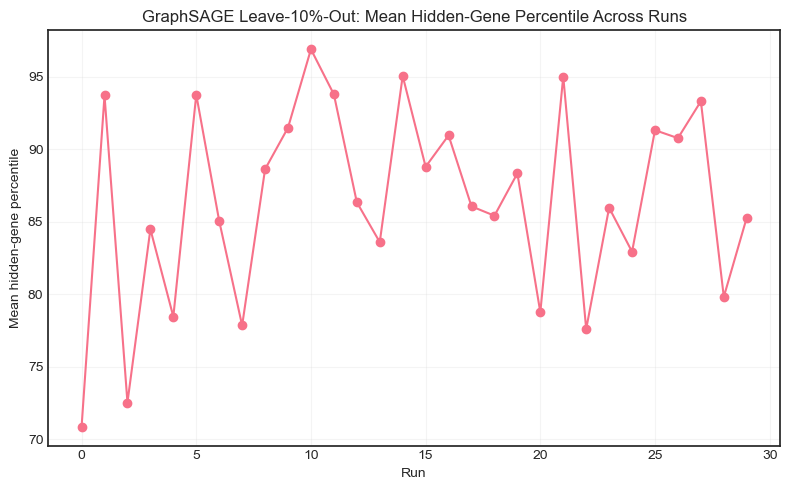

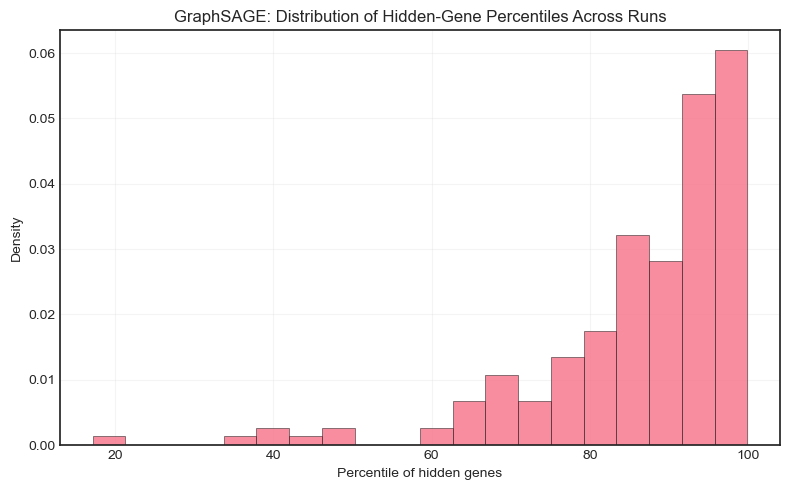

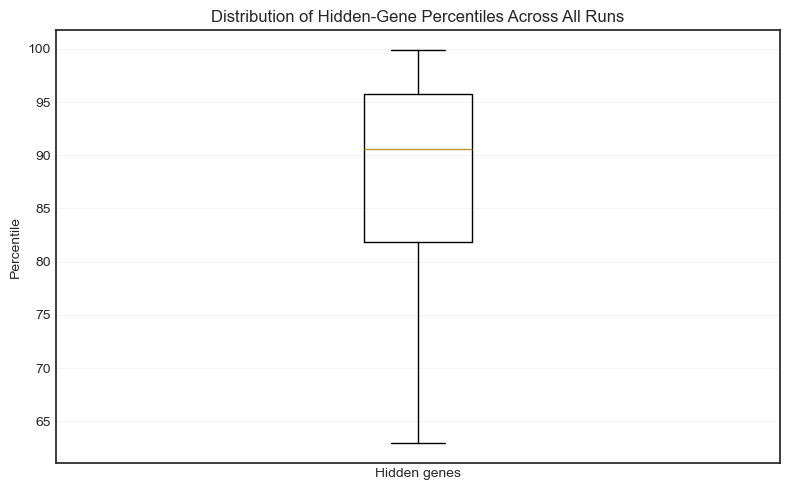

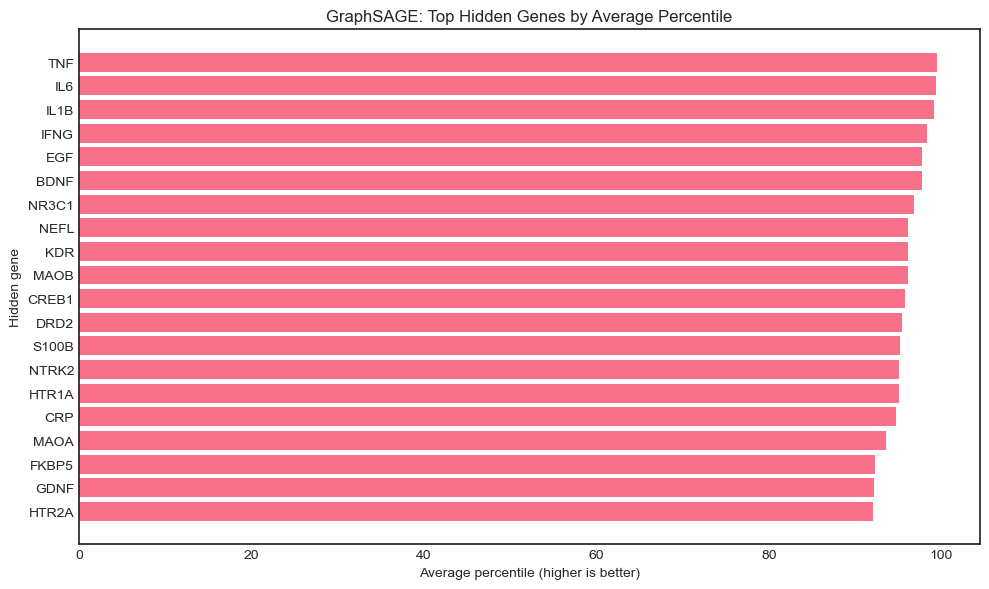

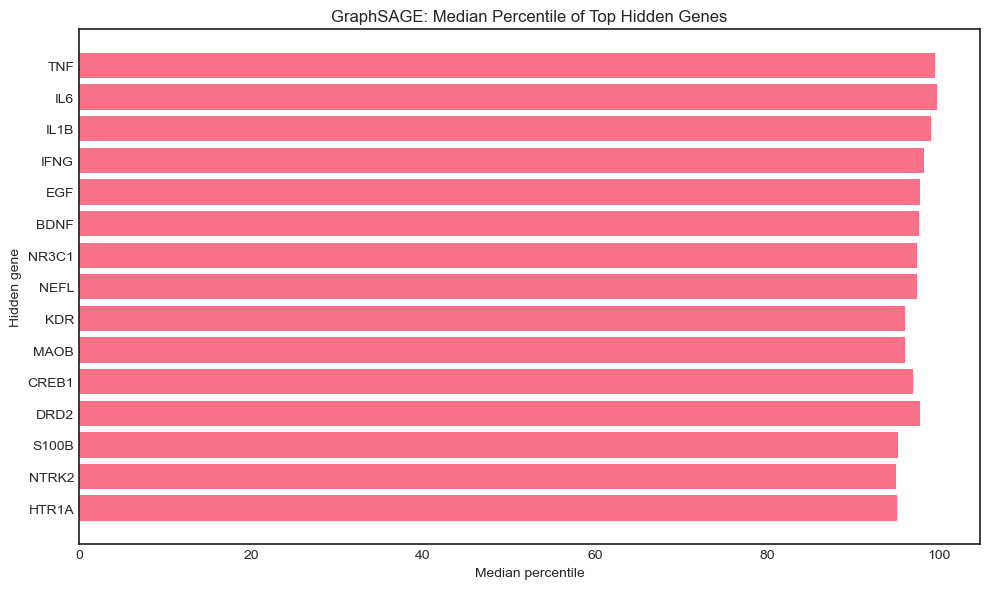


Saved:
- graphsage_leave10_percentile_results.csv
- graphsage_leave10_hidden_gene_percentile_long.csv
- graphsage_leave10_hidden_gene_percentile_summary.csv
- graphsage_leave10_hidden_gene_percentiles_by_run.csv
- graphsage_leave10_negative_gene_sets.csv
- graphsage_leave10_scored_run0.csv

Ready objects:
- G
- positive_genes
- negative_gene_sets_graphsage
- results_df
- hidden_gene_percentile_df
- gene_percentile_summary
- per_gene_per_run_percentiles
- graphsage_models_per_run
- scored_tables_per_run


In [31]:
# # ============================================================
# # ONE-CELL PIPELINE:
# # Leave-10%-out positive percentile ranking recovery
# # + negative selection + GraphSAGE
# #
# # GOAL
# # 1) Build the graph once
# # 2) For each run:
# #    - randomly hide 10% of known positives
# #    - never allow hidden positives to become negatives
# #    - recompute positive-dependent features using TRAIN positives only
# #    - rebuild the negative pool using TRAIN positives only
# #    - sample negatives from eligible non-positive/non-hidden genes
# #    - build run-specific node features for all nodes
# #    - train GraphSAGE on train positives vs sampled negatives
# #    - monitor validation AUC/AP for early stopping
# #    - rank candidate genes by predicted score
# #    - evaluate hidden positives by percentile position among candidates
# #
# # MAIN METRICS
# # - hidden_percentile: percentile rank of each hidden gene among ranked candidates
# #                      (higher is better; 100 = best-ranked candidate)
# # - mean_hidden_percentile per run
# # - median_hidden_percentile per run
# # ============================================================

# import os
# import random
# import warnings
# warnings.filterwarnings("ignore")

# import numpy as np
# import pandas as pd
# import networkx as nx
# import matplotlib.pyplot as plt
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# from collections import deque
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics import (
#     roc_auc_score,
#     average_precision_score,
# )

# print("=== ONE-CELL: LEAVE-10%-OUT POSITIVE PERCENTILE RANKING RECOVERY + NEGATIVE SELECTION + GraphSAGE ===")
# print("Percentile definition: 100 = best rank, 0 = worst rank")

# # =======================================================
# # 0) Reproducibility
# # =======================================================
# GLOBAL_SEED = 42
# os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)
# random.seed(GLOBAL_SEED)
# np.random.seed(GLOBAL_SEED)
# torch.manual_seed(GLOBAL_SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(GLOBAL_SEED)

# FORCE_CPU = True
# DEVICE = torch.device("cpu") if FORCE_CPU else torch.device("cuda" if torch.cuda.is_available() else "cpu")

# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False
# try:
#     torch.use_deterministic_algorithms(True)
# except Exception:
#     pass

# # =======================================================
# # 1) Config
# # =======================================================
# EDGE_THRESHOLD = 0.6

# NEG_Q = 0.50
# EXCLUDE_DIST = 2

# N_RUNS = 30
# BASE_SEED = 42
# HOLDOUT_POS_FRAC = 0.10

# WEIGHTS = {
#     "ppr": 3.0,
#     "pos_w_ratio": 2.0,
#     "pos_w_sum": 1.5,
#     "pos_w_max": 1.0,
#     "prox": 1.5,
#     "hub_penalty": -1.0
# }
# PROX_ALPHA = 0.7

# VAL_FRAC = 0.20

# # GraphSAGE
# N_EPOCHS = 200
# PATIENCE = 25
# LR = 0.01
# WEIGHT_DECAY = 1e-4
# HIDDEN = 32
# DROPOUT = 0.4
# INCLUDE_SELF_IN_MEAN = True

# EXCLUDE_SAMPLED_NEGATIVES_FROM_RANKING = False

# # =======================================================
# # 2) Preconditions
# # =======================================================
# if "interactions" not in globals():
#     raise RuntimeError("interactions not found.")
# if "filtered_result" not in globals():
#     raise RuntimeError("filtered_result not found.")

# # =======================================================
# # 3) Helpers
# # =======================================================
# def multi_source_bfs_distances(graph, sources):
#     dist = {n: np.inf for n in graph.nodes()}
#     q = deque()
#     for s in sources:
#         if s in graph:
#             dist[s] = 0
#             q.append(s)
#     while q:
#         u = q.popleft()
#         for v in graph.neighbors(u):
#             if dist[v] == np.inf:
#                 dist[v] = dist[u] + 1
#                 q.append(v)
#     return dist

# def sigmoid_np(x):
#     x = np.asarray(x, dtype=float)
#     return 1.0 / (1.0 + np.exp(-x))

# def safe_auc(y_true, y_score):
#     y_true = np.asarray(y_true).astype(int)
#     if len(np.unique(y_true)) < 2:
#         return np.nan
#     return float(roc_auc_score(y_true, y_score))

# def safe_ap(y_true, y_score):
#     y_true = np.asarray(y_true).astype(int)
#     if len(np.unique(y_true)) < 2:
#         return np.nan
#     return float(average_precision_score(y_true, y_score))

# def split_train_holdout_positives(pos_genes, holdout_frac, seed):
#     pos_genes = np.array(sorted(set(map(str, pos_genes))))
#     rng = np.random.RandomState(seed)
#     rng.shuffle(pos_genes)
#     n_holdout = max(1, int(np.round(holdout_frac * len(pos_genes))))
#     heldout = pos_genes[:n_holdout].tolist()
#     train_pos = pos_genes[n_holdout:].tolist()
#     return train_pos, heldout

# def make_train_val_masks(labeled_idx, y_labeled, n_nodes, split_seed=42, val_frac=0.2):
#     rng = np.random.RandomState(split_seed)
#     labeled_idx = np.asarray(labeled_idx)
#     y_labeled = np.asarray(y_labeled).astype(int)

#     pos = labeled_idx[y_labeled == 1]
#     neg = labeled_idx[y_labeled == 0]
#     rng.shuffle(pos)
#     rng.shuffle(neg)

#     def split_class(arr):
#         n = len(arr)
#         n_val = max(1, int(np.round(val_frac * n))) if n > 1 else 0
#         val = arr[:n_val]
#         train = arr[n_val:]
#         return train, val

#     pos_tr, pos_va = split_class(pos)
#     neg_tr, neg_va = split_class(neg)

#     train_idx = np.concatenate([pos_tr, neg_tr]) if len(pos_tr) + len(neg_tr) > 0 else np.array([], dtype=int)
#     val_idx = np.concatenate([pos_va, neg_va]) if len(pos_va) + len(neg_va) > 0 else np.array([], dtype=int)

#     rng.shuffle(train_idx)
#     rng.shuffle(val_idx)

#     train_mask = torch.zeros(n_nodes, dtype=torch.bool)
#     val_mask = torch.zeros(n_nodes, dtype=torch.bool)

#     if len(train_idx) > 0:
#         train_mask[torch.tensor(train_idx, dtype=torch.long)] = True
#     if len(val_idx) > 0:
#         val_mask[torch.tensor(val_idx, dtype=torch.long)] = True

#     return train_mask, val_mask

# def evaluate_hidden_percentile_ranking(
#     logits_np,
#     nodes,
#     node_to_idx,
#     train_positive_genes,
#     heldout_positive_genes,
#     sampled_negative_genes=None,
#     exclude_sampled_negatives=False
# ):
#     train_pos_set = set(map(str, train_positive_genes))
#     neg_set = set(map(str, sampled_negative_genes)) if sampled_negative_genes is not None else set()

#     candidate_genes = [g for g in nodes if g not in train_pos_set]
#     if exclude_sampled_negatives:
#         candidate_genes = [g for g in candidate_genes if g not in neg_set]

#     candidate_probs = np.array(
#         [sigmoid_np([logits_np[node_to_idx[g]]])[0] for g in candidate_genes],
#         dtype=float
#     )

#     order = np.argsort(-candidate_probs)
#     ranked_genes = [candidate_genes[i] for i in order]
#     ranked_probs = candidate_probs[order]

#     rank_map = {g: i + 1 for i, g in enumerate(ranked_genes)}
#     prob_map = {g: float(ranked_probs[i]) for i, g in enumerate(ranked_genes)}

#     n_candidates = len(ranked_genes)

#     rows = []
#     for g in map(str, heldout_positive_genes):
#         if g not in rank_map:
#             rows.append({
#                 "hidden_gene": g,
#                 "prob": np.nan,
#                 "rank": np.nan,
#                 "percentile": np.nan
#             })
#             continue

#         rank_i = rank_map[g]
#         if n_candidates <= 1:
#             pct = 100.0
#         else:
#             pct = 100.0 * (1.0 - (rank_i - 1) / (n_candidates - 1))

#         rows.append({
#             "hidden_gene": g,
#             "prob": prob_map[g],
#             "rank": rank_i,
#             "percentile": pct
#         })

#     hidden_df = pd.DataFrame(rows)

#     return {
#         "candidate_count": int(n_candidates),
#         "hidden_df": hidden_df
#     }

# # =======================================================
# # 4) Build weighted graph ONCE
# # =======================================================
# high_conf_interactions = [(a, b, w) for a, b, w in interactions if w >= EDGE_THRESHOLD]

# G = nx.Graph()
# for a, b, w in high_conf_interactions:
#     G.add_edge(str(a), str(b), weight=float(w))

# print(f"Initial STRING graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# full_positive_genes = set(filtered_result["gene_symbol"].dropna().astype(str).unique())
# nx.set_node_attributes(G, {n: (1 if n in full_positive_genes else 0) for n in G.nodes()}, "positive")

# pos_in_graph_before = [n for n in G.nodes() if G.nodes[n].get("positive", 0) == 1]
# print(f"Positive genes in graph before component filtering: {len(pos_in_graph_before)}")

# positive_nodes_set = set(pos_in_graph_before)
# reachable_from_positive = set()
# for comp in nx.connected_components(G):
#     if comp & positive_nodes_set:
#         reachable_from_positive.update(comp)

# removed_nodes = set(G.nodes()) - reachable_from_positive
# G = G.subgraph(reachable_from_positive).copy()

# print(f"Removed {len(removed_nodes)} genes from components with no positive connection")
# print(f"Filtered graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# positive_genes = sorted([n for n in G.nodes() if n in full_positive_genes])
# print(f"Positive genes in filtered graph: {len(positive_genes)}")

# nodes = [str(n) for n in G.nodes()]
# node_to_idx = {n: i for i, n in enumerate(nodes)}
# N = len(nodes)

# # =======================================================
# # 5) Static structural features ONCE
# # =======================================================
# deg_cent = nx.degree_centrality(G)
# try:
#     btw_cent = nx.betweenness_centrality(G)
# except Exception:
#     btw_cent = {n: 0.0 for n in G.nodes()}
# try:
#     clo_cent = nx.closeness_centrality(G)
# except Exception:
#     clo_cent = {n: 0.0 for n in G.nodes()}
# clust = nx.clustering(G)
# deg = dict(G.degree())

# struct_rows = []
# for gene in nodes:
#     neighbors = list(G.neighbors(gene))
#     neighbor_degrees = [G.degree(n) for n in neighbors] if neighbors else []
#     neighbor_weights = [float(G[gene][n].get("weight", 1.0)) for n in neighbors] if neighbors else []

#     struct_rows.append({
#         "gene": gene,
#         "degree": G.degree(gene),
#         "clustering_coefficient": float(clust.get(gene, 0.0)),
#         "neighbor_count": len(neighbors),
#         "avg_neighbor_degree": float(np.mean(neighbor_degrees)) if neighbors else 0.0,
#         "max_neighbor_degree": float(np.max(neighbor_degrees)) if neighbors else 0.0,
#         "avg_edge_weight": float(np.mean(neighbor_weights)) if neighbors else 0.0,
#         "max_edge_weight": float(np.max(neighbor_weights)) if neighbors else 0.0,
#         "degree_centrality": float(deg_cent.get(gene, 0.0)),
#         "betweenness_centrality": float(btw_cent.get(gene, 0.0)),
#         "closeness_centrality": float(clo_cent.get(gene, 0.0)),
#     })

# struct_df = pd.DataFrame(struct_rows).set_index("gene").fillna(0).replace([np.inf, -np.inf], 0)

# # =======================================================
# # 6) Run-specific scoring / negative selection
# # =======================================================
# def build_run_scored_table(graph, nodes, train_positive_genes):
#     eps = 1e-9
#     train_positive_genes = [str(g) for g in train_positive_genes if str(g) in graph]

#     if len(train_positive_genes) > 0:
#         dist_to_pos = multi_source_bfs_distances(graph, train_positive_genes)
#         personalization = {n: (1.0 if n in train_positive_genes else 0.0) for n in graph.nodes()}
#         ppr = nx.pagerank(graph, alpha=0.85, personalization=personalization, weight="weight")
#     else:
#         dist_to_pos = {n: np.inf for n in graph.nodes()}
#         ppr = {n: 0.0 for n in graph.nodes()}

#     train_pos_set = set(train_positive_genes)
#     rows = []

#     for node in nodes:
#         neighbors = list(graph.neighbors(node))
#         pos_neighbors = [n for n in neighbors if n in train_pos_set]
#         pos_edges = [graph[node][p]["weight"] for p in pos_neighbors]

#         pos_w_sum = float(np.sum(pos_edges)) if pos_edges else 0.0
#         pos_w_max = float(np.max(pos_edges)) if pos_edges else 0.0
#         pos_w_mean = float(np.mean(pos_edges)) if pos_edges else 0.0
#         pos_neighbor_count = len(pos_neighbors)

#         total_w = float(np.sum([graph[node][nbr]["weight"] for nbr in neighbors])) if neighbors else 0.0
#         pos_w_ratio = pos_w_sum / (total_w + eps)

#         d = dist_to_pos.get(node, np.inf)
#         prox = 0.0 if np.isinf(d) else float(np.exp(-PROX_ALPHA * d))
#         hub_penalty = float(np.log1p(deg.get(node, 0)))

#         rows.append({
#             "gene": node,
#             "is_train_positive": int(node in train_pos_set),
#             "pos_neighbor_count": pos_neighbor_count,
#             "pos_w_sum": pos_w_sum,
#             "pos_w_max": pos_w_max,
#             "pos_w_mean": pos_w_mean,
#             "pos_w_ratio": pos_w_ratio,
#             "distance_to_positive": float(d) if not np.isinf(d) else np.inf,
#             "prox": prox,
#             "ppr": float(ppr.get(node, 0.0)),
#             "hub_penalty": hub_penalty
#         })

#     scored_run = pd.DataFrame(rows)

#     score_features = ["ppr", "pos_w_ratio", "pos_w_sum", "pos_w_max", "prox", "hub_penalty"]

#     if np.isinf(scored_run["distance_to_positive"]).any():
#         reachable = scored_run.loc[~np.isinf(scored_run["distance_to_positive"]), "distance_to_positive"]
#         worst = float(reachable.max()) + 1 if len(reachable) else 1.0
#         scored_run["distance_to_positive"] = scored_run["distance_to_positive"].replace(np.inf, worst)

#     scaler = MinMaxScaler()
#     scored_run[score_features] = scaler.fit_transform(scored_run[score_features])

#     scored_run["final_score"] = 0.0
#     for f, w in WEIGHTS.items():
#         scored_run["final_score"] += scored_run[f] * float(w)

#     scored_run["final_score_01"] = MinMaxScaler().fit_transform(scored_run[["final_score"]])
#     return scored_run

# def sample_negatives_for_run(scored_run, train_positive_genes, heldout_positive_genes, seed):
#     train_pos_set = set(map(str, train_positive_genes))
#     heldout_set = set(map(str, heldout_positive_genes))

#     nonpos = scored_run[
#         (~scored_run["gene"].astype(str).isin(train_pos_set)) &
#         (~scored_run["gene"].astype(str).isin(heldout_set))
#     ].copy()

#     cutoff = nonpos["final_score"].quantile(NEG_Q)
#     eligible = nonpos[nonpos["final_score"] <= cutoff].copy()

#     if EXCLUDE_DIST is not None and EXCLUDE_DIST > 0:
#         eligible = eligible[eligible["distance_to_positive"] > EXCLUDE_DIST]

#     eligible_genes = sorted(eligible["gene"].astype(str).tolist())

#     k_target = len(train_positive_genes)
#     k = min(k_target, len(eligible_genes))

#     rng = random.Random(seed)
#     neg_genes = rng.sample(eligible_genes, k=k) if k > 0 else []

#     return neg_genes, eligible_genes, cutoff, k

# def build_run_node_feature_df(scored_run):
#     run_lookup = scored_run.copy().assign(gene=lambda d: d["gene"].astype(str)).set_index("gene")

#     feature_df = struct_df.copy()
#     merge_cols = [
#         "ppr",
#         "pos_w_ratio",
#         "pos_w_sum",
#         "pos_w_max",
#         "pos_neighbor_count",
#         "distance_to_positive",
#         "prox",
#         "hub_penalty"
#     ]

#     common = feature_df.index.intersection(run_lookup.index)
#     for c in merge_cols:
#         if c in run_lookup.columns:
#             feature_df.loc[common, c] = run_lookup.loc[common, c]

#     feature_df = feature_df.fillna(0).replace([np.inf, -np.inf], 0)
#     return feature_df.reset_index().rename(columns={"index": "gene"})

# def build_run_tensors(full_feature_df, train_pos_genes, neg_genes, node_to_idx):
#     feature_cols = [c for c in full_feature_df.columns if c != "gene"]

#     X_df = full_feature_df.set_index("gene").loc[nodes, feature_cols].copy()
#     X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
#     X_t = torch.tensor(X_df.values, dtype=torch.float32, device=DEVICE)

#     y = torch.full((N,), -1, dtype=torch.long)
#     pos_set = set(map(str, train_pos_genes))
#     neg_set = set(map(str, neg_genes))

#     labeled_idx = []
#     y_labeled = []

#     for g in pos_set:
#         if g in node_to_idx:
#             idx = node_to_idx[g]
#             y[idx] = 1
#             labeled_idx.append(idx)
#             y_labeled.append(1)

#     for g in neg_set:
#         if g in node_to_idx:
#             idx = node_to_idx[g]
#             y[idx] = 0
#             labeled_idx.append(idx)
#             y_labeled.append(0)

#     return X_t, feature_cols, y.to(DEVICE), np.array(labeled_idx, dtype=int), np.array(y_labeled, dtype=int)

# # =======================================================
# # 7) Graph tensors and GraphSAGE
# # =======================================================
# edges = []
# for u, v in G.edges():
#     ui = node_to_idx[str(u)]
#     vi = node_to_idx[str(v)]
#     edges.append((ui, vi))
#     edges.append((vi, ui))

# edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# def row_norm_adj(edge_index, num_nodes, include_self=True, device=None):
#     if device is None:
#         device = edge_index.device

#     idx = edge_index.to(device)
#     vals = torch.ones(idx.size(1), dtype=torch.float32, device=device)

#     if include_self:
#         self_loops = torch.arange(num_nodes, device=device)
#         self_idx = torch.stack([self_loops, self_loops], dim=0)
#         idx = torch.cat([idx, self_idx], dim=1)
#         vals = torch.cat([vals, torch.ones(num_nodes, dtype=torch.float32, device=device)], dim=0)

#     A = torch.sparse_coo_tensor(idx, vals, (num_nodes, num_nodes)).coalesce()
#     degv = torch.sparse.sum(A, dim=1).to_dense()
#     deg_inv = torch.pow(degv.clamp(min=1e-12), -1.0)

#     row, col = A.indices()
#     v = A.values() * deg_inv[row]
#     A_mean = torch.sparse_coo_tensor(A.indices(), v, A.size()).coalesce()
#     return A_mean

# A_mean = row_norm_adj(edge_index.to(DEVICE), N, include_self=INCLUDE_SELF_IN_MEAN, device=DEVICE)

# class GraphSAGELayer(nn.Module):
#     def __init__(self, in_dim, out_dim):
#         super().__init__()
#         self.lin_self = nn.Linear(in_dim, out_dim, bias=True)
#         self.lin_neigh = nn.Linear(in_dim, out_dim, bias=True)

#     def forward(self, x, A_mean):
#         neigh = torch.sparse.mm(A_mean, x)
#         out = self.lin_self(x) + self.lin_neigh(neigh)
#         return out

# class GraphSAGE(nn.Module):
#     def __init__(self, in_dim, hid_dim, dropout=0.4):
#         super().__init__()
#         self.sage1 = GraphSAGELayer(in_dim, hid_dim)
#         self.sage2 = GraphSAGELayer(hid_dim, 1)
#         self.dropout = dropout

#     def forward(self, X, A_mean):
#         h = self.sage1(X, A_mean)
#         h = F.relu(h)
#         h = F.dropout(h, p=self.dropout, training=self.training)
#         out = self.sage2(h, A_mean).squeeze(-1)
#         return out

# # =======================================================
# # 8) Run the pipeline
# # =======================================================
# all_rows = []
# graphsage_models_per_run = []
# negative_gene_sets_graphsage = []
# scored_tables_per_run = []
# hidden_gene_percentile_rows = []

# for run_id in range(N_RUNS):
#     run_seed = BASE_SEED + run_id
#     random.seed(run_seed)
#     np.random.seed(run_seed)
#     torch.manual_seed(run_seed)
#     if torch.cuda.is_available():
#         torch.cuda.manual_seed_all(run_seed)

#     train_positive_genes, heldout_positive_genes = split_train_holdout_positives(
#         positive_genes,
#         holdout_frac=HOLDOUT_POS_FRAC,
#         seed=run_seed
#     )

#     scored_run = build_run_scored_table(G, nodes, train_positive_genes)

#     neg_genes, eligible_genes, cutoff, k = sample_negatives_for_run(
#         scored_run=scored_run,
#         train_positive_genes=train_positive_genes,
#         heldout_positive_genes=heldout_positive_genes,
#         seed=run_seed
#     )
#     negative_gene_sets_graphsage.append(neg_genes)

#     full_feature_df = build_run_node_feature_df(scored_run)

#     X_t, feature_cols, y_all, labeled_idx, y_labeled = build_run_tensors(
#         full_feature_df=full_feature_df,
#         train_pos_genes=train_positive_genes,
#         neg_genes=neg_genes,
#         node_to_idx=node_to_idx
#     )

#     train_mask, val_mask = make_train_val_masks(
#         labeled_idx=labeled_idx,
#         y_labeled=y_labeled,
#         n_nodes=N,
#         split_seed=run_seed,
#         val_frac=VAL_FRAC
#     )
#     train_mask = train_mask.to(DEVICE)
#     val_mask = val_mask.to(DEVICE)

#     y_train_np = y_all[train_mask].detach().cpu().numpy()
#     n_pos = int((y_train_np == 1).sum())
#     n_neg = int((y_train_np == 0).sum())
#     pos_weight = float(n_neg / max(1, n_pos))

#     model = GraphSAGE(
#         in_dim=X_t.shape[1],
#         hid_dim=HIDDEN,
#         dropout=DROPOUT
#     ).to(DEVICE)

#     opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
#     loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, device=DEVICE))

#     best_val_auc = -np.inf
#     best_state = None
#     best_epoch = 0
#     bad = 0

#     print(
#         f"[RUN {run_id:02d}] "
#         f"train_pos={len(train_positive_genes)} | hidden_pos={len(heldout_positive_genes)} | "
#         f"eligible_neg={len(eligible_genes)} | sampled_neg={len(neg_genes)} | "
#         f"feature_dim={X_t.shape[1]}"
#     )

#     for epoch in range(1, N_EPOCHS + 1):
#         model.train()
#         opt.zero_grad()

#         logits = model(X_t, A_mean)
#         loss = loss_fn(logits[train_mask], y_all[train_mask].float())
#         loss.backward()
#         opt.step()

#         model.eval()
#         with torch.no_grad():
#             logits_eval = model(X_t, A_mean)

#         y_val = y_all[val_mask].detach().cpu().numpy().astype(int)
#         val_prob = sigmoid_np(logits_eval[val_mask].detach().cpu().numpy())
#         val_auc = safe_auc(y_val, val_prob)

#         improved = (not np.isnan(val_auc)) and (val_auc > best_val_auc + 1e-6)
#         if improved:
#             best_val_auc = val_auc
#             best_state = {k_: v.detach().cpu().clone() for k_, v in model.state_dict().items()}
#             best_epoch = epoch
#             bad = 0
#         else:
#             bad += 1

#         if epoch == 1 or epoch % 25 == 0:
#             val_ap_tmp = safe_ap(y_val, val_prob)
#             print(
#                 f"    epoch={epoch:03d} "
#                 f"loss={loss.item():.4f} "
#                 f"val_auc={0.0 if np.isnan(val_auc) else val_auc:.3f} "
#                 f"val_ap={0.0 if np.isnan(val_ap_tmp) else val_ap_tmp:.3f}"
#             )

#         if bad >= PATIENCE:
#             break

#     if best_state is not None:
#         model.load_state_dict(best_state)

#     model.eval()
#     with torch.no_grad():
#         logits_final = model(X_t, A_mean)

#     logits_np = logits_final.detach().cpu().numpy()

#     val_prob = sigmoid_np(logits_np[val_mask.detach().cpu().numpy().astype(bool)])
#     y_val_final = y_all[val_mask].detach().cpu().numpy().astype(int)
#     val_auc_final = safe_auc(y_val_final, val_prob)
#     val_ap_final = safe_ap(y_val_final, val_prob)

#     pct_eval = evaluate_hidden_percentile_ranking(
#         logits_np=logits_np,
#         nodes=nodes,
#         node_to_idx=node_to_idx,
#         train_positive_genes=train_positive_genes,
#         heldout_positive_genes=heldout_positive_genes,
#         sampled_negative_genes=neg_genes,
#         exclude_sampled_negatives=EXCLUDE_SAMPLED_NEGATIVES_FROM_RANKING
#     )

#     hidden_pct_mean = float(pct_eval["hidden_df"]["percentile"].mean()) if len(pct_eval["hidden_df"]) > 0 else np.nan
#     hidden_pct_median = float(pct_eval["hidden_df"]["percentile"].median()) if len(pct_eval["hidden_df"]) > 0 else np.nan

#     print(
#         f"RUN {run_id:02d} | best_epoch={best_epoch} | "
#         f"VAL AUC {0.0 if np.isnan(val_auc_final) else val_auc_final:.3f} "
#         f"AP {0.0 if np.isnan(val_ap_final) else val_ap_final:.3f} | "
#         f"candidate_count={pct_eval['candidate_count']} | "
#         f"mean_hidden_percentile={hidden_pct_mean:.2f} | "
#         f"median_hidden_percentile={hidden_pct_median:.2f}"
#     )

#     row = {
#         "run": run_id,
#         "model": "GraphSAGE_leave_10pct_out_percentile_ranking",
#         "train_pos_total": int(len(train_positive_genes)),
#         "hidden_pos_total": int(len(heldout_positive_genes)),
#         "eligible_neg_total": int(len(eligible_genes)),
#         "sampled_neg_total": int(len(neg_genes)),
#         "neg_cutoff": float(cutoff),
#         "labeled_total": int(len(labeled_idx)),
#         "train_pos_used": int(n_pos),
#         "train_neg_used": int(n_neg),
#         "pos_weight": float(pos_weight),
#         "best_epoch": int(best_epoch),
#         "feature_dim": int(X_t.shape[1]),
#         "val_auc": float(val_auc_final) if not np.isnan(val_auc_final) else np.nan,
#         "val_ap": float(val_ap_final) if not np.isnan(val_ap_final) else np.nan,
#         "candidate_count": int(pct_eval["candidate_count"]),
#         "mean_hidden_percentile": hidden_pct_mean,
#         "median_hidden_percentile": hidden_pct_median,
#         "include_self_in_mean": bool(INCLUDE_SELF_IN_MEAN),
#     }
#     all_rows.append(row)

#     pct_hidden_df = pct_eval["hidden_df"].copy()
#     pct_hidden_df["run"] = run_id
#     pct_hidden_df["candidate_count"] = pct_eval["candidate_count"]
#     hidden_gene_percentile_rows.append(pct_hidden_df)

#     scored_tables_per_run.append(scored_run.copy())

#     graphsage_models_per_run.append({
#         "run_id": run_id,
#         "model_name": "GraphSAGE_leave_10pct_out_percentile_ranking",
#         "model": model,
#         "feature_cols": feature_cols,
#         "node_to_idx": node_to_idx,
#         "device": str(DEVICE),
#         "include_self_in_mean": bool(INCLUDE_SELF_IN_MEAN),
#         "train_positive_genes_list": list(map(str, train_positive_genes)),
#         "heldout_positive_genes_list": list(map(str, heldout_positive_genes)),
#         "negative_genes_list": list(map(str, neg_genes)),
#     })

# results_df = pd.DataFrame(all_rows)
# hidden_gene_percentile_df = pd.concat(hidden_gene_percentile_rows, axis=0, ignore_index=True)

# # =======================================================
# # 9) Summaries
# # =======================================================
# print("\n=== SUMMARY: RUN-LEVEL PERCENTILE RANKING RECOVERY (GraphSAGE) ===")
# summary_cols = [
#     "mean_hidden_percentile",
#     "median_hidden_percentile",
#     "candidate_count",
#     "train_pos_total",
#     "hidden_pos_total",
#     "sampled_neg_total",
#     "val_auc",
#     "val_ap",
#     "best_epoch"
# ]
# print(results_df[summary_cols].agg(["mean", "std", "min", "max"]).round(4).to_string())

# print("\n=== GLOBAL PERCENTILE SUMMARY ===")
# all_hidden_percentiles = hidden_gene_percentile_df["percentile"]
# print(f"Mean percentile:   {all_hidden_percentiles.mean():.2f}")
# print(f"Median percentile: {all_hidden_percentiles.median():.2f}")
# print(f"Std percentile:    {all_hidden_percentiles.std():.2f}")
# print(f"Min percentile:    {all_hidden_percentiles.min():.2f}")
# print(f"Max percentile:    {all_hidden_percentiles.max():.2f}")

# print("\n=== SUMMARY: GENE-LEVEL PERCENTILE RANKING RECOVERY (GraphSAGE) ===")
# gene_percentile_summary = (
#     hidden_gene_percentile_df
#     .groupby("hidden_gene", as_index=False)
#     .agg(
#         times_hidden=("hidden_gene", "size"),
#         median_rank=("rank", "median"),
#         mean_rank=("rank", "mean"),
#         median_percentile=("percentile", "median"),
#         mean_percentile=("percentile", "mean"),
#         std_percentile=("percentile", "std"),
#         median_prob=("prob", "median"),
#         mean_prob=("prob", "mean"),
#     )
#     .sort_values(["mean_percentile", "times_hidden"], ascending=[False, False])
# )
# print(gene_percentile_summary.head(20).round(4).to_string(index=False))

# overall_mean_percentile = hidden_gene_percentile_df["percentile"].mean()
# print(f"\nOverall hidden-gene mean percentile across all hidden instances: {overall_mean_percentile:.2f}")

# per_gene_per_run_percentiles = hidden_gene_percentile_df[
#     ["run", "hidden_gene", "rank", "percentile", "prob"]
# ].copy()

# # =======================================================
# # 10) Plots
# # =======================================================
# plt.figure(figsize=(8, 5))
# plt.plot(results_df["run"], results_df["mean_hidden_percentile"], marker="o")
# plt.xlabel("Run")
# plt.ylabel("Mean hidden-gene percentile")
# plt.title("GraphSAGE Leave-10%-Out: Mean Hidden-Gene Percentile Across Runs")
# plt.grid(alpha=0.2)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(hidden_gene_percentile_df["percentile"], bins=20, density=True, alpha=0.8, edgecolor="black", linewidth=0.4)
# plt.xlabel("Percentile of hidden genes")
# plt.ylabel("Density")
# plt.title("GraphSAGE: Distribution of Hidden-Gene Percentiles Across Runs")
# plt.grid(alpha=0.2)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.boxplot(hidden_gene_percentile_df["percentile"], tick_labels=["Hidden genes"], showfliers=False)
# plt.ylabel("Percentile")
# plt.title("Distribution of Hidden-Gene Percentiles Across All Runs")
# plt.grid(axis="y", alpha=0.2)
# plt.tight_layout()
# plt.show()

# top_genes_pct = gene_percentile_summary.head(20).copy()
# plt.figure(figsize=(10, 6))
# plt.barh(top_genes_pct["hidden_gene"][::-1], top_genes_pct["mean_percentile"][::-1])
# plt.xlabel("Average percentile (higher is better)")
# plt.ylabel("Hidden gene")
# plt.title("GraphSAGE: Top Hidden Genes by Average Percentile")
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(10, 6))
# gene_pct_for_plot = gene_percentile_summary.sort_values("mean_percentile", ascending=False).head(15)
# plt.barh(gene_pct_for_plot["hidden_gene"][::-1], gene_pct_for_plot["median_percentile"][::-1])
# plt.xlabel("Median percentile")
# plt.ylabel("Hidden gene")
# plt.title("GraphSAGE: Median Percentile of Top Hidden Genes")
# plt.tight_layout()
# plt.show()

# # =======================================================
# # 11) Save
# # =======================================================
# results_df.to_csv("graphsage_leave10_percentile_results.csv", index=False)
# hidden_gene_percentile_df.to_csv("graphsage_leave10_hidden_gene_percentile_long.csv", index=False)
# gene_percentile_summary.to_csv("graphsage_leave10_hidden_gene_percentile_summary.csv", index=False)
# per_gene_per_run_percentiles.to_csv("graphsage_leave10_hidden_gene_percentiles_by_run.csv", index=False)

# neg_long = []
# for i, negs in enumerate(negative_gene_sets_graphsage):
#     seed_i = BASE_SEED + i
#     for g in negs:
#         neg_long.append({"run": i, "seed": seed_i, "gene": g})
# pd.DataFrame(neg_long).to_csv("graphsage_leave10_negative_gene_sets.csv", index=False)

# if len(scored_tables_per_run) > 0:
#     scored_tables_per_run[0].to_csv("graphsage_leave10_scored_run0.csv", index=False)

# print("\nSaved:")
# print("- graphsage_leave10_percentile_results.csv")
# print("- graphsage_leave10_hidden_gene_percentile_long.csv")
# print("- graphsage_leave10_hidden_gene_percentile_summary.csv")
# print("- graphsage_leave10_hidden_gene_percentiles_by_run.csv")
# print("- graphsage_leave10_negative_gene_sets.csv")
# print("- graphsage_leave10_scored_run0.csv")

# print("\nReady objects:")
# print("- G")
# print("- positive_genes")
# print("- negative_gene_sets_graphsage")
# print("- results_df")
# print("- hidden_gene_percentile_df")
# print("- gene_percentile_summary")
# print("- per_gene_per_run_percentiles")
# print("- graphsage_models_per_run")
# print("- scored_tables_per_run")